<a href="https://colab.research.google.com/github/Jobmrtall/House-Price-Prediction-Using-Linear-Regression-Random-Forest-and-XGBoost/blob/main/House_Price_Prediction_Using_multiple_ML_and_DL_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline

In [ ]:
train=pd.read_csv('https://raw.githubusercontent.com/Jobmrtall/PRODIGY_ML_01/refs/heads/main/train.csv')
test=pd.read_csv('https://raw.githubusercontent.com/Jobmrtall/PRODIGY_ML_01/refs/heads/main/test.csv')
sample_submission=pd.read_csv('https://raw.githubusercontent.com/Jobmrtall/PRODIGY_ML_01/refs/heads/main/sample_submission.csv')

In [ ]:
train.head()
train.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [ ]:
train.isna().sum()
train.dtypes
print(train['MSSubClass'].unique())
print(test['MSSubClass'].unique())

[ 60  20  70  50 190  45  90 120  30  85  80 160  75 180  40]
[ 20  60 120 160  80  30  50  90  85 190  45  70  75 180  40 150]


In [ ]:
train.isna().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [ ]:
train.isna().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [ ]:
test.isna().sum()

,0
Id,0
MSSubClass,0
MSZoning,4
LotFrontage,227
LotArea,0
...,...
MiscVal,0
MoSold,0
YrSold,0
SaleType,1


In [ ]:
missing=train.isna().sum()
missing_values=missing[missing>0]
print(missing_values)
print(missing_values.count())
print(missing_values.sort_values())

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64
19
Electrical         1
MasVnrArea         8
BsmtCond          37
BsmtFinType1      37
BsmtQual          37
BsmtExposure      38
BsmtFinType2      38
GarageType        81
GarageQual        81
GarageFinish      81
GarageCond        81
GarageYrBlt       81
LotFrontage      259
FireplaceQu      690
MasVnrType       872
Fence           1179
Alley           1369
MiscFeature     1406
PoolQC          1453
dtype: int64


I merged the data sets but left keys to easily diffrentiate the training data tot he test data

In [ ]:
merged=pd.concat([train,test],ignore_index=False,keys=['train','test'])
merged

Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley  \
train 0        1          60       RL         65.0     8450   Pave   NaN   
      1        2          20       RL         80.0     9600   Pave   NaN   
      2        3          60       RL         68.0    11250   Pave   NaN   
      3        4          70       RL         60.0     9550   Pave   NaN   
      4        5          60       RL         84.0    14260   Pave   NaN   
...          ...         ...      ...          ...      ...    ...   ...   
test  1454  2915         160       RM         21.0     1936   Pave   NaN   
      1455  2916         160       RM         21.0     1894   Pave   NaN   
      1456  2917          20       RL        160.0    20000   Pave   NaN   
      1457  2918          85       RL         62.0    10441   Pave   NaN   
      1458  2919          60       RL         74.0     9627   Pave   NaN   

           LotShape LandContour Utilities  ... PoolArea PoolQC  Fence  \
train 0         Reg         Lvl    AllPub  ...        0    NaN    NaN   
      1         Reg         Lvl    AllPub  ...        0    NaN    NaN   
      2         IR1         Lvl    AllPub  ...        0    NaN    NaN   
      3         IR1         Lvl    AllPub  ...        0    NaN    NaN   
      4         IR1         Lvl    AllPub  ...        0    NaN    NaN   
...             ...         ...       ...  ...      ...    ...    ...   
test  1454      Reg         Lvl    AllPub  ...        0    NaN    NaN   
      1455      Reg         Lvl    AllPub  ...        0    NaN    NaN   
      1456      Reg         Lvl    AllPub  ...        0    NaN    NaN   
      1457      Reg         Lvl    AllPub  ...        0    NaN  MnPrv   
      1458      Reg         Lvl    AllPub  ...        0    NaN    NaN   

           MiscFeature MiscVal MoSold YrSold  SaleType  SaleCondition  \
train 0            NaN       0      2   2008        WD         Normal   
      1            NaN       0      5   2007        WD         Normal   
      2            NaN       0      9   2008        WD         Normal   
      3            NaN       0      2   2006        WD        Abnorml   
      4            NaN       0     12   2008        WD         Normal   
...                ...     ...    ...    ...       ...            ...   
test  1454         NaN       0      6   2006        WD         Normal   
      1455         NaN       0      4   2006        WD        Abnorml   
      1456         NaN       0      9   2006        WD        Abnorml   
      1457        Shed     700      7   2006        WD         Normal   
      1458         NaN       0     11   2006        WD         Normal   

            SalePrice  
train 0      208500.0  
      1      181500.0  
      2      223500.0  
      3      140000.0  
      4      250000.0  
...               ...  
test  1454        NaN  
      1455        NaN  
      1456        NaN  
      1457        NaN  
      1458        NaN  

[2919 rows x 81 columns]

In [ ]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 2919 entries, ('train', np.int64(0)) to ('test', np.int64(1458))
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          198 non-null    object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual

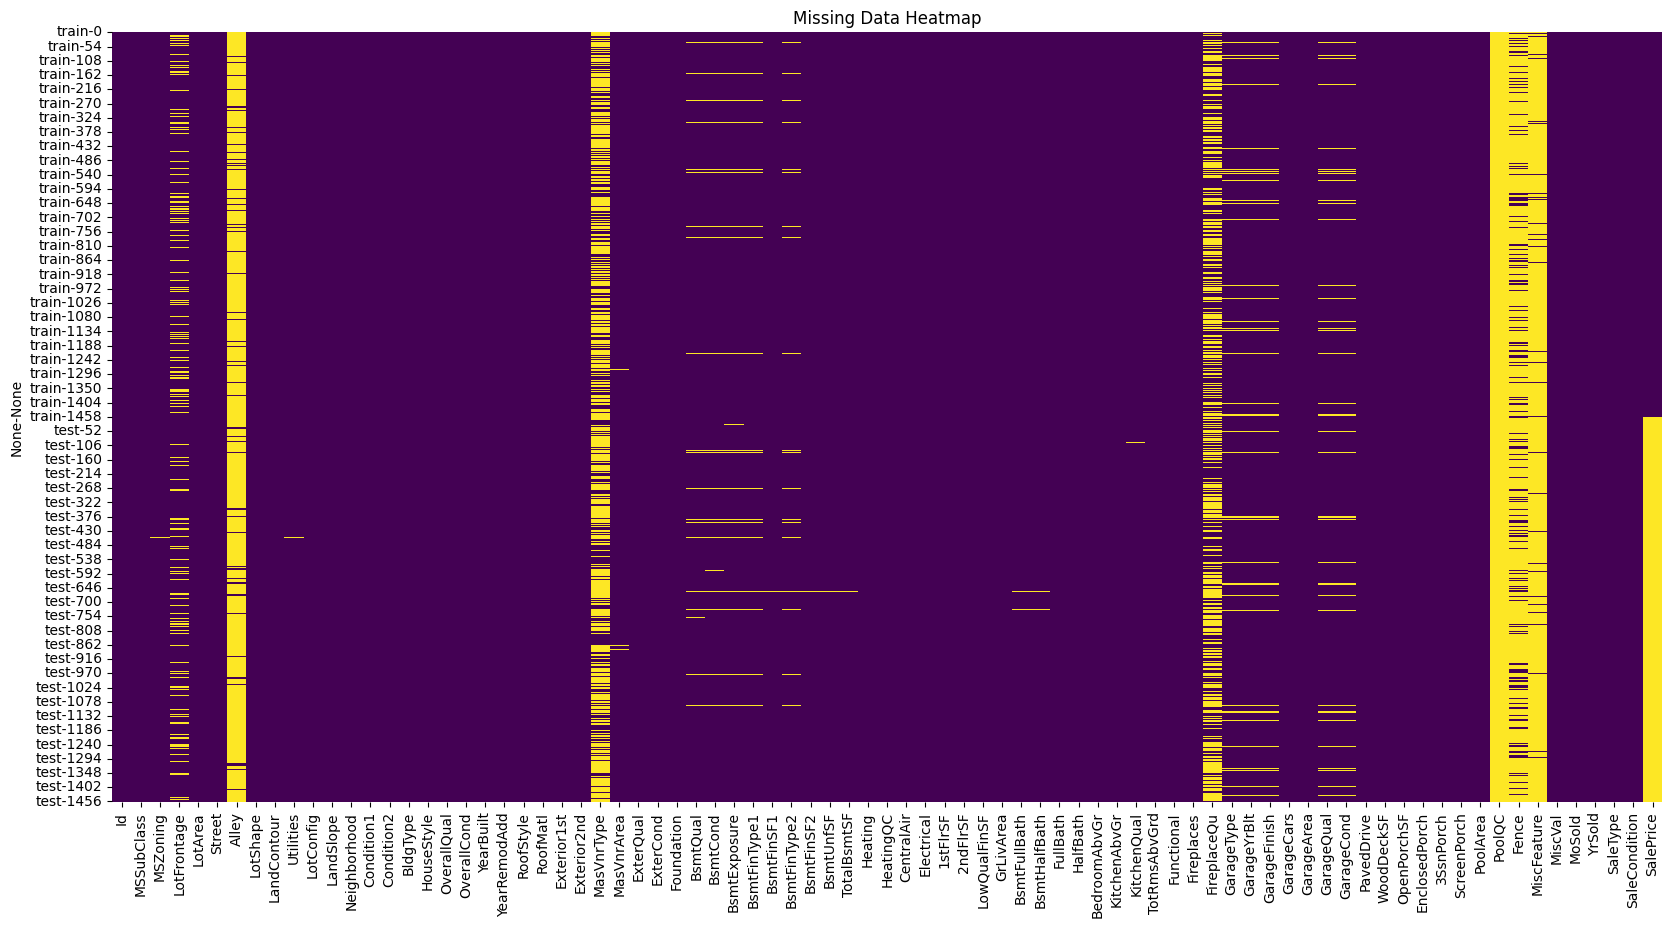

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(merged.isna(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()

How much precent does the missing value accounts of the main data

In [ ]:
print(merged.isna().sum().sum())
print(merged.count().sum())
print(merged.isna().sum().sum()/merged.count().sum()) #to know how much of the missing data accounts the real data

17166
219273
0.078285972281129


Above 5 precent so considering imputation rather than dropping the null values

In [ ]:
print(len(merged))
merged.isna().sum().sort_values()

2919


,0
Id,0
MSSubClass,0
Street,0
LotArea,0
LotShape,0
...,...
MasVnrType,1766
Fence,2348
Alley,2721
MiscFeature,2814


In [ ]:
missing=merged.isna().sum()
missing_values= missing[missing>0]
print(missing_values.sort_values())
print(missing_values.count())

Exterior2nd        1
Exterior1st        1
BsmtUnfSF          1
BsmtFinSF2         1
BsmtFinSF1         1
KitchenQual        1
Electrical         1
TotalBsmtSF        1
GarageArea         1
GarageCars         1
SaleType           1
Functional         2
BsmtFullBath       2
Utilities          2
BsmtHalfBath       2
MSZoning           4
MasVnrArea        23
BsmtFinType1      79
BsmtFinType2      80
BsmtQual          81
BsmtCond          82
BsmtExposure      82
GarageType       157
GarageFinish     159
GarageCond       159
GarageYrBlt      159
GarageQual       159
LotFrontage      486
FireplaceQu     1420
SalePrice       1459
MasVnrType      1766
Fence           2348
Alley           2721
MiscFeature     2814
PoolQC          2909
dtype: int64
35


In [ ]:
merged[merged['MSZoning'].isna()].index
merged.dtypes

,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


Changing type of datas in to there suitable orgin like if its date then into a date time and if its categorical then to object. like for instance MSSubClass is a categorical variable (stored as numbers) that describes the structural type of the dwelling being sold. so change it stype from int to object. The same will be done for OverallQual and OverallCond  which are subjective but expert assigned score that is a categrptocal type of data but ordinal.

In [ ]:
# since MSSubClass represents the type of dwelling being sold, encoded numerically.
# these numbers arent numeric in the mathimatical sense but rather act as catgorical labels so we will be changing in to a object data type
merged['MSSubClass']= merged['MSSubClass'].astype('object')
# so is also for these specfic columns
merged['OverallQual']= merged['OverallQual'].astype('object')
merged['OverallCond']= merged['OverallCond'].astype('object')
#segeregating month and year in to datetime

merged['MoSold']=pd.to_datetime(merged['MoSold'], format='%m').dt.month
merged['YrSold']=pd.to_datetime(merged['YrSold'],format='%Y').dt.year
merged['YearBuilt']=pd.to_datetime(merged['YearBuilt'],format='%Y').dt.year
merged['YearRemodAdd']=pd.to_datetime(merged['YearRemodAdd'],format='%Y').dt.year

In [ ]:
merged[['YrSold','YearBuilt','YearRemodAdd']]

YrSold  YearBuilt  YearRemodAdd
train 0       2008       2003          2003
      1       2007       1976          1976
      2       2008       2001          2002
      3       2006       1915          1970
      4       2008       2000          2000
...            ...        ...           ...
test  1454    2006       1970          1970
      1455    2006       1970          1970
      1456    2006       1960          1996
      1457    2006       1992          1992
      1458    2006       1993          1994

[2919 rows x 3 columns]

Those that dosent posses lets say a grage were given the na value  so diffrentiating this given na value from a real missing value is necessary by replacing the na value by 'none_'


In [ ]:
#separating those that have na as category not actually a missing value
print(merged['MasVnrType'].unique())
print(merged['BsmtQual'].unique())
print(merged['BsmtCond'].unique())
print(merged['BsmtExposure'].unique())
print(merged['BsmtFinType1'].unique())
print(merged['BsmtFinType2'].unique())
print(merged['FireplaceQu'].unique())
print(merged['GarageType'].unique())
print(merged['GarageFinish'].unique())
print(merged['GarageQual'].unique())
print(merged['GarageCond'].unique())
print(merged['PoolQC'].unique())
print(merged['Fence'].unique())
print(merged['MiscFeature'].unique())
print(merged['Alley'].unique())
fill_none_cols = [
    'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'PoolQC', 'Fence', 'MiscFeature', 'Alley']
merged.fillna({col: 'None_' for col in fill_none_cols}, inplace=True)

['BrkFace' nan 'Stone' 'BrkCmn']
['Gd' 'TA' 'Ex' nan 'Fa']
['TA' 'Gd' nan 'Fa' 'Po']
['No' 'Gd' 'Mn' 'Av' nan]
['GLQ' 'ALQ' 'Unf' 'Rec' 'BLQ' nan 'LwQ']
['Unf' 'BLQ' nan 'ALQ' 'Rec' 'LwQ' 'GLQ']
[nan 'TA' 'Gd' 'Fa' 'Ex' 'Po']
['Attchd' 'Detchd' 'BuiltIn' 'CarPort' nan 'Basment' '2Types']
['RFn' 'Unf' 'Fin' nan]
['TA' 'Fa' 'Gd' nan 'Ex' 'Po']
['TA' 'Fa' nan 'Gd' 'Po' 'Ex']
[nan 'Ex' 'Fa' 'Gd']
[nan 'MnPrv' 'GdWo' 'GdPrv' 'MnWw']
[nan 'Shed' 'Gar2' 'Othr' 'TenC']
[nan 'Grvl' 'Pave']


In [ ]:
merged[merged['GarageType']=='None_']['GarageType']

train  39      None_
       48      None_
       78      None_
       88      None_
       89      None_
               ...  
test   1433    None_
       1449    None_
       1453    None_
       1454    None_
       1457    None_
Name: GarageType, Length: 157, dtype: object

This shows that the real missing value is much smaller than we actually anticipated, Which can help us in making our analysis much easier.

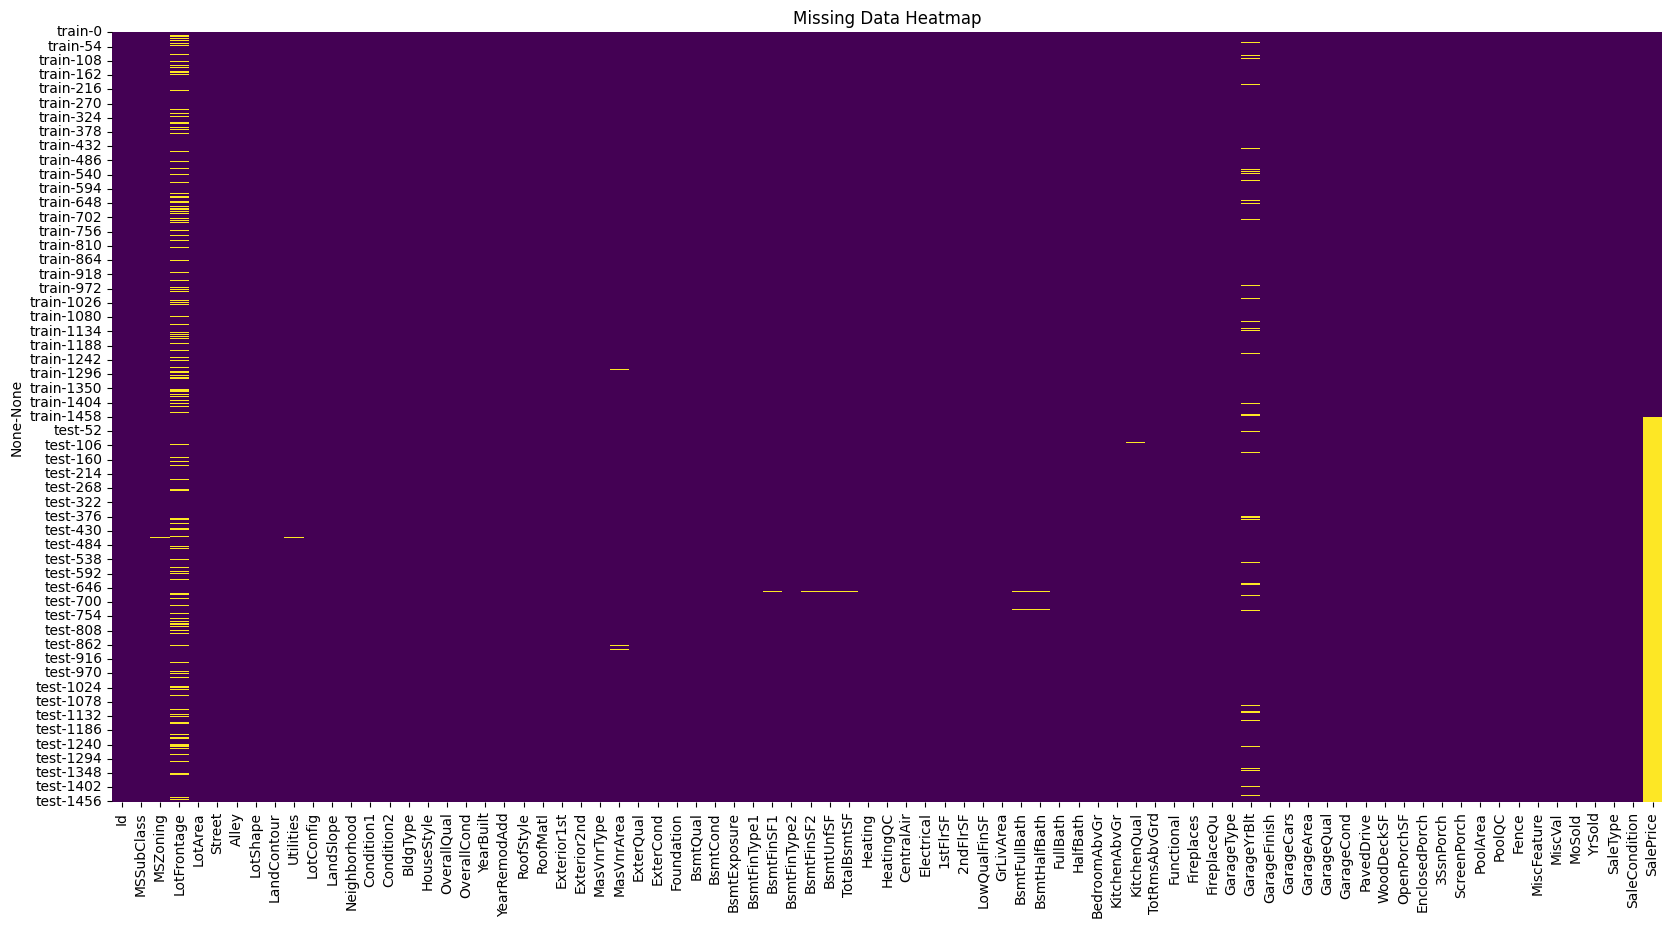

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(merged.isna(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()

In [ ]:
merged

Id MSSubClass MSZoning  LotFrontage  LotArea Street  Alley  \
train 0        1         60       RL         65.0     8450   Pave  None_   
      1        2         20       RL         80.0     9600   Pave  None_   
      2        3         60       RL         68.0    11250   Pave  None_   
      3        4         70       RL         60.0     9550   Pave  None_   
      4        5         60       RL         84.0    14260   Pave  None_   
...          ...        ...      ...          ...      ...    ...    ...   
test  1454  2915        160       RM         21.0     1936   Pave  None_   
      1455  2916        160       RM         21.0     1894   Pave  None_   
      1456  2917         20       RL        160.0    20000   Pave  None_   
      1457  2918         85       RL         62.0    10441   Pave  None_   
      1458  2919         60       RL         74.0     9627   Pave  None_   

           LotShape LandContour Utilities  ... PoolArea PoolQC  Fence  \
train 0         Reg         Lvl    AllPub  ...        0  None_  None_   
      1         Reg         Lvl    AllPub  ...        0  None_  None_   
      2         IR1         Lvl    AllPub  ...        0  None_  None_   
      3         IR1         Lvl    AllPub  ...        0  None_  None_   
      4         IR1         Lvl    AllPub  ...        0  None_  None_   
...             ...         ...       ...  ...      ...    ...    ...   
test  1454      Reg         Lvl    AllPub  ...        0  None_  None_   
      1455      Reg         Lvl    AllPub  ...        0  None_  None_   
      1456      Reg         Lvl    AllPub  ...        0  None_  None_   
      1457      Reg         Lvl    AllPub  ...        0  None_  MnPrv   
      1458      Reg         Lvl    AllPub  ...        0  None_  None_   

           MiscFeature MiscVal MoSold YrSold SaleType SaleCondition  SalePrice  
train 0          None_       0      2   2008       WD        Normal   208500.0  
      1          None_       0      5   2007       WD        Normal   181500.0  
      2          None_       0      9   2008       WD        Normal   223500.0  
      3          None_       0      2   2006       WD       Abnorml   140000.0  
      4          None_       0     12   2008       WD        Normal   250000.0  
...                ...     ...    ...    ...      ...           ...        ...  
test  1454       None_       0      6   2006       WD        Normal        NaN  
      1455       None_       0      4   2006       WD       Abnorml        NaN  
      1456       None_       0      9   2006       WD       Abnorml        NaN  
      1457        Shed     700      7   2006       WD        Normal        NaN  
      1458       None_       0     11   2006       WD        Normal        NaN  

[2919 rows x 81 columns]

In [ ]:
print(merged.isna().sum().sum())
print(merged.count().sum())
print(merged.isna().sum().sum()/merged.count().sum()) #to know how much of the missing data accounts the real data

2150
234289
0.009176700570662728


Even though the missing valueaccounts less than 1 percent of the data, the method we will be using to manage missing values is going to imputation. since the columns that are with the missing values are very cruical for predicting the price of the house so must be manged properly with caution.

In [ ]:
#missing managmnet is going to be through imputing
# so selcting those missng values that are object and numeric type while excluding GarageYrBlt since it is datetime type
#  LotFrontage is also going to included eventhough it has the highest number of missing values next to GarageYrBlt
columns = ['Exterior1st','BsmtFinSF2','BsmtFinSF1','Exterior2nd','KitchenQual','Electrical','TotalBsmtSF','BsmtUnfSF','GarageArea','SaleType','GarageCars','BsmtFullBath','Functional','BsmtHalfBath','Utilities','MSZoning','MasVnrArea','LotFrontage']
merged[merged[columns].isna().any(axis=1)]

Id MSSubClass MSZoning  LotFrontage  LotArea Street  Alley  \
train 7        8         60       RL          NaN    10382   Pave  None_   
      12      13         20       RL          NaN    12968   Pave  None_   
      14      15         20       RL          NaN    10920   Pave  None_   
      16      17         20       RL          NaN    11241   Pave  None_   
      24      25         20       RL          NaN     8246   Pave  None_   
...          ...        ...      ...          ...      ...    ...    ...   
test  1402  2863         20       RL         75.0     8050   Pave  None_   
      1440  2901         20       RL          NaN    50102   Pave  None_   
      1441  2902         20       RL          NaN     8098   Pave  None_   
      1444  2905         20      NaN        125.0    31250   Pave  None_   
      1448  2909         90       RL          NaN    11836   Pave  None_   

           LotShape LandContour Utilities  ... PoolArea PoolQC  Fence  \
train 7         IR1         Lvl    AllPub  ...        0  None_  None_   
      12        IR2         Lvl    AllPub  ...        0  None_  None_   
      14        IR1         Lvl    AllPub  ...        0  None_   GdWo   
      16        IR1         Lvl    AllPub  ...        0  None_  None_   
      24        IR1         Lvl    AllPub  ...        0  None_  MnPrv   
...             ...         ...       ...  ...      ...    ...    ...   
test  1402      Reg         Lvl    AllPub  ...        0  None_  None_   
      1440      IR1         Low    AllPub  ...        0  None_  None_   
      1441      IR1         Lvl    AllPub  ...        0  None_  None_   
      1444      Reg         Lvl    AllPub  ...        0  None_  None_   
      1448      IR1         Lvl    AllPub  ...        0  None_  None_   

           MiscFeature MiscVal MoSold YrSold SaleType SaleCondition  SalePrice  
train 7           Shed     350     11   2009       WD        Normal   200000.0  
      12         None_       0      9   2008       WD        Normal   144000.0  
      14         None_       0      5   2008       WD        Normal   157000.0  
      16          Shed     700      3   2010       WD        Normal   149000.0  
      24         None_       0      5   2010       WD        Normal   154000.0  
...                ...     ...    ...    ...      ...           ...        ...  
test  1402       None_       0      4   2006       WD        Normal        NaN  
      1440       None_       0      3   2006       WD        Alloca        NaN  
      1441       None_       0     10   2006       WD        Normal        NaN  
      1444       None_       0      5   2006       WD        Normal        NaN  
      1448       None_       0      3   2006       WD        Normal        NaN  

[514 rows x 81 columns]

In [ ]:
merged[columns].info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 2919 entries, ('train', np.int64(0)) to ('test', np.int64(1458))
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Exterior1st   2918 non-null   object 
 1   BsmtFinSF2    2918 non-null   float64
 2   BsmtFinSF1    2918 non-null   float64
 3   Exterior2nd   2918 non-null   object 
 4   KitchenQual   2918 non-null   object 
 5   Electrical    2918 non-null   object 
 6   TotalBsmtSF   2918 non-null   float64
 7   BsmtUnfSF     2918 non-null   float64
 8   GarageArea    2918 non-null   float64
 9   SaleType      2918 non-null   object 
 10  GarageCars    2918 non-null   float64
 11  BsmtFullBath  2917 non-null   float64
 12  Functional    2917 non-null   object 
 13  BsmtHalfBath  2917 non-null   float64
 14  Utilities     2917 non-null   object 
 15  MSZoning      2915 non-null   object 
 16  MasVnrArea    2896 non-null   float64
 17  LotFrontage   2433 non-null   

Since columns that are object type and numerical type needs to be separated since we will be using diffrent methods of imputation for them.

In [ ]:
#separating the float from object for imputaion purpose
o=merged[columns].select_dtypes(include='object').columns.tolist()
print(o)
f=merged [columns].select_dtypes(include ='float64').columns.to_list()
print(f)
merged[merged[o].isna().any(axis=1)]

['Exterior1st', 'Exterior2nd', 'KitchenQual', 'Electrical', 'SaleType', 'Functional', 'Utilities', 'MSZoning']
['BsmtFinSF2', 'BsmtFinSF1', 'TotalBsmtSF', 'BsmtUnfSF', 'GarageArea', 'GarageCars', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea', 'LotFrontage']


Id MSSubClass MSZoning  LotFrontage  LotArea Street  Alley  \
train 1379  1380         80       RL         73.0     9735   Pave  None_   
test  95    1556         50       RL         72.0    10632   Pave  None_   
      455   1916         30      NaN        109.0    21780   Grvl  None_   
      485   1946         20       RL          NaN    31220   Pave  None_   
      691   2152         30       RL         85.0    19550   Pave  None_   
      756   2217         20      NaN         80.0    14584   Pave  None_   
      790   2251         70      NaN          NaN    56600   Pave  None_   
      1013  2474         50       RM         60.0    10320   Pave   Grvl   
      1029  2490         20       RL         85.0    13770   Pave  None_   
      1444  2905         20      NaN        125.0    31250   Pave  None_   

           LotShape LandContour Utilities  ... PoolArea PoolQC  Fence  \
train 1379      Reg         Lvl    AllPub  ...        0  None_  None_   
test  95        IR1         Lvl    AllPub  ...        0  None_  None_   
      455       Reg         Lvl       NaN  ...        0  None_  None_   
      485       IR1         Bnk       NaN  ...        0  None_  None_   
      691       Reg         Lvl    AllPub  ...        0  None_  None_   
      756       Reg         Low    AllPub  ...        0  None_  None_   
      790       IR1         Low    AllPub  ...        0  None_  None_   
      1013      Reg         Lvl    AllPub  ...        0  None_  None_   
      1029      Reg         Lvl    AllPub  ...        0  None_  None_   
      1444      Reg         Lvl    AllPub  ...        0  None_  None_   

           MiscFeature MiscVal MoSold YrSold SaleType SaleCondition  SalePrice  
train 1379       None_       0      5   2008       WD        Normal   167500.0  
test  95         None_       0      1   2010      COD        Normal        NaN  
      455        None_       0      3   2009    ConLD        Normal        NaN  
      485         Shed     750      5   2008       WD        Normal        NaN  
      691        None_       0      1   2008       WD        Normal        NaN  
      756        None_       0      2   2008       WD       Abnorml        NaN  
      790        None_       0      1   2008       WD        Normal        NaN  
      1013       None_       0      9   2007      COD       Abnorml        NaN  
      1029       None_       0     10   2007      NaN        Normal        NaN  
      1444       None_       0      5   2006       WD        Normal        NaN  

[10 rows x 81 columns]

We will be using mode for categorical methods and KNN imputation methods for the floats.

In [ ]:
# imputing using mode for categorical and using knn method for the numericals
print(merged[o].mode())
merged[o]=merged[o].fillna(merged[o].mode().iloc[0])
merged[o].isna().sum()

  Exterior1st Exterior2nd KitchenQual Electrical SaleType Functional  \
0     VinylSd     VinylSd          TA      SBrkr       WD        Typ   

  Utilities MSZoning  
0    AllPub       RL  


,0
Exterior1st,0
Exterior2nd,0
KitchenQual,0
Electrical,0
SaleType,0
Functional,0
Utilities,0
MSZoning,0


In [ ]:
merged['Utilities'].isna().sum()

np.int64(0)

In [ ]:
#differeniating betweeen categroical datas as nominal and ordinal
nominal_cols = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LandContour', 'LotConfig',
                'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
                'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
                'Foundation', 'Heating', 'CentralAir', 'Electrical', 'GarageType',
                'MiscFeature', 'SaleType', 'SaleCondition']
ordinal_cols = ['LotShape', 'Utilities', 'LandSlope', 'OverallQual', 'OverallCond',
                'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
                'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual', 'Functional',
                'FireplaceQu', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence','GarageFinish']

In [ ]:
print(merged['OverallCond'].dtype)
print(merged['OverallQual'].dtype)

object
object


from the ordinals as we can see only utilities  is having a na values with count of only thta was imputed by th emode so if any means of unapplicablity of th eprevious code then it will assurely be replaced here nad changed in to numerical data type. for others categorical data we will be replacing each and every categorical variables that have a natural orded into numeric scores since we  will be working on machine learning we need every thing in numbers. The process we will be dioing is called **ordinal coding.**

In [ ]:
#mapping ordinal type of datas by numerical scores based on there expected range
ordinal_mappings = {
    'LotShape': {'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1},
    'Utilities': {'AllPub': 4, 'NoSeWa': 2,'NaN':4},
    'LandSlope': {'Gtl': 3, 'Mod': 2, 'Sev': 1},
    'OverallQual': {10: 10, 9: 9, 8: 8, 7: 7, 6: 6, 5: 5, 4: 4, 3: 3, 2: 2, 1: 1},
    'OverallCond': {10: 10, 9: 9, 8: 8, 7: 7, 6: 6, 5: 5, 4: 4, 3: 3, 2: 2, 1: 1},
    'ExterQual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1},
    'ExterCond': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1},
    'BsmtQual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None_': 0},
    'BsmtCond': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None_': 0},
    'BsmtExposure': {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None_': 0},
    'BsmtFinType1': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None_': 0},
    'BsmtFinType2': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None_': 0},
    'HeatingQC': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1},
    'KitchenQual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1},
    'Functional': {'Typ': 8, 'Min1': 7, 'Min2': 6, 'Mod': 5, 'Maj1': 4, 'Maj2': 3, 'Sev': 2, 'Sal': 1},
    'FireplaceQu': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None_': 0},
    'GarageQual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None_': 0},
    'GarageCond': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None_': 0},
    'PavedDrive': {'Y': 3, 'P': 2, 'N': 1},
    'PoolQC': {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'None_': 0},
    'Fence': {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'None_': 0},
    'GarageFinish': {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None_': 0}
}
for col, mapping in ordinal_mappings.items():
    merged[col] = merged[col].map(mapping).astype('int')

In [ ]:
merged.loc[('test',[455,485]),'Utilities']

test  455    4
      485    4
Name: Utilities, dtype: int64

In [ ]:
print(merged['Utilities'].unique())
print(merged['Utilities'].isna().sum())
print(merged['Utilities'].dtype)

[4 2]
0
int64


For numerical variables, missing values were handled using a K-Nearest Neighbors (KNN) imputation approach with feature selection based on correlation.

Instead of using all numerical variables in the dataset for imputing a specific column, a targeted and data-driven strategy was applied to improve both accuracy and robustness of the imputation.

**Step 1: Identification of Relevant Features**

For each numerical variable containing missing values, the pairwise correlation between the target variable and all other numerical variables was computed.
Only features with an absolute correlation coefficient ≥ 0.2 were retained, ensuring that only meaningfully related variables contributed to the distance calculation. the correlation used a spearman correlation since  the data features used are not normally distributed.

This step reduces noise, avoids distortion of distances by irrelevant features, and improves the quality of nearest-neighbor selection.

**Step 2: Construction of a Feature-Specific Subset**

For each target variable, a subset of the dataset was constructed consisting of:

The variable to be imputed, and

Its filtered, highly correlated features (|r| ≥ 0.2)

This ensures that imputation is column-specific and context-aware, rather than global.

**Step 3: Feature Scaling**

Because KNN is a distance-based algorithm, all selected features were standardized using z-score normalization (StandardScaler) prior to imputation.
This guarantees that features measured on different scales contribute equally to the distance computation.

**Step 4: KNN Imputation**

KNN imputation was then applied to the standardized subset using:

k = 5 nearest neighbors

For each missing value:

The algorithm identified the five most similar observations based on Euclidean distance computed across the selected correlated features.

The missing value was imputed using the mean value of the corresponding neighbors.

**Step 5: Inverse Transformation and Value Replacement**

After imputation, the standardized values were transformed back to their original scale using the inverse transformation of the fitted scaler.
Only the missing entries in the target variable were replaced, ensuring that observed values remained unchanged

**To prevent target leakage, the SalePrice variable was explicitly excluded from all stages of the imputation process, including correlation analysis, feature selection, distance computation, and neighbor identification. This ensured that imputed feature values were derived solely from predictor information.**


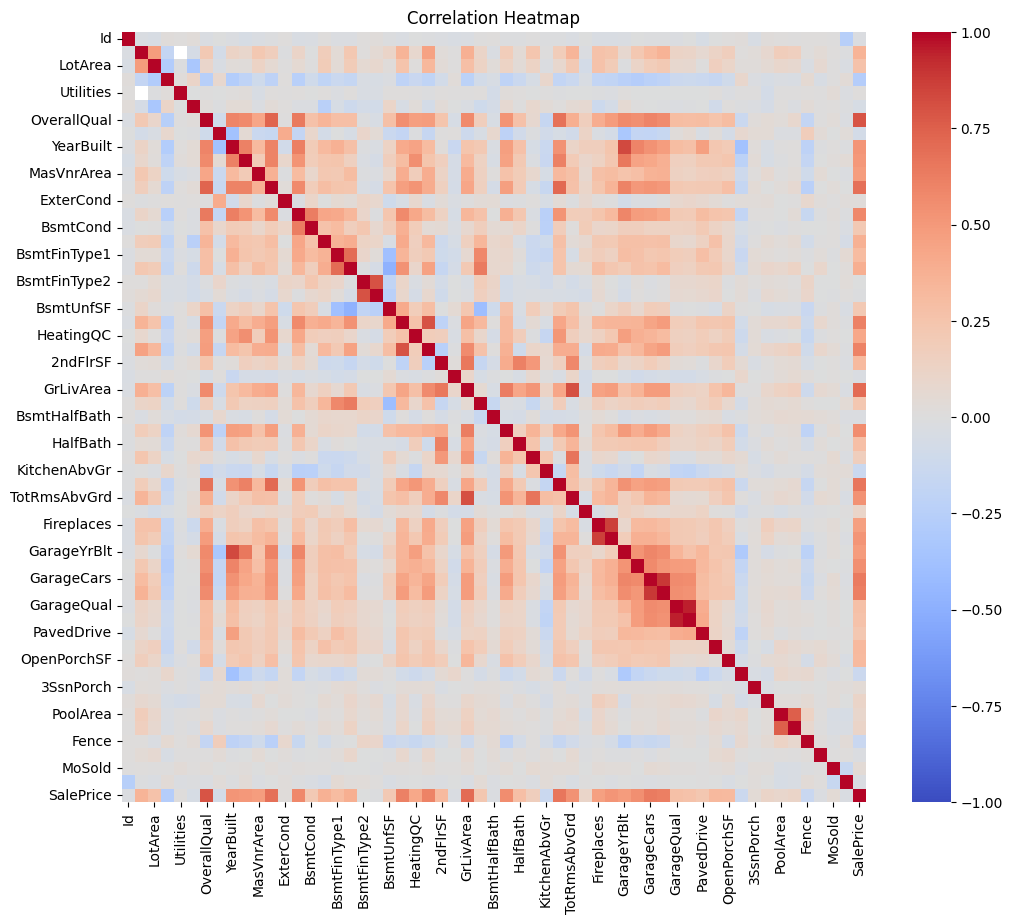

LotFrontage  Id            -0.027549
             LandSlope     -0.061969
             OverallCond   -0.075508
             LotShape      -0.172441
             Utilities           NaN
dtype: float64
WoodDeckSF          0
PavedDrive          0
GarageCond          0
MoSold              0
YrSold              0
SaleType            0
MiscVal             0
SaleCondition       0
BsmtFinSF1          1
BsmtFinSF2          1
GarageArea          1
TotalBsmtSF         1
BsmtUnfSF           1
GarageCars          1
BsmtFullBath        2
BsmtHalfBath        2
MasVnrArea         23
GarageYrBlt       159
LotFrontage       486
SalePrice        1459
dtype: int64


,0
LotArea,0.489896
1stFlrSF,0.458247
GrLivArea,0.382462
GarageArea,0.359786
TotalBsmtSF,0.354822
SalePrice,0.351799
TotRmsAbvGrd,0.349513
GarageCars,0.310587
Fireplaces,0.261970
FireplaceQu,0.246242


In [ ]:
#while for categorical we use knn due to the relations between the features  so to do that first correlation btween the numerical values sould be done
#correlation with pearsons
corr_matrix = merged.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()
corr_series=corr_matrix.unstack()
corr_series=corr_series[corr_series != 1]
corr_series_abs= abs(corr_series)
sorted_corr=corr_series.sort_values(ascending=False)
sorted_corr_abs=corr_series_abs.sort_values(ascending=False)


f_corr=sorted_corr.loc[f]
f_corr_abs=sorted_corr_abs.loc[f]
print(f_corr.tail())
f_corr_abs
print(merged.isna().sum().sort_values().tail(20))
f_corr_abs.loc['LotFrontage']

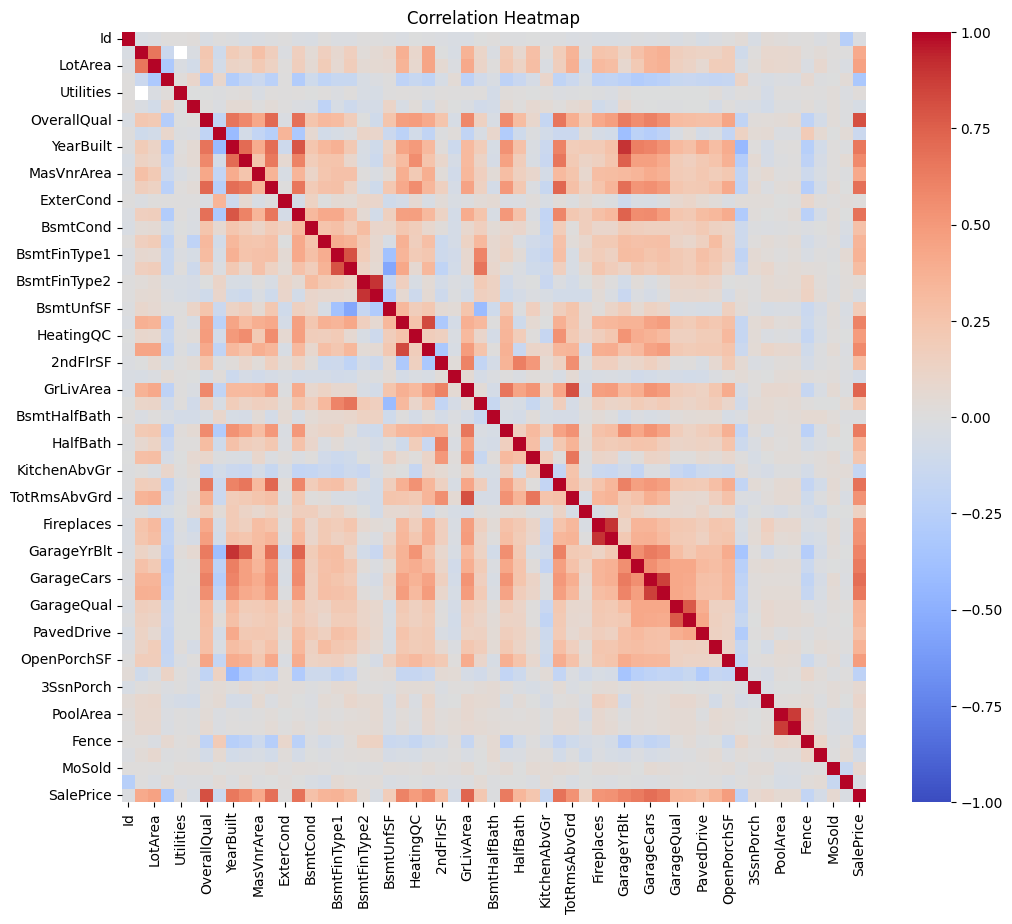

LotFrontage  LowQualFinSF    -0.043211
             EnclosedPorch   -0.094946
             OverallCond     -0.106011
             LotShape        -0.128579
             Utilities             NaN
dtype: float64
WoodDeckSF          0
PavedDrive          0
GarageCond          0
MoSold              0
YrSold              0
SaleType            0
MiscVal             0
SaleCondition       0
BsmtFinSF1          1
BsmtFinSF2          1
GarageArea          1
TotalBsmtSF         1
BsmtUnfSF           1
GarageCars          1
BsmtFullBath        2
BsmtHalfBath        2
MasVnrArea         23
GarageYrBlt       159
LotFrontage       486
SalePrice        1459
dtype: int64


,0
LotArea,0.657113
1stFlrSF,0.444356
SalePrice,0.409076
GarageArea,0.378027
TotalBsmtSF,0.377806
GrLivArea,0.360486
TotRmsAbvGrd,0.358117
GarageCars,0.351241
BedroomAbvGr,0.283391
MasVnrArea,0.273822


In [ ]:
#correlation with spearmans
corr_matrix = merged.corr(numeric_only=True,method='spearman')
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()
corr_series=corr_matrix.unstack()
corr_series=corr_series[corr_series != 1]
corr_series_abs= abs(corr_series)
sorted_corr=corr_series.sort_values(ascending=False)
sorted_corr_abs=corr_series_abs.sort_values(ascending=False)


f_corr=sorted_corr.loc[f]
f_corr_abs=sorted_corr_abs.loc[f]
print(f_corr.tail())
f_corr_abs
print(merged.isna().sum().sort_values().tail(20))
f_corr_abs.loc['LotFrontage']

In [ ]:
#we are gonna go with spearmans as its the choosable since the data is not normally distributed
''' Identify features from the original list 'f' that did not have any
significant absolute correlation (above 0.2) with other features
and therefore were not included as the first level in the index
of f_corr_abs_top'''
f_corr_abs.head()
print(f)
f_corr_abs_top=f_corr_abs[f_corr_abs>0.2]
f_corr_abs_top.loc['LotFrontage']

['BsmtFinSF2', 'BsmtFinSF1', 'TotalBsmtSF', 'BsmtUnfSF', 'GarageArea', 'GarageCars', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea', 'LotFrontage']


,0
LotArea,0.657113
1stFlrSF,0.444356
SalePrice,0.409076
GarageArea,0.378027
TotalBsmtSF,0.377806
GrLivArea,0.360486
TotRmsAbvGrd,0.358117
GarageCars,0.351241
BedroomAbvGr,0.283391
MasVnrArea,0.273822


From the correlation analysis, we observe that **all features except `BsmtHalfBath` exhibit at least one correlation greater than 0.2 with other features**. Although some correlations exceed the 0.2 threshold, **`BsmtFinSF2` is correlated with only one feature above this threshold, with a relatively weak correlation of approximately 0.23**.

The motivation for selecting **k-Nearest Neighbors (kNN) imputation** is to achieve higher accuracy compared to simple mean or median imputation by leveraging information from multiple related features. However, when only a single weakly correlated feature is available, **kNN imputation becomes unreliable and may introduce noise rather than improve estimation accuracy**.

Therefore, for **`BsmtFinSF2` and `BsmtHalfBath`**, **mean or median imputation will be applied depending on their underlying distributions**. For the remaining features, **kNN imputation will be performed using all features that have correlations greater than 0.2**, ensuring that the imputation process is supported by sufficiently informative relationships.


In [ ]:
#droping 'BsmtHalfBath' from the list f
f.remove('BsmtHalfBath')
f.remove('BsmtFinSF2')

In [ ]:
top_features= f_corr_abs_top.loc['MasVnrArea'].index.to_list()
top_features

['OverallQual',
 'SalePrice',
 'GarageCars',
 'YearBuilt',
 'TotalBsmtSF',
 '1stFlrSF',
 'GarageArea',
 'ExterQual',
 'GarageFinish',
 'BsmtQual',
 'GrLivArea',
 'GarageYrBlt',
 'KitchenQual',
 'FireplaceQu',
 'Fireplaces',
 'FullBath',
 'LotFrontage',
 'BsmtFinType1',
 'BsmtFinSF1',
 'YearRemodAdd',
 'TotRmsAbvGrd',
 'BsmtExposure',
 'PavedDrive',
 'OpenPorchSF',
 'HeatingQC',
 'LotArea',
 'GarageQual']

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
merged_imputed=merged.copy()
for col in f:
  top_features= f_corr_abs_top.loc[col].index.to_list()
  #creating a subset dataframe consisting of the specfic coloumn and its most correlated features
  sub_df=merged_imputed[[col]+top_features]
  # standardization since multiple of the features have different measurment
  scaler=StandardScaler()
  sub_scaled=scaler.fit_transform(sub_df)
  #impute
  imputer=KNNImputer(n_neighbors=5)
  sub_imputed=imputer.fit_transform(sub_scaled)
  #inverse scaling
  sub_imputed_unscaled = scaler.inverse_transform(sub_imputed)
  #Replace only the missing values in the original DataFrame
  merged_imputed.loc[merged[col].isnull(),col]=sub_imputed_unscaled[merged[col].isnull(),0]
print( merged_imputed.isna().sum().sort_values(ascending=False).head(20))

SalePrice       1459
GarageYrBlt      159
BsmtHalfBath       2
BsmtFinSF2         1
LotArea            0
MSSubClass         0
MSZoning           0
LotFrontage        0
LandContour        0
Utilities          0
LotConfig          0
LandSlope          0
Neighborhood       0
Street             0
Alley              0
LotShape           0
Id                 0
HouseStyle         0
BldgType           0
Condition2         0
dtype: int64


In [ ]:
merged['BsmtHalfBath'].dtype

dtype('float64')

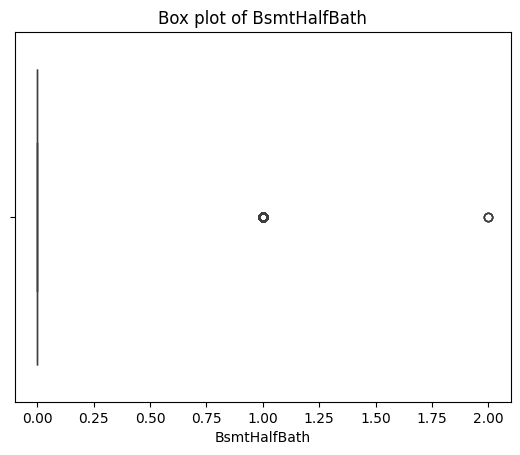

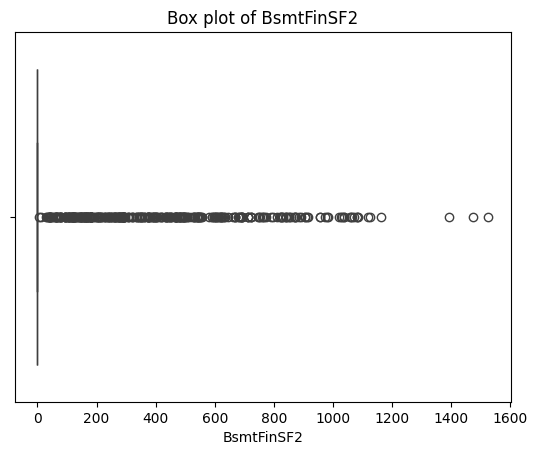

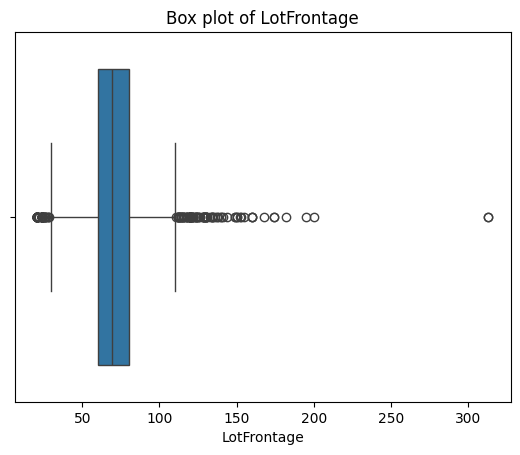

In [ ]:
#imputing the rest of the features
rest = ['BsmtHalfBath', 'BsmtFinSF2','LotFrontage']
for col in rest:
    plt.figure() # Create a new figure for each box plot
    sns.boxplot(x=merged_imputed[col])
    plt.title(f'Box plot of {col}')
    plt.xlabel(col)
    plt.show()

In [ ]:
#since the distribution of both features is skewwed the best way of imputing is median
rest=['BsmtHalfBath','BsmtFinSF2']
for col in rest:
  merged_imputed[col]=merged_imputed[col].fillna(merged_imputed[col].median())
print(merged_imputed.isna().sum().sort_values(ascending=False).head(10))

SalePrice      1459
GarageYrBlt     159
MSZoning          0
MSSubClass        0
LotArea           0
Street            0
Alley             0
LotFrontage       0
LandContour       0
Utilities         0
dtype: int64


In [ ]:
#imputing the rest of the features like BsmtHalfBath BsmtFinSF2
merged_imputed.isna().sum().sort_values(ascending=False).head(10)

,0
SalePrice,1459
GarageYrBlt,159
MSZoning,0
MSSubClass,0
LotArea,0
Street,0
Alley,0
LotFrontage,0
LandContour,0
Utilities,0


# Coming to the date type feature called GarageYrBlt

In [ ]:
#those with no garage cant have a value for GarageYrBlt so filling the na value by zero for those specfic rows
merged_imputed[['GarageYrBlt','GarageType']]
merged_imputed.loc[merged_imputed['GarageType']=='None_','GarageYrBlt']= merged_imputed.loc[merged_imputed['GarageType']=='None_','GarageYrBlt'].fillna(0)
merged_imputed.isna().sum().sort_values(ascending=False).head(10)

,0
SalePrice,1459
GarageYrBlt,2
MSZoning,0
MSSubClass,0
LotArea,0
Street,0
Alley,0
LotFrontage,0
LandContour,0
Utilities,0


In [ ]:
#illogical YearRemodAdd after YearSold
merged_imputed[(merged_imputed['YearRemodAdd'])>(merged_imputed['YrSold'])][['YearRemodAdd','YrSold']]

YearRemodAdd  YrSold
train 523           2008    2007
test  835           2008    2007
      1089          2009    2007

## Temporal Consistency and Logical Validation Checks

To ensure data quality and chronological consistency, a set of logical validation rules was applied to all year-related variables. These checks were designed to identify impossible or illogical temporal relationships that may arise from data entry errors or inconsistencies.

### Identified Logical Constraints

- **Remodeling Year vs. Construction Year**
  - `YearRemodAdd` must not be earlier than `YearBuilt`.
  - A property cannot be remodeled before it is constructed.
  - Violations of this rule were flagged as illogical temporal inconsistencies.

- **Garage Construction Year vs. House Construction Year**
  - `GarageYrBlt` must not be earlier than `YearBuilt`.
  - A garage cannot logically be built before the main structure.
  - Such cases were identified as illogical records.

- **Year of Sale vs. Year of Construction (Critical Error)**
  - `YrSold` must not be earlier than `YearBuilt`.
  - A property cannot be sold before it exists.
  - Records violating this condition were treated as critical data errors.

- **Garage Construction Year vs. Year of Sale**
  - `GarageYrBlt` must not be later than `YrSold`.
  - A garage cannot be constructed after the property has been sold.
  - These cases were flagged as post-sale construction inconsistencies.

In [ ]:
#checking for any errors and inconsistencies
#illogical YearRemodAdd before YearBuilt
merged_imputed[(merged_imputed['GarageYrBlt'])>(merged_imputed['YrSold'])][['GarageYrBlt','YrSold']]

GarageYrBlt  YrSold
test 1089       2008.0    2007
     1132       2207.0    2007

In [ ]:
#illogical GarageYrBlt before YearBuilt xpt those with zero values
merged_imputed[((merged_imputed['GarageYrBlt'])<(merged_imputed['YearBuilt']))&((merged_imputed['GarageYrBlt'])!=0)][['GarageYrBlt','YearBuilt']]


GarageYrBlt  YearBuilt
train 29         1920.0       1927
      93         1900.0       1910
      324        1961.0       1967
      600        2003.0       2005
      736        1949.0       1950
      1103       1954.0       1959
      1376       1925.0       1930
      1414       1922.0       1923
      1418       1962.0       1963
test  61         1956.0       1959
      116        2009.0       2010
      345        1920.0       1935
      380        1960.0       1978
      435        1940.0       1941
      437        1926.0       1935
      662        1925.0       1945
      803        2005.0       2006
      1049       2005.0       2006

In [ ]:
#critical error of YrSold before YearBuilt
merged_imputed[((merged_imputed['YrSold'])<(merged_imputed['YearBuilt']))][['YearBuilt','YrSold']]

,,YearBuilt,YrSold
test,1089,2008,2007


In [ ]:
#illogical GarageYrBlt after YrSold
merged_imputed[((merged_imputed['YearRemodAdd'])<(merged_imputed['YearBuilt']))][['YearBuilt','YearRemodAdd']]

,,YearBuilt,YearRemodAdd
test,416,2002,2001


## Managing Temporal Inconsistencies in Year-Based Variables

To correct illogical chronological relationships in the dataset without dropping records, **rule-based adjustments** were applied to year-related variables. Each correction enforces realistic temporal ordering while preserving all observations.

### Correction Rules Applied

- **Remodel Year Before Build Year**
  - Condition: `YearRemodAdd < YearBuilt`
  - Action: Set `YearRemodAdd = YearBuilt`
  - Rationale: A property cannot be remodeled before construction.

- **Sale Year Before Build Year (Critical Error)**
  - Condition: `YrSold < YearBuilt`
  - Action: Set `YrSold = YearBuilt`
  - Rationale: A property cannot be sold before it exists.

- **Garage Built Before House (Excluding Zero Values)**
  - Condition: `GarageYrBlt < YearBuilt` and `GarageYrBlt != 0`
  - Action: Set `GarageYrBlt = YearBuilt`
  - Rationale: A garage cannot predate the main structure.

- **Garage Built After Sale**
  - Condition: `GarageYrBlt > YrSold`
  - Action: Set `GarageYrBlt = YrSold`
  - Rationale: A garage cannot be constructed after the property is sold.

- **Remodel Year After Sale**
  - Condition: `YearRemodAdd > YrSold`
  - Action: Set `YearRemodAdd = YrSold`
  - Rationale: Renovation cannot occur after the sale year.

In [ ]:
# manging the errors
condition1= merged_imputed['YearRemodAdd']<merged_imputed['YearBuilt']
condition2= merged_imputed['YrSold']<merged_imputed['YearBuilt']
condition3= ((merged_imputed['GarageYrBlt'])<(merged_imputed['YearBuilt']))&((merged_imputed['GarageYrBlt'])!=0)
condition4= merged_imputed['GarageYrBlt']>merged_imputed['YrSold']
condition5= merged_imputed['YearRemodAdd']>merged_imputed['YrSold']
#since droping is not an option we will be setting YearRemodAdd equal to YearBuilt
merged_imputed.loc[condition1,'YearRemodAdd']=merged_imputed.loc[condition1,'YearBuilt']
merged_imputed[condition1][['YearRemodAdd','YearBuilt']]
#set Yrsold to yearBuilt
merged_imputed.loc[condition2,'YrSold']=merged_imputed.loc[condition2,'YearBuilt']
#set GarageYrBlt to YearBuilt
merged_imputed.loc[condition3,'GarageYrBlt']=merged_imputed.loc[condition3,'YearBuilt']
#set GarageYrBlt to YrSold
merged_imputed.loc[condition4,'GarageYrBlt']=merged_imputed.loc[condition4,'YrSold']
#set YrRemod add to Yrsold
merged_imputed.loc[condition5,'YearRemodAdd']=merged_imputed.loc[condition5,'YrSold']
l=[condition1,condition2,condition3,condition4,condition5]
for condition in l:
  print(merged_imputed[condition][['YearRemodAdd','YrSold','GarageYrBlt','YearBuilt']])



          YearRemodAdd  YrSold  GarageYrBlt  YearBuilt
test 416          2002    2009       2002.0       2002
           YearRemodAdd  YrSold  GarageYrBlt  YearBuilt
test 1089          2008    2008       2008.0       2008
            YearRemodAdd  YrSold  GarageYrBlt  YearBuilt
train 29            1950    2008       1927.0       1927
      93            1998    2007       1910.0       1910
      324           2007    2010       1967.0       1967
      600           2005    2006       2005.0       2005
      736           1950    2006       1950.0       1950
      1103          1959    2006       1959.0       1959
      1376          1950    2008       1930.0       1930
      1414          2000    2008       1923.0       1923
      1418          1963    2008       1963.0       1963
test  61            1959    2010       1959.0       1959
      116           2010    2010       2010.0       2010
      345           1998    2009       1935.0       1935
      380           1978    2009     

In [ ]:
#trying to see what kind of gargetype has a missing year of garage construction date
print(merged_imputed.loc[merged_imputed['GarageYrBlt'].isna(),'GarageType'].unique())
merged_imputed.loc[merged_imputed['GarageType']=='Detchd','GarageYrBlt'].mean()

['Detchd']


np.float64(1961.3011583011582)

In [ ]:
#trying to see the relationship between the year the home was built and the garage was built
#comparing which one is greater in number those with same number of yearbuilt and grage built or those with differnt values
print(merged_imputed[merged_imputed['YearBuilt']!=merged_imputed['GarageYrBlt']][['YearBuilt','GarageYrBlt']].value_counts().sum())
print(merged_imputed[merged_imputed['YearBuilt']==merged_imputed['GarageYrBlt']][['YearBuilt','GarageYrBlt']].value_counts().sum())
#trying to see the relationship between the year the home was remodeled and the garage was built
#comparing which on is greater in number those with same number of yearRemodAdd and garage built or those with differnt values
print(merged_imputed[merged_imputed['YearRemodAdd']!=merged_imputed['GarageYrBlt']][['YearRemodAdd','GarageYrBlt']].value_counts().sum())
print(merged_imputed[merged_imputed['YearRemodAdd']==merged_imputed['GarageYrBlt']][['YearRemodAdd','GarageYrBlt']].value_counts().sum())

683
2234
1434
1483


In [ ]:
#trying to see what type of garage we are dealing with
merged_imputed.loc[merged_imputed['GarageYrBlt'].isna(),['GarageType','YearBuilt','YearRemodAdd']]

GarageType  YearBuilt  YearRemodAdd
test 666      Detchd       1910          1983
     1116     Detchd       1923          1999

In [ ]:
merged_imputed.loc[merged_imputed['GarageType']=='Detchd',['GarageYrBlt','YearBuilt','YearRemodAdd']]

GarageYrBlt  YearBuilt  YearRemodAdd
train 3          1998.0       1915          1970
      8          1931.0       1931          1950
      10         1965.0       1965          1965
      12         1962.0       1962          1962
      15         1991.0       1929          2001
...                 ...        ...           ...
test  1426       1942.0       1942          1950
      1427       1950.0       1926          1950
      1429       1925.0       1925          1950
      1430       1957.0       1957          1957
      1456       1960.0       1960          1996

[779 rows x 3 columns]

In [ ]:
merged_imputed['YearRemodAdd'].dtype

dtype('int32')

In [ ]:
#going specfic  as we are trying to number of houses with detached garages
print(merged_imputed[merged_imputed['GarageType'] == 'Detchd'].value_counts().sum())


387


In [ ]:
#trying to find out how many of these detached garages were built in the same year as the house was built
filtered_df = merged_imputed[(merged_imputed['GarageType'] == 'Detchd') & (merged_imputed['YearBuilt']== merged_imputed['GarageYrBlt'])]

# Select the desired columns from the filtered DataFrame and calculate the sum of value counts
sum_of_counts = filtered_df[['YearBuilt', 'GarageYrBlt']].value_counts().sum()

# Print the result if needed
print(sum_of_counts)
#trying to find out how many of these detached garages were built in the same year as the house was remodeled
fill_df=merged_imputed[(merged_imputed['GarageType']=='Detchd')&(merged_imputed['YearRemodAdd']==merged_imputed['GarageYrBlt'])]
print(fill_df[['YearRemodAdd','GarageYrBlt']].value_counts().sum())

392
179


In [ ]:
merged_imputed[['GarageYrBlt','MoSold','YrSold','YearBuilt','YearRemodAdd']]

GarageYrBlt  MoSold  YrSold  YearBuilt  YearRemodAdd
train 0          2003.0       2    2008       2003          2003
      1          1976.0       5    2007       1976          1976
      2          2001.0       9    2008       2001          2002
      3          1998.0       2    2006       1915          1970
      4          2000.0      12    2008       2000          2000
...                 ...     ...     ...        ...           ...
test  1454          0.0       6    2006       1970          1970
      1455       1970.0       4    2006       1970          1970
      1456       1960.0       9    2006       1960          1996
      1457          0.0       7    2006       1992          1992
      1458       1993.0      11    2006       1993          1994

[2919 rows x 5 columns]

In [ ]:
#the number shows that among 387 observations of houses with detached garage 382 of these gragaes were built in the same year the houses were built.
#this is greater than the year remodeling year similarity which is only 175(that has the same year of remodeling and garage building)
#so we will go with yearbuilt for imputing
merged_imputed['GarageYrBlt'].fillna(merged_imputed['YearBuilt'],inplace=True)
merged_imputed.isna().sum().sort_values(ascending=False).head(10)



/tmp/ipython-input-3816086110.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_imputed['GarageYrBlt'].fillna(merged_imputed['YearBuilt'],inplace=True)


,0
SalePrice,1459
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
Street,0
Alley,0
LotShape,0
LandContour,0
Utilities,0


In [ ]:
merged_imputed['GarageYrBlt']=merged_imputed['GarageYrBlt'].astype('int')
merged_imputed['GarageYrBlt']

train  0       2003
       1       1976
       2       2001
       3       1998
       4       2000
               ... 
test   1454       0
       1455    1970
       1456    1960
       1457       0
       1458    1993
Name: GarageYrBlt, Length: 2919, dtype: int64

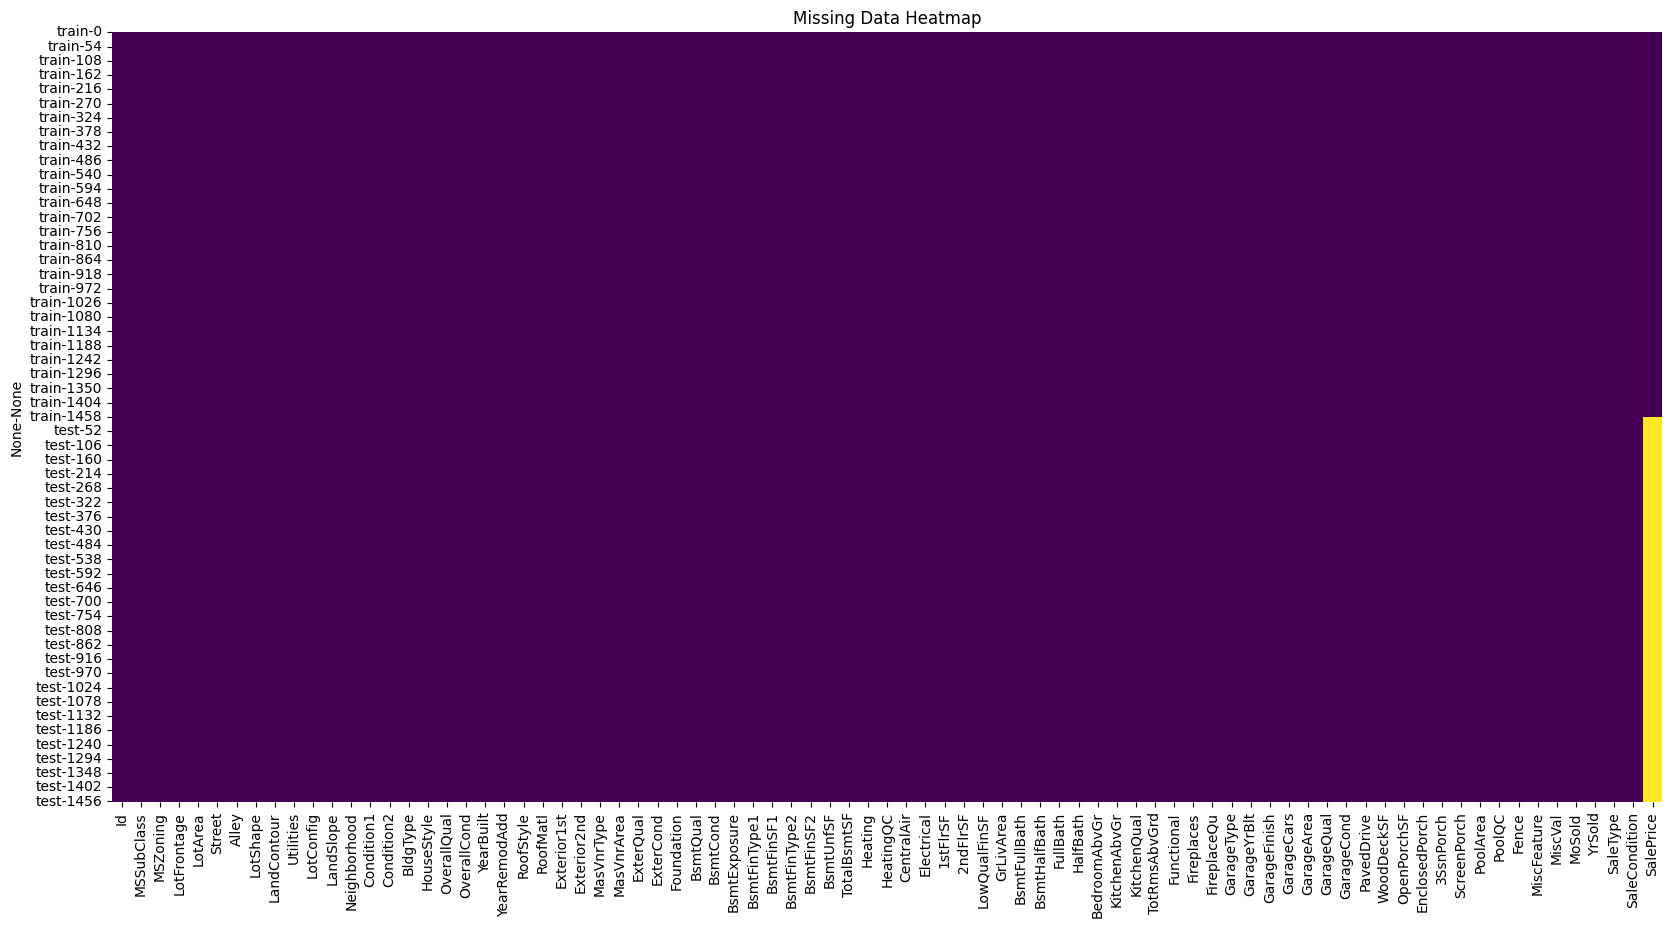

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(merged_imputed.isna(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()

In [ ]:
#identifying the date columns for feature transformation and preprocessing for machine learning
datetime_cols = merged_imputed.select_dtypes(include=['datetime64[ns]']).columns.tolist()
datetime_cols=['YearBuilt', 'YearRemodAdd', 'MoSold', 'YrSold','GarageYrBlt']
merged_imputed[datetime_cols]

YearBuilt  YearRemodAdd  MoSold  YrSold  GarageYrBlt
train 0          2003          2003       2    2008         2003
      1          1976          1976       5    2007         1976
      2          2001          2002       9    2008         2001
      3          1915          1970       2    2006         1998
      4          2000          2000      12    2008         2000
...               ...           ...     ...     ...          ...
test  1454       1970          1970       6    2006            0
      1455       1970          1970       4    2006         1970
      1456       1960          1996       9    2006         1960
      1457       1992          1992       7    2006            0
      1458       1993          1994      11    2006         1993

[2919 rows x 5 columns]

## Feature Extraction from Year-Based Variables

Since the original year columns only specify the timing of events and cannot be directly used in linear regression, new numerical features were derived to capture the **temporal status of the house**. These transformations provide meaningful, continuous variables that quantify the age and timing of key property characteristics relative to the sale.

The extracted features are:

- **HouseAge** = `YrSold - YearBuilt`  
  Represents the age of the house at the time of sale.

- **RemodAge** = `YrSold - YearRemodAdd`  
  Captures the time elapsed since the last remodel or addition.

- **GarageAge** = `YrSold - GarageYrBlt`  
  Indicates the age of the garage at the time of sale.

- **RemodDelay** = `YearRemodAdd - YearBuilt`  
  Measures the time between the house's original construction and its most recent remodel or addition.

These newly engineered features provide a **more informative and regression-ready representation** of the property’s lifecycle and improvements.


In [ ]:
merged_imputed_pro=merged_imputed.copy()

In [ ]:
merged_imputed['GarageYrBlt'].unique()

array([2003, 1976, 2001, 1998, 2000, 1993, 2004, 1973, 1931, 1939, 1965,
       2005, 1962, 2006, 1960, 1991, 1970, 1967, 1958, 1930, 2002, 1968,
       2007, 2008, 1957, 1927, 1920, 1966, 1959, 1995, 1954, 1953,    0,
       1983, 1977, 1997, 1985, 1963, 1981, 1964, 1999, 1935, 1990, 1945,
       1987, 1989, 1915, 1956, 1948, 1974, 2009, 1950, 1961, 1921, 1910,
       1979, 1951, 1969, 1936, 1975, 1971, 1923, 1984, 1926, 1955, 1986,
       1988, 1916, 1932, 1972, 1918, 1980, 1924, 1996, 1940, 1949, 1994,
       1978, 1982, 1992, 1925, 1941, 2010, 1947, 1937, 1942, 1938, 1952,
       1928, 1922, 1934, 1906, 1914, 1946, 1908, 1929, 1933, 1900, 1917,
       1896, 1895, 1943, 1919])

In [ ]:
#Feature Engineering
merged_imputed_pro['GarageAge']=merged_imputed['YrSold']-merged_imputed['GarageYrBlt']
merged_imputed_pro['RemodAge']=merged_imputed['YrSold']-merged_imputed['YearRemodAdd']
merged_imputed_pro['HouseAge']=merged_imputed['YrSold']-merged_imputed['YearBuilt']
merged_imputed_pro['RemodDelay']=merged_imputed['YearRemodAdd']-merged_imputed['YearBuilt']
merged_imputed_pro.drop(columns=['GarageYrBlt','YearRemodAdd','YearBuilt','YrSold'],inplace=True)
merged_imputed_pro.head()

Id MSSubClass MSZoning  LotFrontage  LotArea Street  Alley  LotShape  \
train 0   1         60       RL         65.0     8450   Pave  None_         4   
      1   2         20       RL         80.0     9600   Pave  None_         4   
      2   3         60       RL         68.0    11250   Pave  None_         3   
      3   4         70       RL         60.0     9550   Pave  None_         3   
      4   5         60       RL         84.0    14260   Pave  None_         3   

        LandContour  Utilities  ... MiscFeature  MiscVal MoSold SaleType  \
train 0         Lvl          4  ...       None_        0      2       WD   
      1         Lvl          4  ...       None_        0      5       WD   
      2         Lvl          4  ...       None_        0      9       WD   
      3         Lvl          4  ...       None_        0      2       WD   
      4         Lvl          4  ...       None_        0     12       WD   

        SaleCondition SalePrice GarageAge  RemodAge  HouseAge RemodDelay  
train 0        Normal  208500.0         5         5         5          0  
      1        Normal  181500.0        31        31        31          0  
      2        Normal  223500.0         7         6         7          1  
      3       Abnorml  140000.0         8        36        91         55  
      4        Normal  250000.0         8         8         8          0  

[5 rows x 81 columns]

In [ ]:
merged_imputed_pro['GarageAge'].unique()

array([   5,   31,    7,    8,   16,    3,   36,   77,   69,   43,    1,
         46,   48,   40,   39,    4,   51,    6,   42,    2,   49,   81,
         88,   14,   55,   57, 2008,   41,   24,   47, 2009,   10,   21,
         25,   45,   44,    0,   35,   72,   20,   11,   65,   53,   34,
         95,   52,   60, 2010,   33,   15, 2007,   56,   97,   90,   30,
         54,   62,   37,   28,   50, 2006,    9,   38,   17,   12,   78,
         70,   32,   83,   19,   22,   86,   13,   93,   75,   82,   61,
         66,   18,   29,   96,   27,   59,   67,   26,   79,   89,   68,
         87,   74,   92,   94,   71,   80,   58,   84,   23,   76,   73,
        102,   85,   64,   99,  100,   91,  110,   63,  114,  109,   98,
        113,  108,  106])

In [ ]:
#since the 2010,2008,2006,2007 and 2009 are obtained by subustracting the yr sold from the gargeyr built which was zero in thefirst place
# this shows they are values of those that dont posess garages so we will making the value of garageage 0
merged_imputed_pro.loc[merged_imputed_pro['GarageType']=='None_','GarageAge']=0
merged_imputed_pro['GarageAge'].unique()

array([  5,  31,   7,   8,  16,   3,  36,  77,  69,  43,   1,  46,  48,
        40,  39,   4,  51,   6,  42,   2,  49,  81,  88,  14,  55,  57,
         0,  41,  24,  47,  10,  21,  25,  45,  44,  35,  72,  20,  11,
        65,  53,  34,  95,  52,  60,  33,  15,  56,  97,  90,  30,  54,
        62,  37,  28,  50,   9,  38,  17,  12,  78,  70,  32,  83,  19,
        22,  86,  13,  93,  75,  82,  61,  66,  18,  29,  96,  27,  59,
        67,  26,  79,  89,  68,  87,  74,  92,  94,  71,  80,  58,  84,
        23,  76,  73, 102,  85,  64,  99, 100,  91, 110,  63, 114, 109,
        98, 113, 108, 106])

In [ ]:
merged_imputed_pro['RemodDelay'].unique()

array([  0,   1,  55,   2,  19,  11,  72,   7,  20,  33,  49,  40,  23,
        30,  36,  54,   5,  88,  16,   6,  76,  29,  24,  35,  53,  71,
        67,  85, 110,  86,  18,  57,  47,  43,  25,  62,  14,  15,  27,
        26,  78,  59,  38,   9,  51,  83, 101,  32,   3,  39,  10,  52,
        50,   8,  48,  79,  58,  82,  17, 122,  65,  34,  75,  60,  42,
        77,  28,  22,  61,  46,  89,  80,  13,  63,  90,  70,  37, 100,
        44,   4,  81, 107,  21,  64, 111,  69,  31,  68,  96, 108,  56,
        92, 123,  94,  45,  87,  41,  74,  98,  12, 103, 106,  93, 104,
        73, 121, 115,  95,  84, 112,  97, 127, 109,  66, 116, 105],
      dtype=int32)

In [ ]:
merged_imputed_pro['HouseAge'].unique()

array([  5,  31,   7,  91,   8,  16,   3,  36,  77,  69,  43,   1,  46,
        48,  78,  40,  39,   4,  51,   6,  42,   2,  59,  49,  81,  88,
        15,  55,  57,  53,  41,  24,  33,  47,  89,  10,  72,  25,  52,
        44,   0,  87,  12,  65,  34,  11,  56,  95,  60,  99,  14,  94,
        13,  45,  97,  90,  30,  76, 122,  54,  62,  20,  37,  68,  50,
        71,   9,  38,  18,  58,  70,  32,  35,  83,  84,  66,  19,  22,
        86,  98, 114,  93,  75,  82,  17, 106,  29,  96,  27,  92, 128,
        61,  67,  21,  26, 108,  28,  63,  73,  74,  80, 115, 126, 102,
        85,  23, 110, 117, 129,  64, 100, 111, 104, 119, 127, 107, 135,
       109, 136, 103,  79, 125, 120, 118, 113, 112, 101], dtype=int32)

In [ ]:
merged_imputed_pro['RemodAge'].unique()

array([ 5, 31,  6, 36,  8, 14,  2, 58, 43,  0, 46, 48, 40, 39,  4, 44, 57,
        9, 10,  1, 51, 19,  3, 53, 41, 24, 28, 47, 56, 52, 11, 60, 21, 34,
        7, 42, 13, 27, 12, 45, 16, 25, 30, 33, 54, 20, 37, 50, 15, 38, 17,
       32, 35, 22, 18, 59, 29, 49, 26, 55, 23], dtype=int32)

In [ ]:
#performing cyclical encoding for month sold feature to preserve the periodic nature
merged_imputed_pro['MoSold_sin'] = np.sin(2 * np.pi * merged_imputed_pro['MoSold'] / 12)
merged_imputed_pro['MoSold_cos'] = np.cos(2 * np.pi * merged_imputed_pro['MoSold'] / 12)
merged_imputed_pro.drop(columns=['MoSold'],inplace=True)
merged_imputed_pro.head()

Id MSSubClass MSZoning  LotFrontage  LotArea Street  Alley  LotShape  \
train 0   1         60       RL         65.0     8450   Pave  None_         4   
      1   2         20       RL         80.0     9600   Pave  None_         4   
      2   3         60       RL         68.0    11250   Pave  None_         3   
      3   4         70       RL         60.0     9550   Pave  None_         3   
      4   5         60       RL         84.0    14260   Pave  None_         3   

        LandContour  Utilities  ... MiscVal  SaleType SaleCondition SalePrice  \
train 0         Lvl          4  ...       0        WD        Normal  208500.0   
      1         Lvl          4  ...       0        WD        Normal  181500.0   
      2         Lvl          4  ...       0        WD        Normal  223500.0   
      3         Lvl          4  ...       0        WD       Abnorml  140000.0   
      4         Lvl          4  ...       0        WD        Normal  250000.0   

        GarageAge RemodAge HouseAge  RemodDelay    MoSold_sin    MoSold_cos  
train 0         5        5        5           0  8.660254e-01  5.000000e-01  
      1        31       31       31           0  5.000000e-01 -8.660254e-01  
      2         7        6        7           1 -1.000000e+00 -1.836970e-16  
      3         8       36       91          55  8.660254e-01  5.000000e-01  
      4         8        8        8           0 -2.449294e-16  1.000000e+00  

[5 rows x 82 columns]

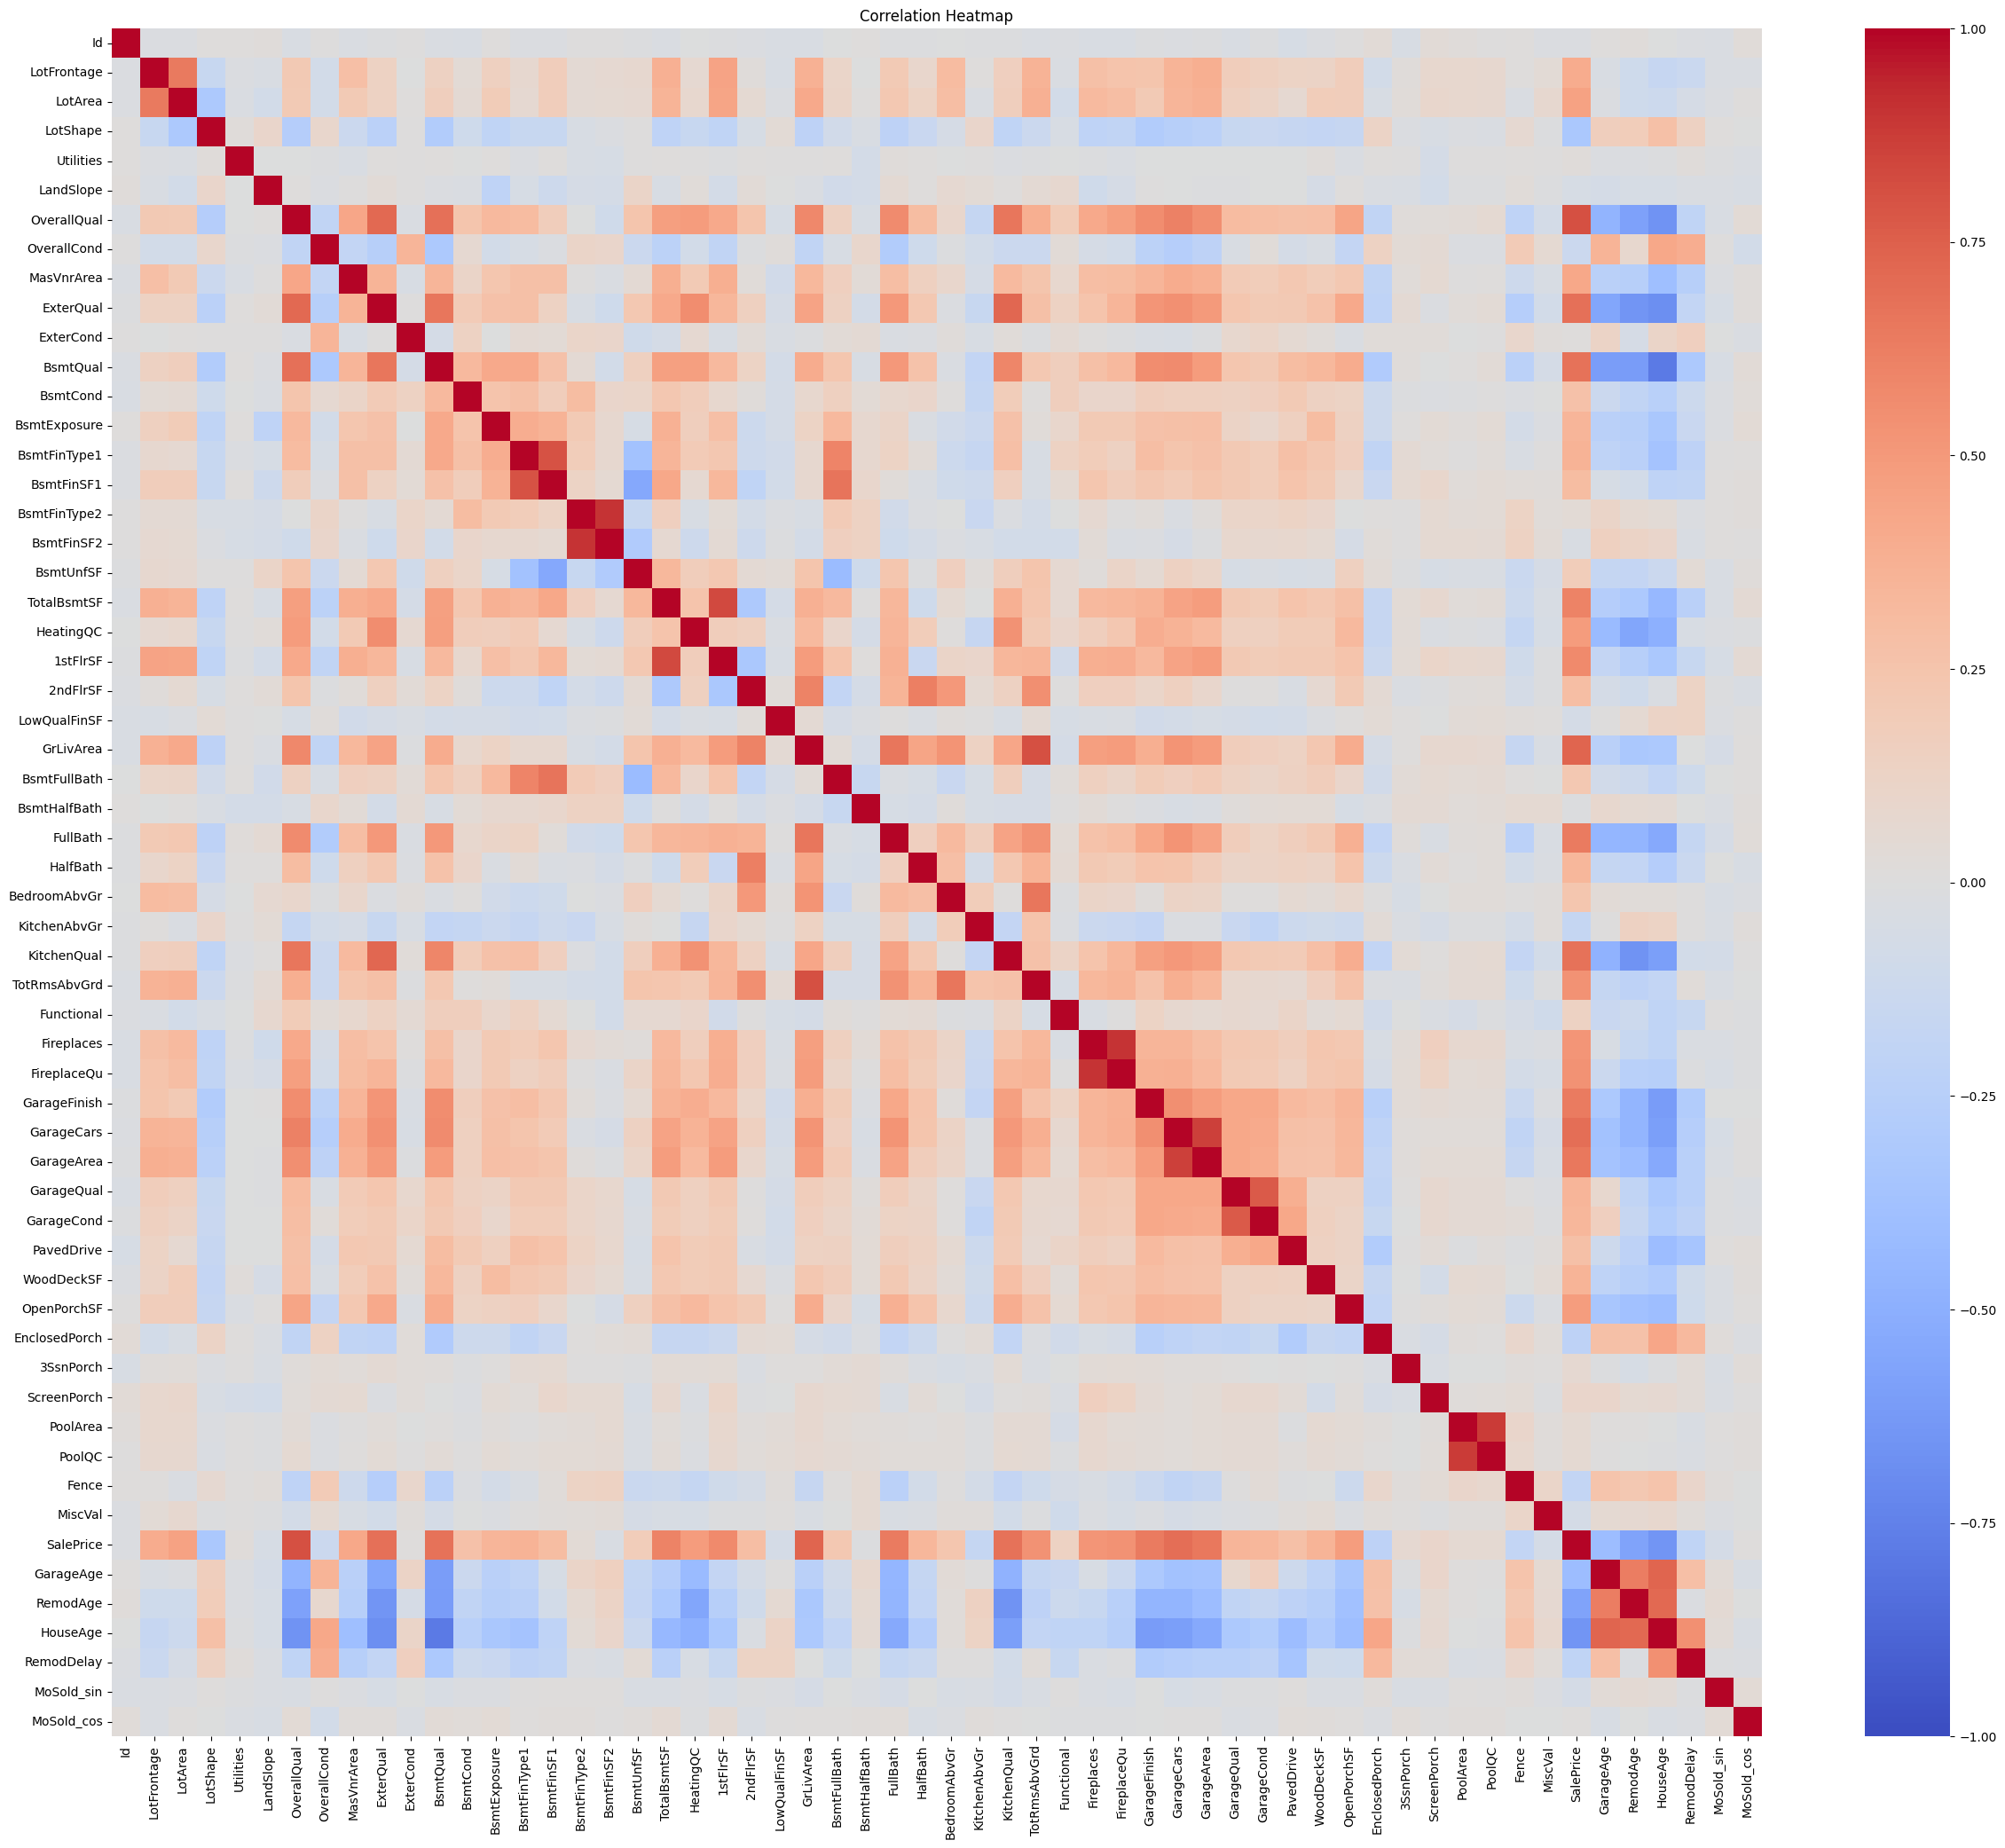

,Feature1,Feature2,corr
0,BsmtFinType2,BsmtFinSF2,0.904212
1,FireplaceQu,Fireplaces,0.903822
2,PoolQC,PoolArea,0.876900
3,GarageCars,GarageArea,0.864929
4,1stFlrSF,TotalBsmtSF,0.828737
...,...,...,...
1648,PoolArea,ExterCond,0.000350
1649,MoSold_sin,BsmtFullBath,0.000342
1650,OverallQual,Utilities,0.000315
1651,HalfBath,MoSold_sin,0.000058


In [ ]:
corr_matrix2 = merged_imputed_pro.corr(numeric_only=True,method='spearman')
plt.figure(figsize=(30, 25))
sns.heatmap(corr_matrix2, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()
corr_series2=corr_matrix2.unstack()
corr_series2=corr_series2[corr_series2 != 1]
corr_series_abs2= abs(corr_series2)
sorted_corr2=corr_series2.sort_values(ascending=False)
sorted_corr_abs2=corr_series_abs2.sort_values(ascending=False)
sorted_corr_abs2.drop_duplicates(inplace=True)
sorted_corr_abs2=sorted_corr_abs2.reset_index()
sorted_corr_abs2.columns=['Feature1','Feature2','corr']
sorted_corr_abs2





In [ ]:
high_corr=sorted_corr_abs2[sorted_corr_abs2['corr']>0.75]
high_corr

,Feature1,Feature2,corr
0,BsmtFinType2,BsmtFinSF2,0.904212
1,FireplaceQu,Fireplaces,0.903822
2,PoolQC,PoolArea,0.876900
3,GarageCars,GarageArea,0.864929
4,1stFlrSF,TotalBsmtSF,0.828737
5,SalePrice,OverallQual,0.809829
6,TotRmsAbvGrd,GrLivArea,0.808775
7,BsmtFinSF1,BsmtFinType1,0.800615
8,HouseAge,BsmtQual,0.785176
9,GarageCond,GarageQual,0.771897


In [ ]:
sale_corr=merged_imputed_pro.corr(numeric_only=True,method='spearman')['SalePrice'].abs().sort_values(ascending=False)
sale_corr


,SalePrice
SalePrice,1.000000
OverallQual,0.809829
GrLivArea,0.731310
GarageCars,0.690711
ExterQual,0.684014
BsmtQual,0.678026
KitchenQual,0.672849
HouseAge,0.650120
GarageArea,0.649379
FullBath,0.635957


## Distribution Analysis and Log Transformation of Skewed Numerical Features

To prepare numerical features for linear regression, it is important to assess their distributions and ensure they approximate normality, as **Pearson correlation** assumes normally distributed variables.

### Visualization of Numerical Features
All relevant numerical features (excluding count-based variables) were first visualized using histograms and kernel density estimates (KDE). This step allowed us to:

- Identify features with **right-skewed distributions**
- Understand the overall spread and scale of each variable
- Detect potential outliers or extreme values

### Log Transformation of Skewed Features
Features exhibiting significant right skewness were log-transformed using `log1p` to reduce skewness and better approximate a normal distribution. The transformed features include:

- `LotArea`, `MasVnrArea`, `BsmtFinSF2`, `LowQualFinSF`, `3SsnPorch`, `ScreenPorch`, `PoolArea`, `MiscVal`, `OpenPorchSF`, `EnclosedPorch`, `RemodDelay`

After transformation, the distributions were re-plotted to confirm improved symmetry and suitability for correlation analysis and linear modeling.

### Purpose
These steps ensure that:

- Numerical features meet the assumptions for **Pearson correlation**
- Features are more suitable for **linear regression**
- Skewness and scale differences are minimized, improving model stability and interpretability


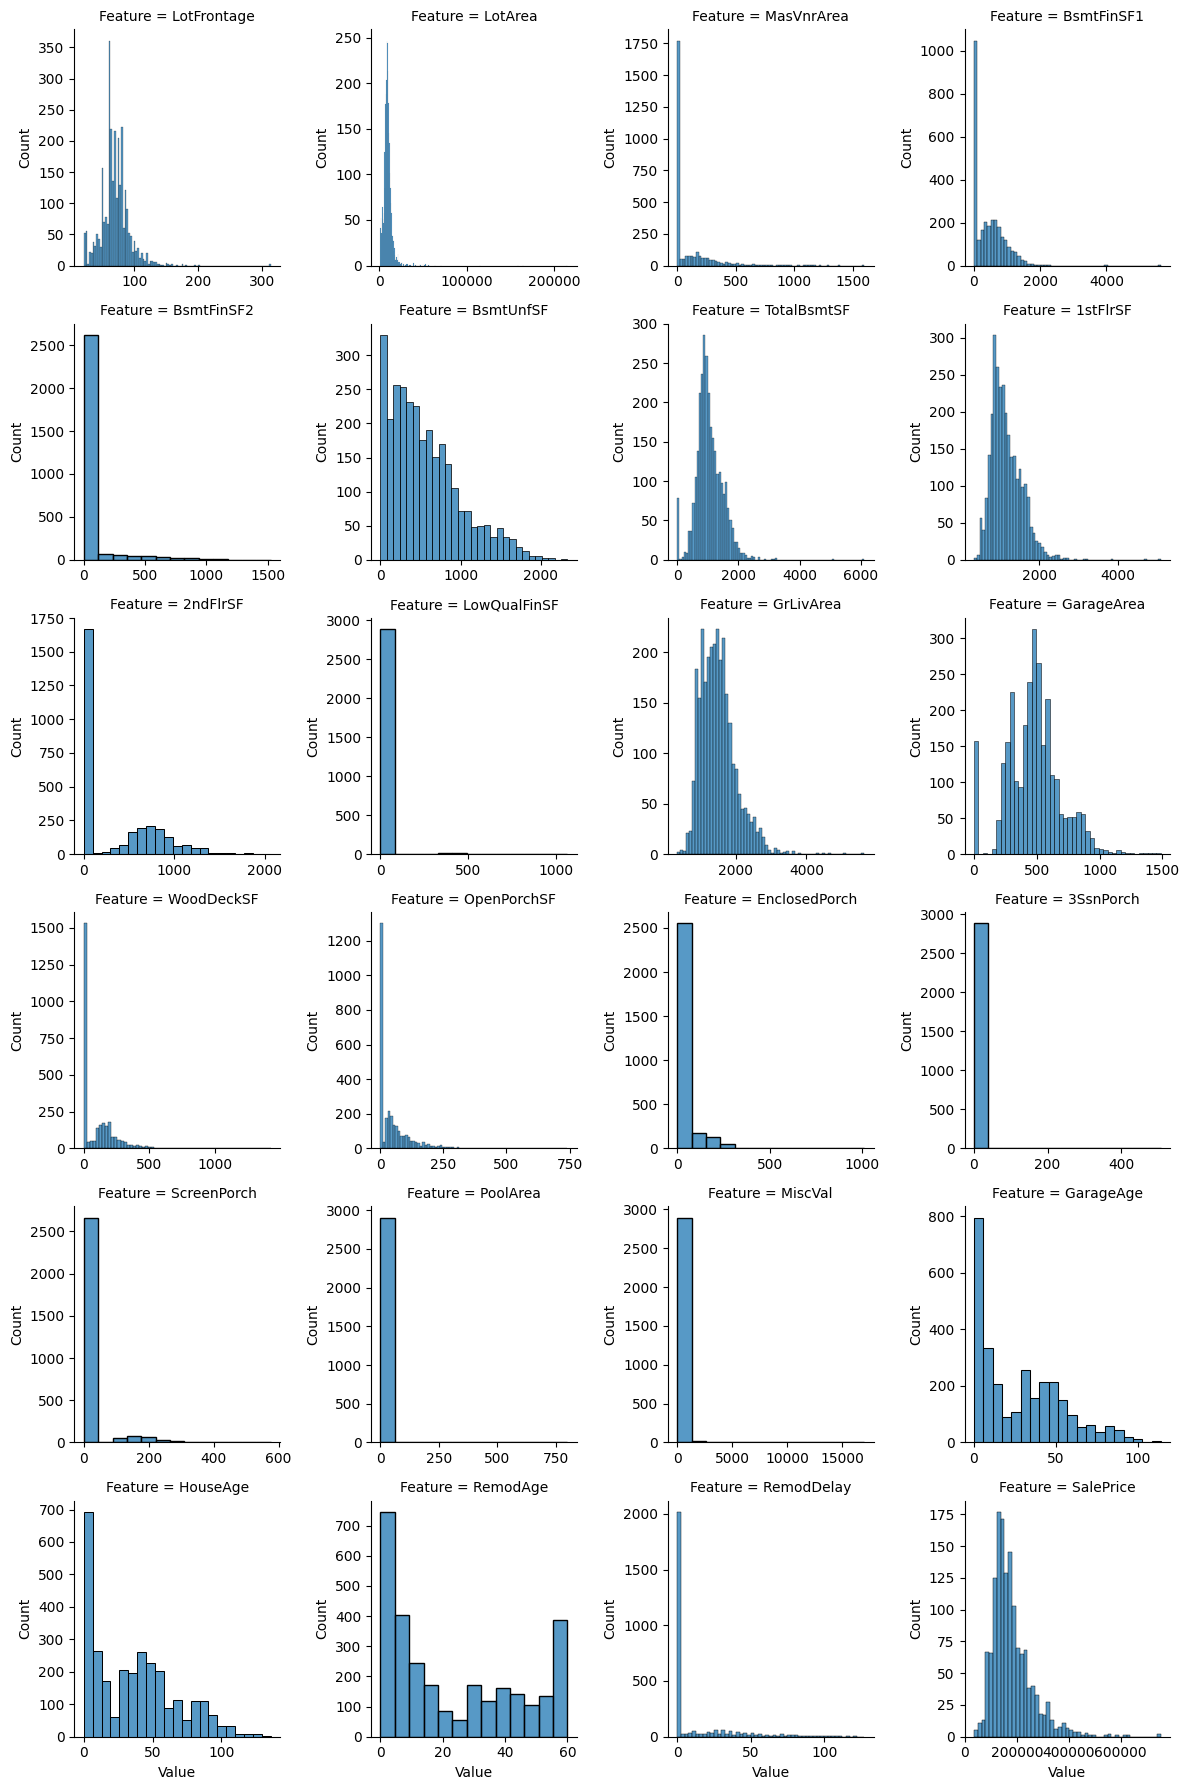

In [ ]:
#but since we are planing to do  linear regression we need pearson correlation and to do that we need to see the distribution numerical data types excluding the count types
#as we plan to log transform those those with right skewness so that persons could be applied as it requires normal distribution
# so we satrt by visualization
numeric=['LotFrontage','LotArea','MasVnrArea','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','1stFlrSF','2ndFlrSF','LowQualFinSF','GrLivArea','GarageArea','WoodDeckSF','OpenPorchSF','EnclosedPorch','3SsnPorch','ScreenPorch','PoolArea','MiscVal','GarageAge','HouseAge','RemodAge','RemodDelay','SalePrice']
df_melted = merged_imputed_pro[numeric].melt(var_name='Feature', value_name='Value')
g = sns.FacetGrid(df_melted, col='Feature', col_wrap=4, height=3, sharex=False, sharey=False)
g.map(sns.histplot, 'Value')
plt.tight_layout()
plt.show()

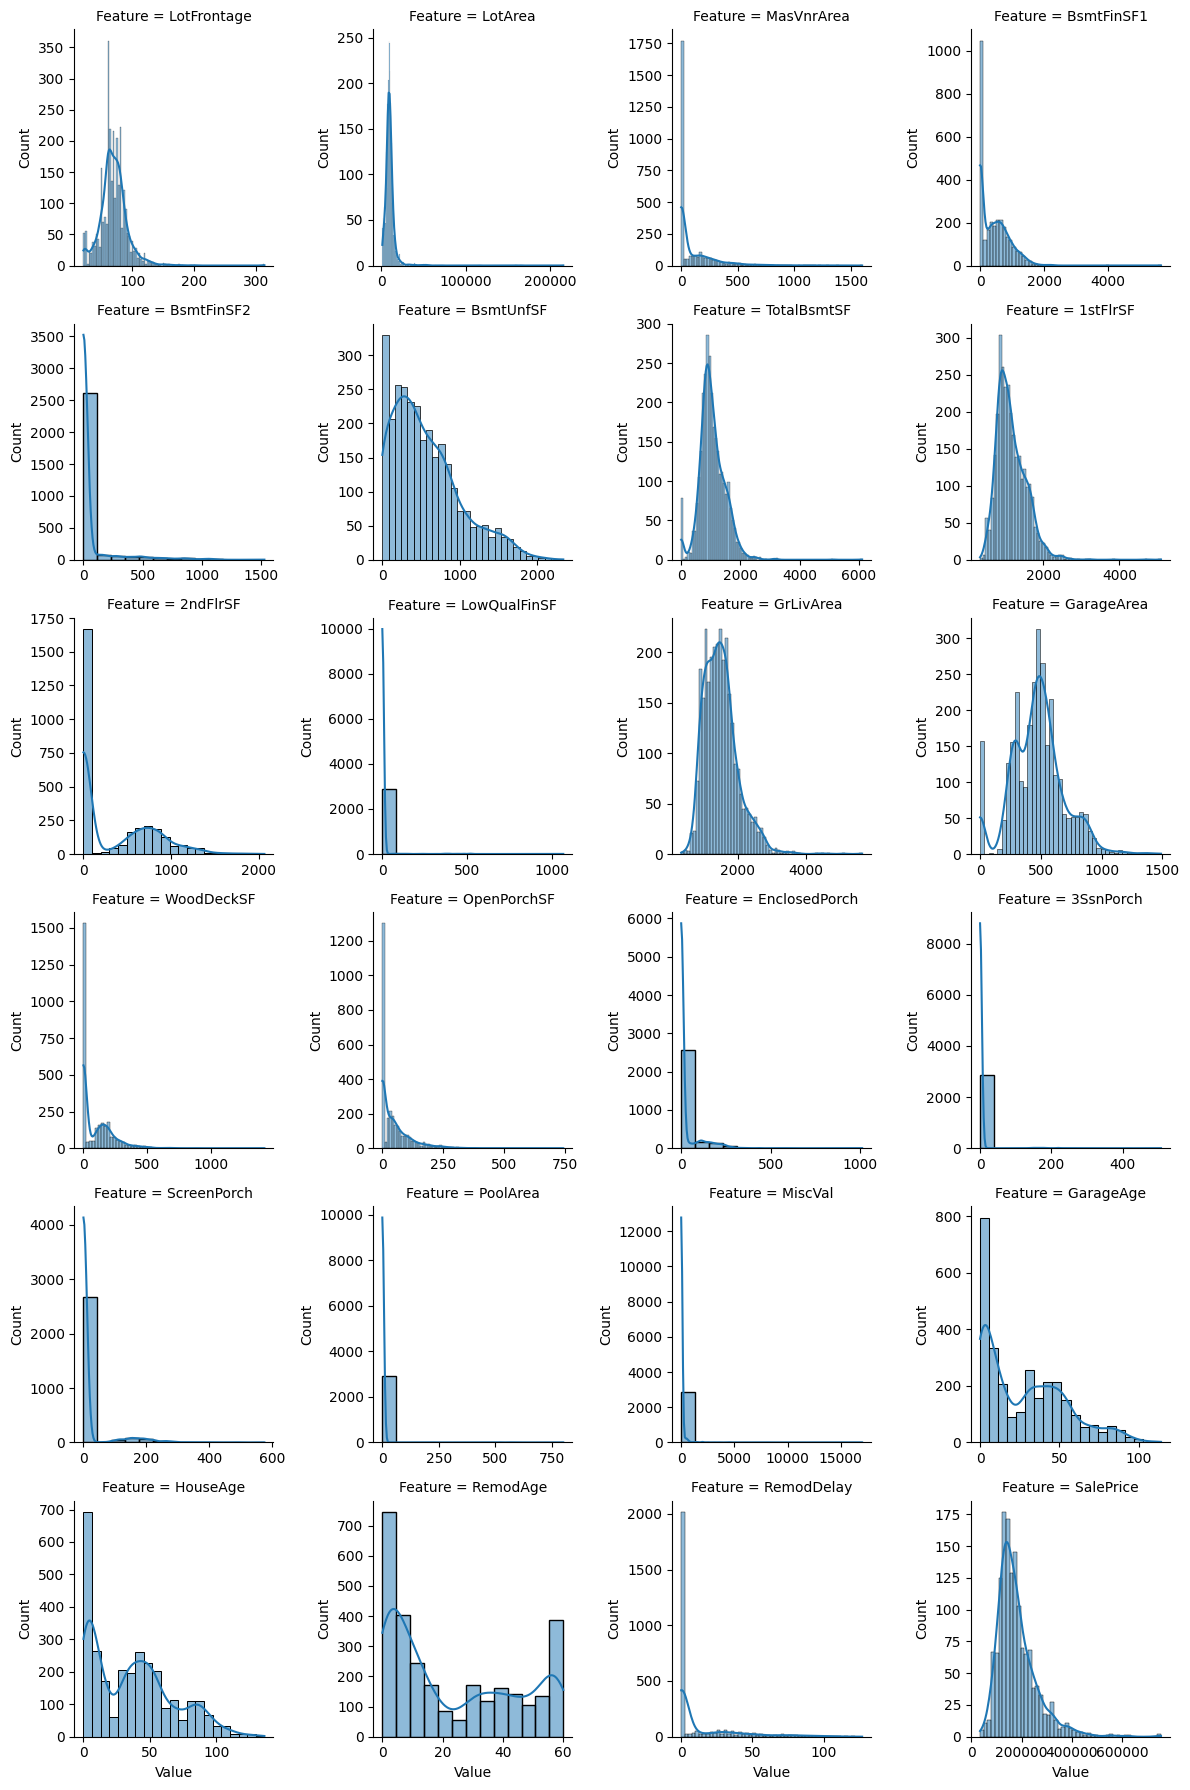

In [ ]:

df_melted = merged_imputed_pro[numeric].melt(var_name='Feature', value_name='Value')
g = sns.FacetGrid(df_melted, col='Feature', col_wrap=4, height=3, sharex=False, sharey=False)
g.map(sns.histplot, 'Value', kde=True)
plt.tight_layout()
plt.show()

saving one dataset that is not going to be log transformed for deep learning models.

In [ ]:
merged_raw=merged_imputed_pro.copy(deep=True)

In [ ]:
#log transformation of the skewed distributions
to_log=['LotArea','MasVnrArea','BsmtFinSF2','LowQualFinSF','3SsnPorch','ScreenPorch','PoolArea','MiscVal','OpenPorchSF','EnclosedPorch','RemodDelay']
for col in to_log:
  merged_imputed_pro[col]=np.log1p(merged_imputed_pro[col])

In [ ]:
merged_imputed_pro[to_log]

LotArea  MasVnrArea  BsmtFinSF2  LowQualFinSF  3SsnPorch  \
train 0     9.042040    5.283204         0.0           0.0        0.0   
      1     9.169623    0.000000         0.0           0.0        0.0   
      2     9.328212    5.093750         0.0           0.0        0.0   
      3     9.164401    0.000000         0.0           0.0        0.0   
      4     9.565284    5.860786         0.0           0.0        0.0   
...              ...         ...         ...           ...        ...   
test  1454  7.568896    0.000000         0.0           0.0        0.0   
      1455  7.546974    0.000000         0.0           0.0        0.0   
      1456  9.903538    0.000000         0.0           0.0        0.0   
      1457  9.253591    0.000000         0.0           0.0        0.0   
      1458  9.172431    4.553877         0.0           0.0        0.0   

            ScreenPorch  PoolArea   MiscVal  OpenPorchSF  EnclosedPorch  \
train 0             0.0       0.0  0.000000     4.127134       0.000000   
      1             0.0       0.0  0.000000     0.000000       0.000000   
      2             0.0       0.0  0.000000     3.761200       0.000000   
      3             0.0       0.0  0.000000     3.583519       5.609472   
      4             0.0       0.0  0.000000     4.442651       0.000000   
...                 ...       ...       ...          ...            ...   
test  1454          0.0       0.0  0.000000     0.000000       0.000000   
      1455          0.0       0.0  0.000000     3.218876       0.000000   
      1456          0.0       0.0  0.000000     0.000000       0.000000   
      1457          0.0       0.0  6.552508     3.496508       0.000000   
      1458          0.0       0.0  0.000000     3.891820       0.000000   

            RemodDelay  
train 0       0.000000  
      1       0.000000  
      2       0.693147  
      3       4.025352  
      4       0.000000  
...                ...  
test  1454    0.000000  
      1455    0.000000  
      1456    3.610918  
      1457    0.000000  
      1458    0.693147  

[2919 rows x 11 columns]

In [ ]:
merged_raw[to_log]

LotArea  MasVnrArea  BsmtFinSF2  LowQualFinSF  3SsnPorch  \
train 0        8450       196.0         0.0             0          0   
      1        9600         0.0         0.0             0          0   
      2       11250       162.0         0.0             0          0   
      3        9550         0.0         0.0             0          0   
      4       14260       350.0         0.0             0          0   
...             ...         ...         ...           ...        ...   
test  1454     1936         0.0         0.0             0          0   
      1455     1894         0.0         0.0             0          0   
      1456    20000         0.0         0.0             0          0   
      1457    10441         0.0         0.0             0          0   
      1458     9627        94.0         0.0             0          0   

            ScreenPorch  PoolArea  MiscVal  OpenPorchSF  EnclosedPorch  \
train 0               0         0        0           61              0   
      1               0         0        0            0              0   
      2               0         0        0           42              0   
      3               0         0        0           35            272   
      4               0         0        0           84              0   
...                 ...       ...      ...          ...            ...   
test  1454            0         0        0            0              0   
      1455            0         0        0           24              0   
      1456            0         0        0            0              0   
      1457            0         0      700           32              0   
      1458            0         0        0           48              0   

            RemodDelay  
train 0              0  
      1              0  
      2              1  
      3             55  
      4              0  
...                ...  
test  1454           0  
      1455           0  
      1456          36  
      1457           0  
      1458           1  

[2919 rows x 11 columns]

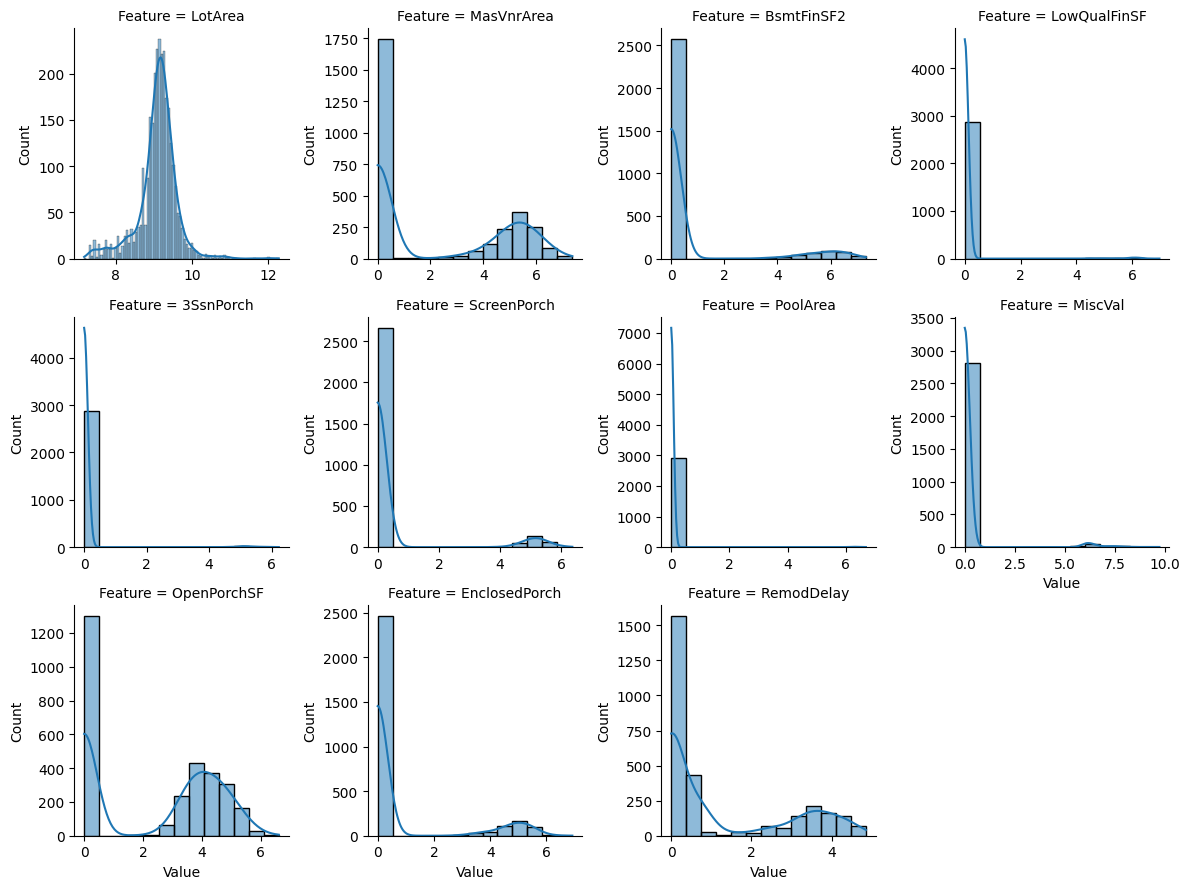

In [ ]:
df_melted = merged_imputed_pro[to_log].melt(var_name='Feature', value_name='Value')
g = sns.FacetGrid(df_melted, col='Feature', col_wrap=4, height=3, sharex=False, sharey=False)
g.map(sns.histplot, 'Value', kde=True)
plt.tight_layout()
plt.show()

## Pearson Correlation Analysis of Numerical Features

To explore the linear relationships between numerical variables in the dataset, a **Pearson correlation heatmap** was generated. This analysis provides insight into how features are related, which is valuable for feature selection, multicollinearity assessment, and understanding the structure of the data prior to linear regression modeling.

### Why Pearson Correlation Was Used
- **Measures linear relationships** between continuous variables, aligning with the assumptions of linear regression.
- **Sensitive to scale and distribution**, making it appropriate for numerical features that have been standardized or transformed.
- **Applied after log transformation** of skewed features, ensuring that correlation estimates are more reliable and interpretable for modeling purposes.

This visualization highlights both strong positive and negative relationships between features, aiding in **identifying potential predictors** and **detecting multicollinearity** before fitting regression models.
.

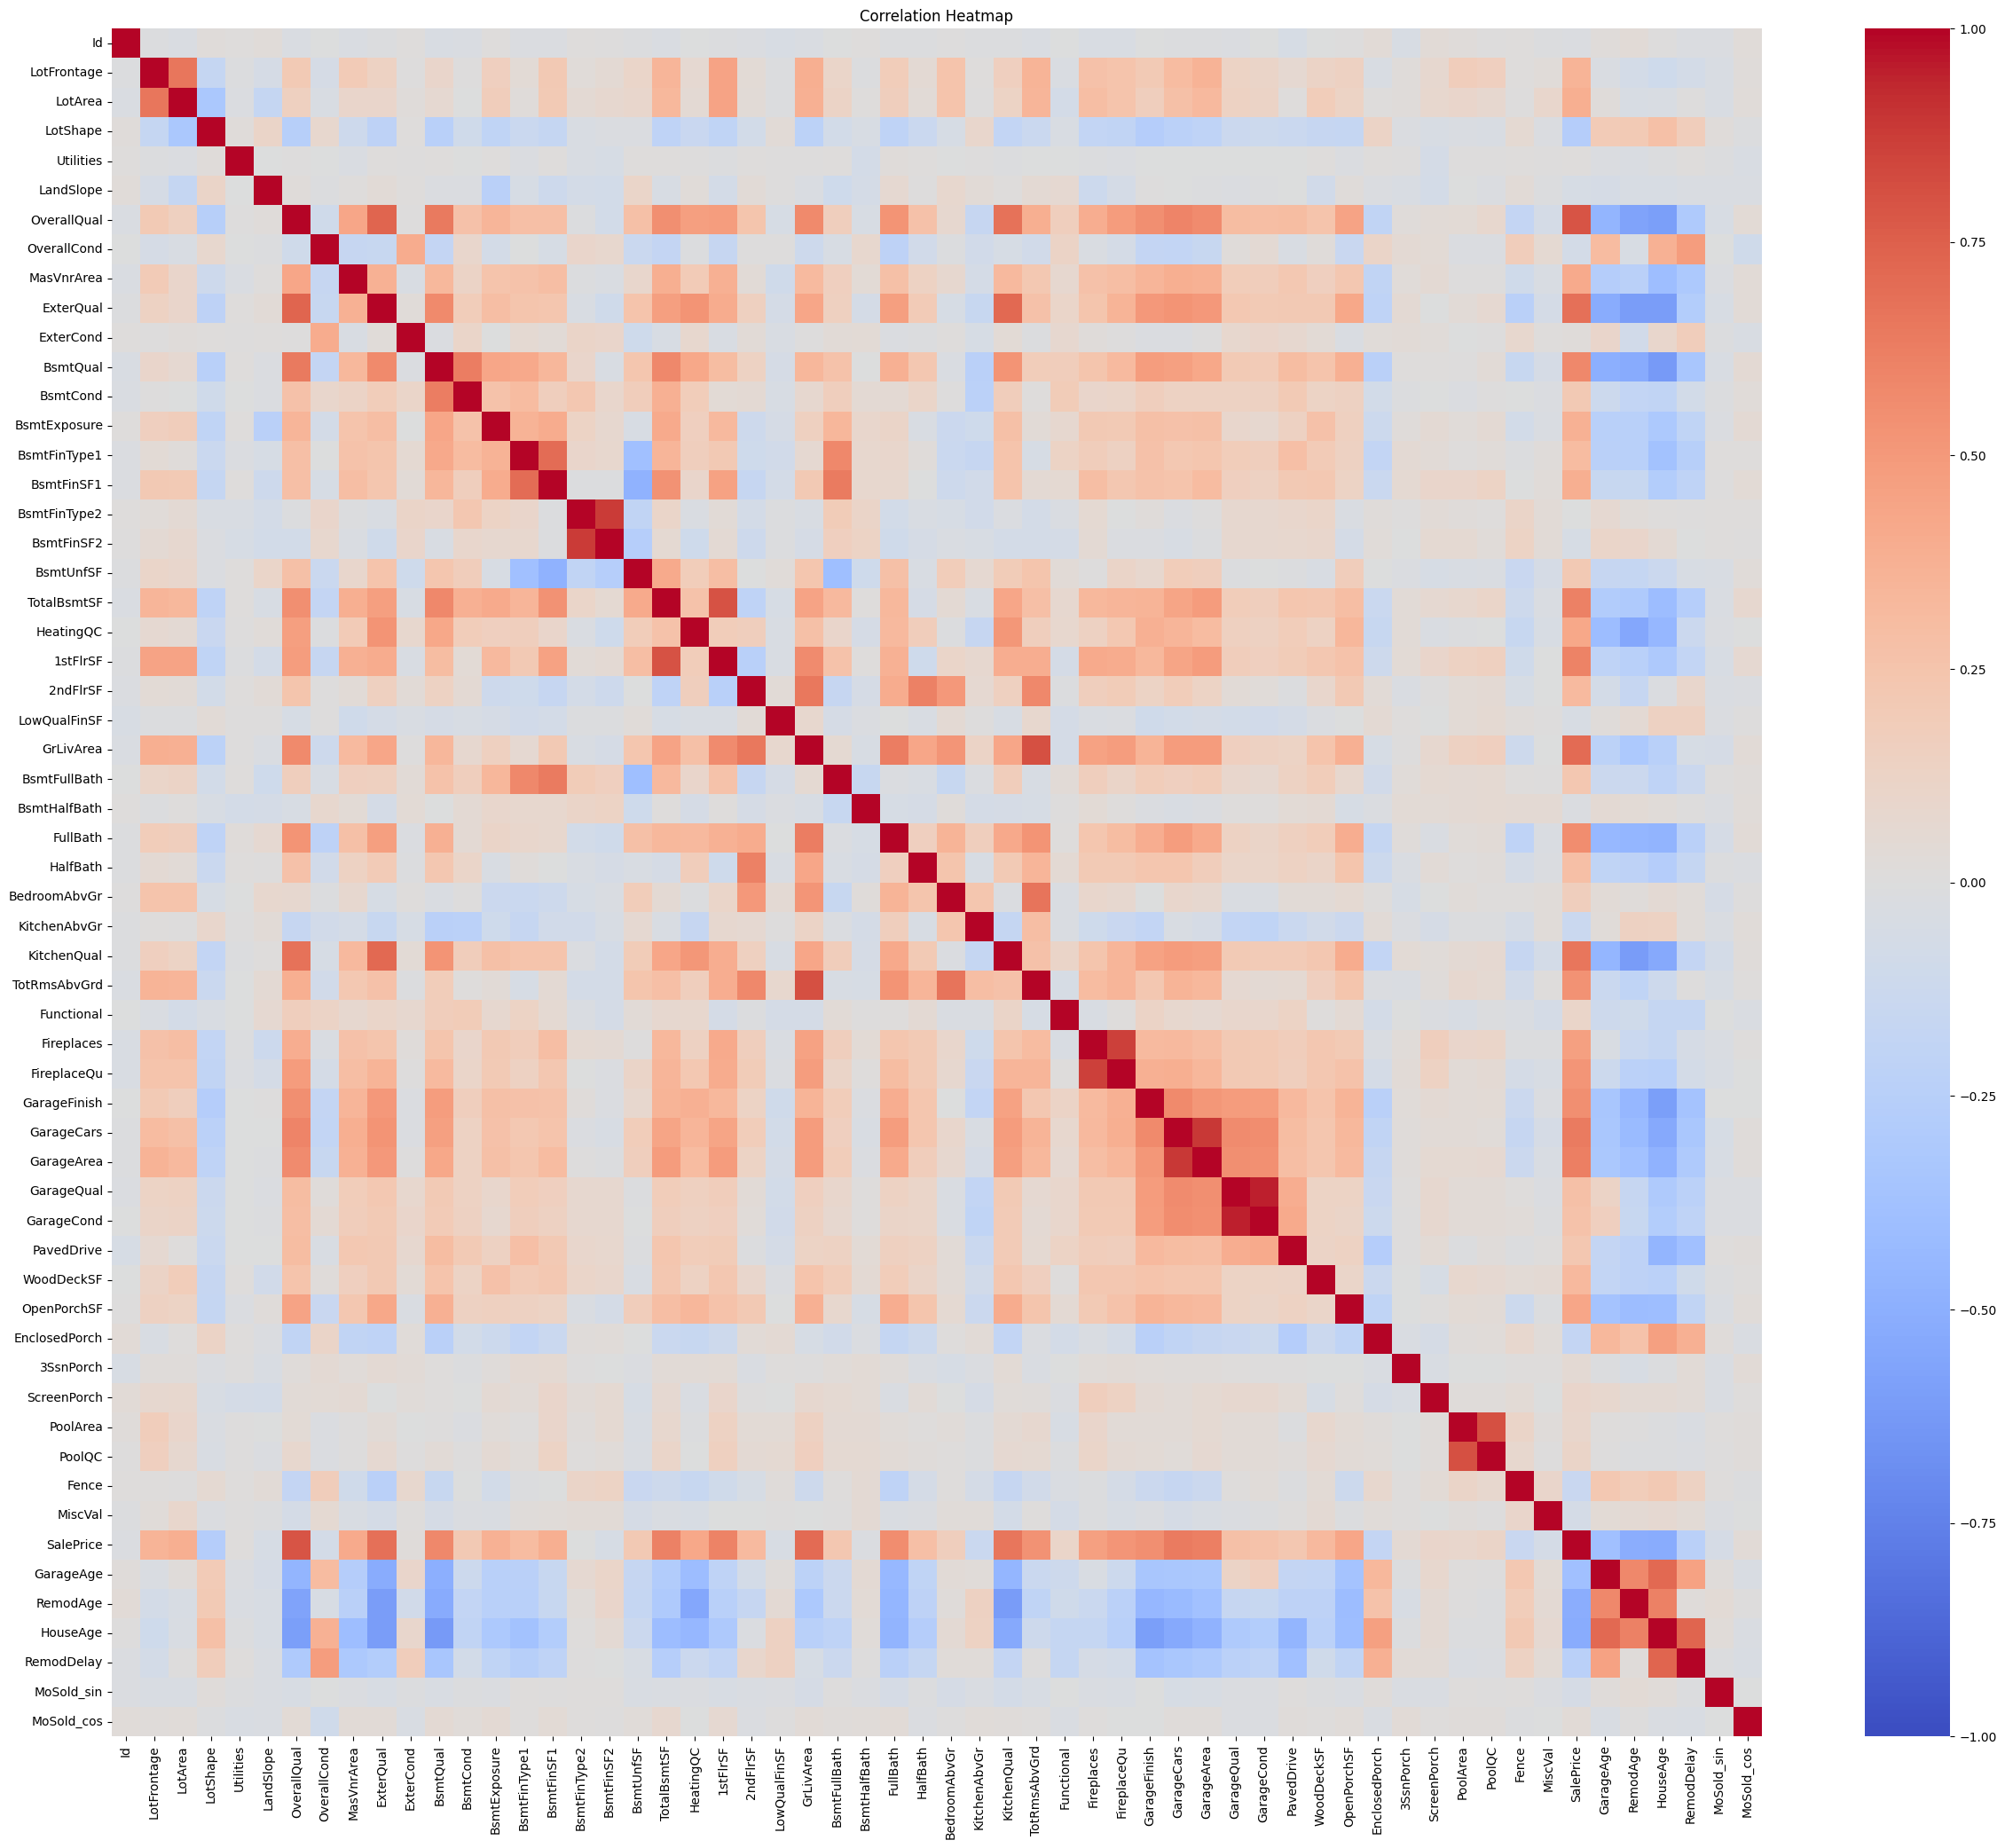

,Feature1,Feature2,corr
0,BsmtFinType2,BsmtFinSF2,0.904212
1,FireplaceQu,Fireplaces,0.903822
2,PoolQC,PoolArea,0.876900
3,GarageCars,GarageArea,0.864929
4,1stFlrSF,TotalBsmtSF,0.828737
...,...,...,...
1648,PoolArea,ExterCond,0.000350
1649,MoSold_sin,BsmtFullBath,0.000342
1650,OverallQual,Utilities,0.000315
1651,HalfBath,MoSold_sin,0.000058


In [ ]:
corr_matrix2p = merged_imputed_pro.corr(numeric_only=True)
plt.figure(figsize=(30, 25))
sns.heatmap(corr_matrix2p, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()
corr_series2p=corr_matrix2p.unstack()
corr_series2p=corr_series2[corr_series2p != 1]
corr_series_abs2p= abs(corr_series2p)
sorted_corr2p=corr_series2p.sort_values(ascending=False)
sorted_corr_abs2p=corr_series_abs2p.sort_values(ascending=False)
sorted_corr_abs2p.drop_duplicates(inplace=True)
sorted_corr_abs2p=sorted_corr_abs2p.reset_index()
sorted_corr_abs2p.columns=['Feature1','Feature2','corr']
sorted_corr_abs2p

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(sorted_corr_abs2p)

           Feature1       Feature2      corr
0      BsmtFinType2     BsmtFinSF2  0.904212
1       FireplaceQu     Fireplaces  0.903822
2            PoolQC       PoolArea  0.876900
3        GarageCars     GarageArea  0.864929
4          1stFlrSF    TotalBsmtSF  0.828737
5         SalePrice    OverallQual  0.809829
6      TotRmsAbvGrd      GrLivArea  0.808775
7        BsmtFinSF1   BsmtFinType1  0.800615
8          HouseAge       BsmtQual  0.785176
9        GarageCond     GarageQual  0.771897
10        SalePrice      GrLivArea  0.731310
11        GarageAge       HouseAge  0.730237
12      KitchenQual      ExterQual  0.724125
13      OverallQual      ExterQual  0.718028
14         RemodAge       HouseAge  0.715051
15       GarageCars      SalePrice  0.690711
16         HouseAge      ExterQual  0.685781
17        SalePrice      ExterQual  0.684014
18      OverallQual       BsmtQual  0.679900
19         BsmtQual      SalePrice  0.678026
20        SalePrice    KitchenQual  0.672849
21       B

In [ ]:
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')


In [ ]:
sale_corr=merged_imputed_pro.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False)
sale_corr

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
ExterQual,0.682639
KitchenQual,0.659600
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
BsmtQual,0.585207


In [ ]:
sale_corr_j = merged_imputed_pro.corr(numeric_only=True)['SalePrice']
sale_corr_signed_sorted = sale_corr_j.loc[sale_corr.abs().sort_values(ascending=False).index]
sale_corr_signed_sorted


,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
ExterQual,0.682639
KitchenQual,0.659600
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
BsmtQual,0.585207


In [ ]:
sale_list= sale_corr[sale_corr>=0.1].index.to_list()
sale_list

['SalePrice',
 'OverallQual',
 'GrLivArea',
 'ExterQual',
 'KitchenQual',
 'GarageCars',
 'GarageArea',
 'TotalBsmtSF',
 '1stFlrSF',
 'BsmtQual',
 'FullBath',
 'GarageFinish',
 'TotRmsAbvGrd',
 'HouseAge',
 'FireplaceQu',
 'RemodAge',
 'Fireplaces',
 'OpenPorchSF',
 'HeatingQC',
 'MasVnrArea',
 'GarageAge',
 'LotArea',
 'BsmtFinSF1',
 'BsmtExposure',
 'LotFrontage',
 'WoodDeckSF',
 '2ndFlrSF',
 'BsmtFinType1',
 'HalfBath',
 'GarageQual',
 'LotShape',
 'GarageCond',
 'RemodDelay',
 'PavedDrive',
 'BsmtFullBath',
 'BsmtUnfSF',
 'BsmtCond',
 'EnclosedPorch',
 'BedroomAbvGr',
 'Fence',
 'KitchenAbvGr',
 'PoolQC',
 'Functional']

In [ ]:
#onehot encoding  of nominal columns
merged_onehot=pd.get_dummies(merged_imputed_pro, columns=nominal_cols, drop_first=True, dtype=int)
merged_onehot

Id  LotFrontage   LotArea  LotShape  Utilities  LandSlope  \
train 0        1         65.0  9.042040         4          4          3   
      1        2         80.0  9.169623         4          4          3   
      2        3         68.0  9.328212         3          4          3   
      3        4         60.0  9.164401         3          4          3   
      4        5         84.0  9.565284         3          4          3   
...          ...          ...       ...       ...        ...        ...   
test  1454  2915         21.0  7.568896         4          4          3   
      1455  2916         21.0  7.546974         4          4          3   
      1456  2917        160.0  9.903538         4          4          3   
      1457  2918         62.0  9.253591         4          4          3   
      1458  2919         74.0  9.172431         4          4          2   

            OverallQual  OverallCond  MasVnrArea  ExterQual  ...  \
train 0               7            5    5.283204          4  ...   
      1               6            8    0.000000          3  ...   
      2               7            5    5.093750          4  ...   
      3               7            5    0.000000          3  ...   
      4               8            5    5.860786          4  ...   
...                 ...          ...         ...        ...  ...   
test  1454            4            7    0.000000          3  ...   
      1455            4            5    0.000000          3  ...   
      1456            5            7    0.000000          3  ...   
      1457            5            5    0.000000          3  ...   
      1458            7            5    4.553877          3  ...   

            SaleType_ConLI  SaleType_ConLw  SaleType_New  SaleType_Oth  \
train 0                  0               0             0             0   
      1                  0               0             0             0   
      2                  0               0             0             0   
      3                  0               0             0             0   
      4                  0               0             0             0   
...                    ...             ...           ...           ...   
test  1454               0               0             0             0   
      1455               0               0             0             0   
      1456               0               0             0             0   
      1457               0               0             0             0   
      1458               0               0             0             0   

            SaleType_WD  SaleCondition_AdjLand  SaleCondition_Alloca  \
train 0               1                      0                     0   
      1               1                      0                     0   
      2               1                      0                     0   
      3               1                      0                     0   
      4               1                      0                     0   
...                 ...                    ...                   ...   
test  1454            1                      0                     0   
      1455            1                      0                     0   
      1456            1                      0                     0   
      1457            1                      0                     0   
      1458            1                      0                     0   

            SaleCondition_Family  SaleCondition_Normal  SaleCondition_Partial  
train 0                        0                     1                      0  
      1                        0                     1                      0  
      2                        0                     1                      0  
      3                        0                     0                      0  
      4                        0                     1                      0  
...                          ...                   ...        

## Visualizing Relationships Between Features and SalePrice

To assess the relationships between numerical features and the target variable `SalePrice`, selected log-transformed features were **exponentiated back to their original scale**. This ensures that the visualizations reflect meaningful, interpretable values.

Using **Seaborn’s `FacetGrid`**, individual scatter plots were created for each feature against `SalePrice`, with regression lines overlaid. This approach allows for:

- **Quick visual assessment** of linear trends and relationships
- Identification of **strong predictors** for modeling
- Detection of potential **non-linear patterns** or outliers
- Better interpretability by displaying values on the original scale rather than log-transformed scale

These visualizations complement the correlation analysis and support informed feature selection for linear regression.


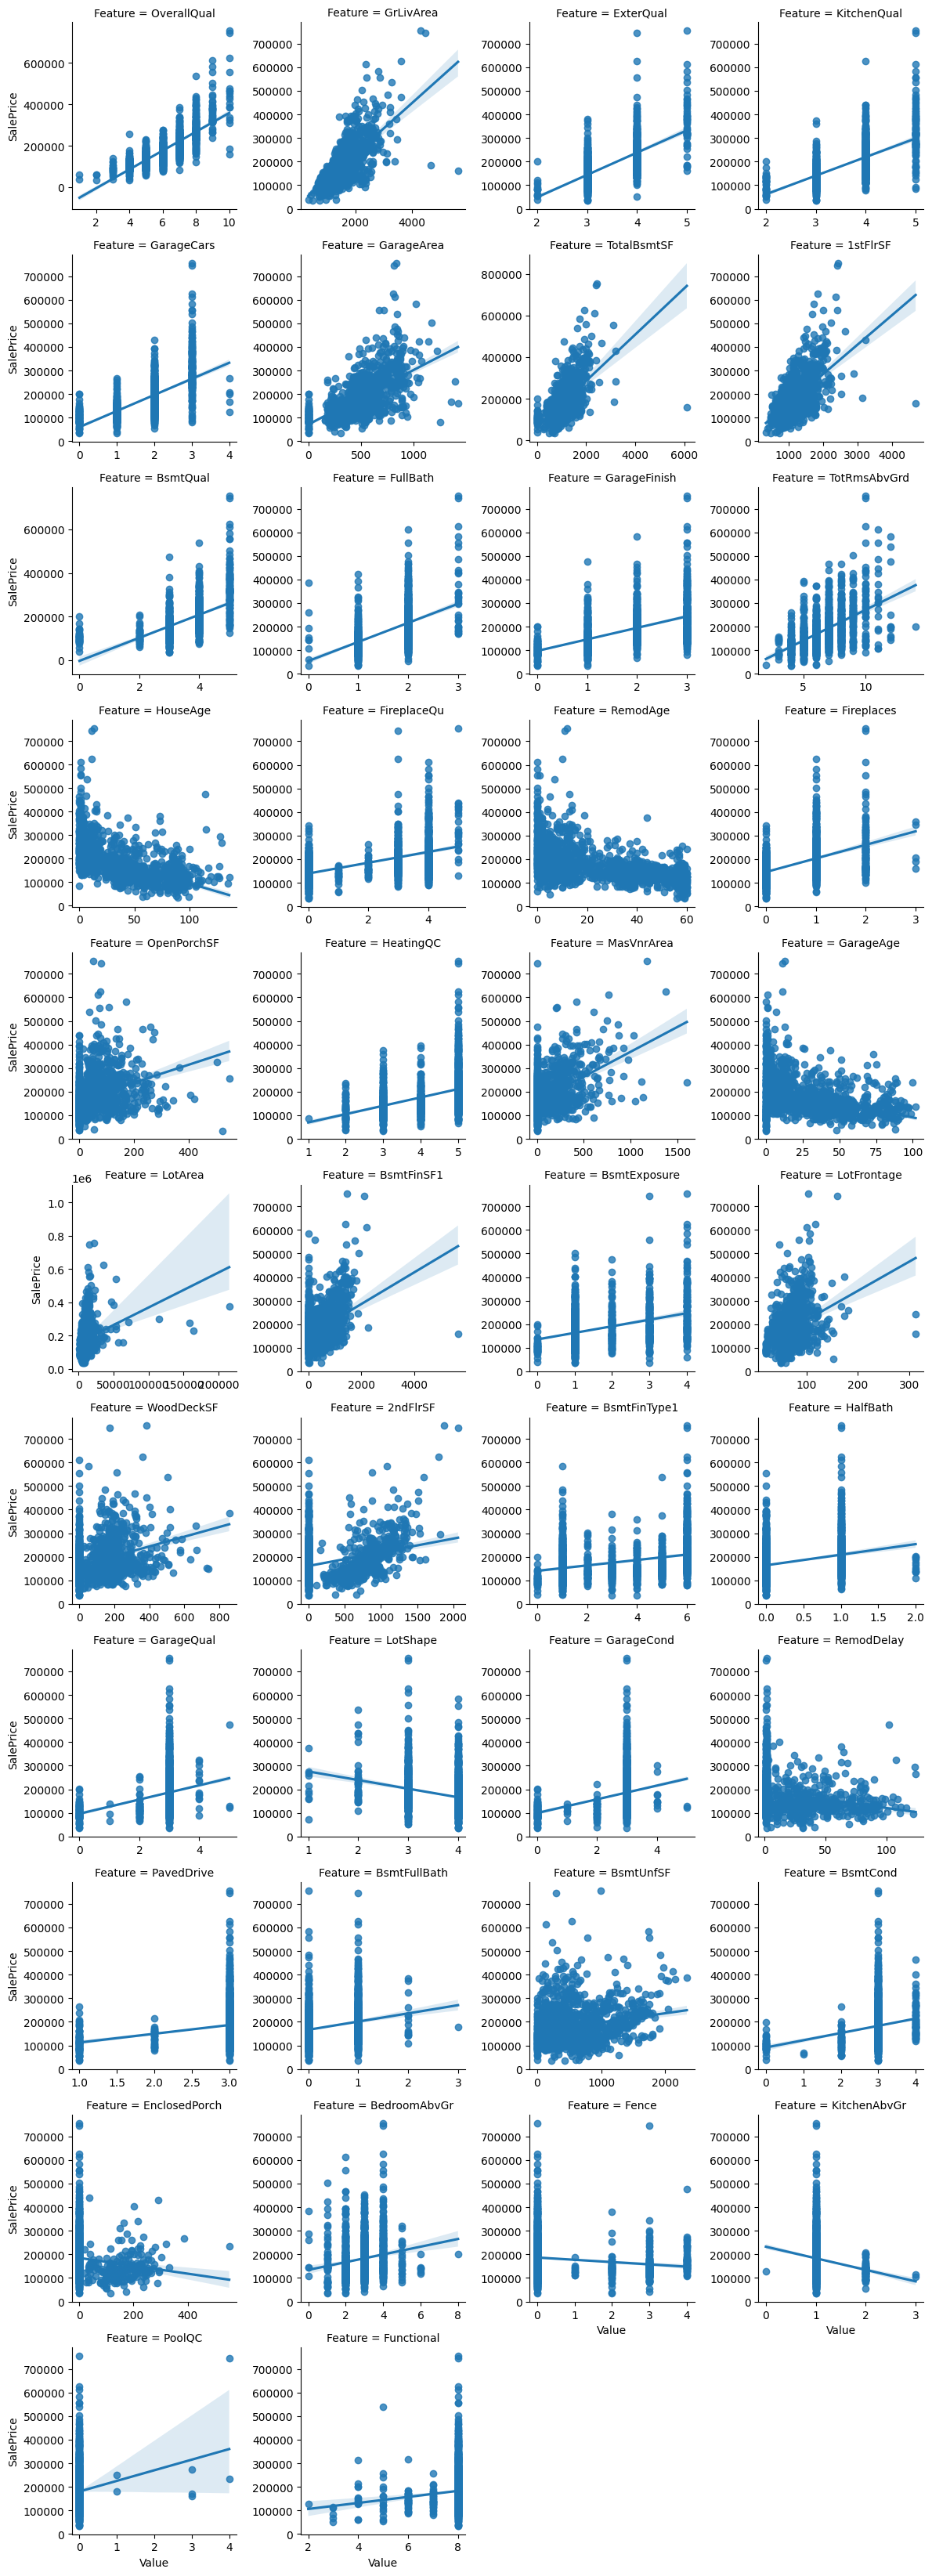

In [ ]:
to_log=['LotArea','MasVnrArea','BsmtFinSF2','LowQualFinSF','3SsnPorch','ScreenPorch','PoolArea','MiscVal','OpenPorchSF','EnclosedPorch','RemodDelay']
for col in to_log:
  merged_imputed_pro[col]=np.exp(merged_imputed_pro[col])
df_melted_for_plot = merged_imputed_pro.melt(id_vars='SalePrice', value_vars=sale_list, var_name='Feature', value_name='Value')

# Create the FacetGrid using the melted DataFrame
# Now 'Feature' column is used to define the grid columns
g = sns.FacetGrid(df_melted_for_plot, col='Feature', col_wrap=4, height=3, sharex=False, sharey=False)

# Map the scatter plot to the grid. The x-axis will be the 'Value' (the feature values)
# and the y-axis will be 'SalePrice'.
g.map(sns.regplot, 'Value', 'SalePrice')

plt.tight_layout()
plt.show()

#**Model development**

In [ ]:
train=merged_onehot.loc['train']
test=merged_onehot.loc['test']
train

,Id,LotFrontage,LotArea,LotShape,Utilities,LandSlope,OverallQual,OverallCond,MasVnrArea,ExterQual,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,65.0,9.042040,4,4,3,7,5,5.283204,4,...,0,0,0,0,1,0,0,0,1,0
1,2,80.0,9.169623,4,4,3,6,8,0.000000,3,...,0,0,0,0,1,0,0,0,1,0
2,3,68.0,9.328212,3,4,3,7,5,5.093750,4,...,0,0,0,0,1,0,0,0,1,0
3,4,60.0,9.164401,3,4,3,7,5,0.000000,3,...,0,0,0,0,1,0,0,0,0,0
4,5,84.0,9.565284,3,4,3,8,5,5.860786,4,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,62.0,8.976894,4,4,3,6,5,0.000000,3,...,0,0,0,0,1,0,0,0,1,0
1456,1457,85.0,9.486152,4,4,3,6,6,4.787492,3,...,0,0,0,0,1,0,0,0,1,0
1457,1458,66.0,9.109746,4,4,3,7,9,0.000000,5,...,0,0,0,0,1,0,0,0,1,0
1458,1459,68.0,9.181735,4,4,3,5,6,0.000000,3,...,0,0,0,0,1,0,0,0,1,0


<Axes: ylabel='SalePrice'>

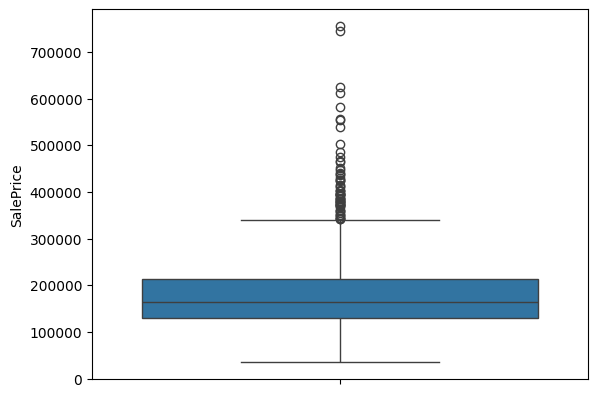

In [ ]:
sns.boxplot(data=train['SalePrice'])

7## Training and Evaluation of Regression Models

To predict house prices, four regression models—**Linear Regression, Ridge, Lasso, and ElasticNet**—were trained and evaluated using a consistent preprocessing and cross-validation pipeline. The workflow included:

1. **Data Preparation**
   - Features (`X`) and target (`y`) were defined, with `SalePrice` log-transformed to reduce skewness.
   - The dataset was split into training and testing sets (80/20 split) to evaluate model generalization.

2. **Pipeline Construction**
   - Each model was combined with a **StandardScaler** in a pipeline to ensure feature scaling.
   - This standardization ensures that coefficients are comparable and prevents features with larger scales from dominating the regression.

3. **Cross-Validation and Hyperparameter Tuning**
   - **K-Fold cross-validation (k=5)** was used to assess model performance consistently across folds.
   - Ridge, Lasso, and ElasticNet models underwent **hyperparameter tuning**:
     - Ridge: `alpha` optimized via `GridSearchCV`
     - Lasso and ElasticNet: `alpha` and `l1_ratio` optimized via `RandomizedSearchCV`
   - This ensures that each model is evaluated with its best parameters while avoiding overfitting.

4. **Performance Metrics**
   - For each model, the following were computed:
     - **Cross-validated R² (CV R²)**
     - **Cross-validated mean squared error (CV MSE)**
     - **Test R²**
     - **Test MSE**
     - **Mean Absolute Error (MAE)**
     - **Root Mean Squared Error (RMSE)**
   - These metrics allow comparison of predictive accuracy and error across models.

5. **Visualization**
   - For the ElasticNet model (best-performing regularized regression), predictions were exponentiated back to the original scale of `SalePrice`.
   - A scatter plot comparing **predicted vs. actual sale prices** was generated, with a reference line indicating perfect predictions.
   - This visualization aids in assessing the quality and bias of predictions.


🔹 Linear Regression:
CV R²: 0.8358143460138431
CV MSE: 0.025167345388564456
Validation R²: 0.7993475900878388
Validation MSE: 0.037444452158627184
MAE: 0.09316698025107806
RMSE: 0.1935056902487035

🔹 Ridge Regression:
Best alpha: 545.5594781168514
CV R²: 0.8694905725583025
CV MSE: 0.02021671084326933
Validation R²: 0.8832547152507262
Validation MSE: 0.021786248325914304
MAE: 0.09556277194622308
RMSE: 0.14760165421130722

🔹 Lasso Regression:
Best alpha: 0.00379269019073225
CV R²: 0.8634216567328619
CV MSE: 0.02121219866269882
Validation R²: 0.8950910032395369
Validation MSE: 0.01957743698132702
MAE: 0.08988523960487059
RMSE: 0.13991939458605093

🔹 ElasticNet Regression:
Best alpha: 0.004641588833612782
Best l1_ratio: 0.7000000000000001
CV R²: 0.8636602369492229
CV MSE: 0.02117133445859088
Validation R²: 0.8956033777605262
Validation MSE: 0.01948182096930463
MAE: 0.0892678252497067
RMSE: 0.13957729388874335


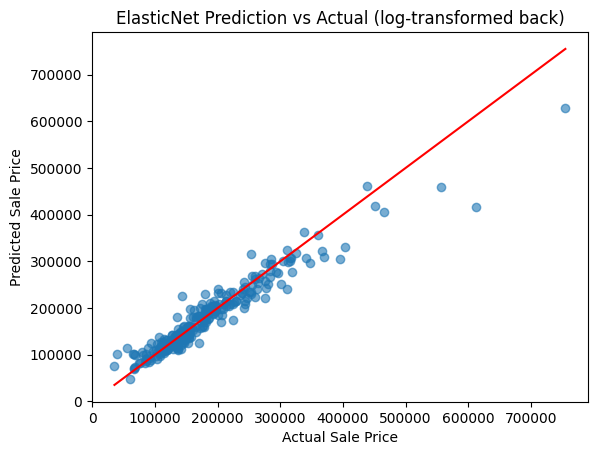

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare data
X = train.drop(columns=['SalePrice'])
y = np.log(train['SalePrice'])  # log transform to reduce skew

# Split data into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# --- Helper function to compute CV MSE ---
def get_cv_mse(model, X, y, cv):
    mse_scores = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error')
    return np.mean(mse_scores)

# --- 1. Linear Regression ---
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_val)

print("\n🔹 Linear Regression:")
print("CV R²:", np.mean(cross_val_score(pipeline_lr, X_train, y_train, cv=cv, scoring='r2')))
print("CV MSE:", get_cv_mse(pipeline_lr, X_train, y_train, cv))
print("Validation R²:", r2_score(y_val, y_pred_lr))
print("Validation MSE:", mean_squared_error(y_val, y_pred_lr))
print("MAE:", mean_absolute_error(y_val, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_lr)))

# --- 2. Ridge Regression ---
param_grid_ridge = {'model__alpha': np.logspace(-4, 4, 20)}
pipeline_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])
grid_ridge = GridSearchCV(pipeline_ridge, param_grid=param_grid_ridge, cv=cv, scoring='r2', n_jobs=-1)
grid_ridge.fit(X_train, y_train)
y_pred_ridge = grid_ridge.predict(X_val)

print("\n🔹 Ridge Regression:")
print("Best alpha:", grid_ridge.best_params_['model__alpha'])
print("CV R²:", grid_ridge.best_score_)
print("CV MSE:", get_cv_mse(grid_ridge.best_estimator_, X_train, y_train, cv))
print("Validation R²:", r2_score(y_val, y_pred_ridge))
print("Validation MSE:", mean_squared_error(y_val, y_pred_ridge))
print("MAE:", mean_absolute_error(y_val, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_ridge)))

# --- 3. Lasso Regression ---
param_dist_lasso = {'model__alpha': np.logspace(-4, 1, 20)}
pipeline_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(max_iter=10000))
])
lasso_search = RandomizedSearchCV(
    pipeline_lasso,
    param_distributions=param_dist_lasso,
    n_iter=20,
    cv=cv,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)
lasso_search.fit(X_train, y_train)
y_pred_lasso = lasso_search.predict(X_val)

print("\n🔹 Lasso Regression:")
print("Best alpha:", lasso_search.best_params_['model__alpha'])
print("CV R²:", lasso_search.best_score_)
print("CV MSE:", get_cv_mse(lasso_search.best_estimator_, X_train, y_train, cv))
print("Validation R²:", r2_score(y_val, y_pred_lasso))
print("Validation MSE:", mean_squared_error(y_val, y_pred_lasso))
print("MAE:", mean_absolute_error(y_val, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_lasso)))

# --- 4. ElasticNet Regression ---
param_dist_elastic = {
    'model__alpha': np.logspace(-4, 1, 10),
    'model__l1_ratio': np.linspace(0.1, 0.9, 9)
}
pipeline_elastic = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet(max_iter=10000))
])
elastic_search = RandomizedSearchCV(
    pipeline_elastic,
    param_distributions=param_dist_elastic,
    n_iter=30,
    cv=cv,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)
elastic_search.fit(X_train, y_train)
y_pred_elastic = elastic_search.predict(X_val)

print("\n🔹 ElasticNet Regression:")
print("Best alpha:", elastic_search.best_params_['model__alpha'])
print("Best l1_ratio:", elastic_search.best_params_['model__l1_ratio'])
print("CV R²:", elastic_search.best_score_)
print("CV MSE:", get_cv_mse(elastic_search.best_estimator_, X_train, y_train, cv))
print("Validation R²:", r2_score(y_val, y_pred_elastic))
print("Validation MSE:", mean_squared_error(y_val, y_pred_elastic))
print("MAE:", mean_absolute_error(y_val, y_pred_elastic))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_elastic)))

# Optional: Visualize best model predictions
plt.scatter(np.exp(y_val), np.exp(y_pred_elastic), alpha=0.6)
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("ElasticNet Prediction vs Actual (log-transformed back)")
plt.plot([min(np.exp(y_val)), max(np.exp(y_val))], [min(np.exp(y_val)), max(np.exp(y_val))], color='red')
plt.show()

## Evaluating Linear Regression with PCA-Based Dimensionality Reduction

To assess the impact of dimensionality reduction on model performance, Linear Regression was evaluated in combination with **Principal Component Analysis (PCA)** under two variance retention settings: 95% and 90%.

### Procedure
1. **Iteration over PCA Settings**
   - A loop was used to evaluate both PCA configurations within a single workflow.
   - Each iteration retained either **95% or 90% of the variance**, automatically selecting the appropriate number of principal components.

2. **Pipeline Construction**
   - For each setting, a pipeline was created that:
     - **Standardizes features** using `StandardScaler`
     - **Applies PCA** with the specified variance threshold
     - **Fits a Linear Regression model** on the transformed features

3. **Model Evaluation**
   - For each PCA configuration, the following metrics were computed:
     - **Test-set R²**: goodness of fit on unseen data
     - **Mean Absolute Error (MAE)**
     - **Root Mean Squared Error (RMSE)**
     - **Cross-validated R²** using K-Fold CV
     - **Number of principal components** selected by PCA
   - This allows for a **side-by-side comparison** of performance versus dimensionality reduction.

### Purpose
- Evaluate whether reducing feature dimensionality improves or degrades predictive performance
- Identify an optimal trade-off between **model simplicity** and **accuracy**
- Facilitate interpretation of high-dimensional data by reducing multicollinearity and noise while preserving most of the variance


In [ ]:
from sklearn.decomposition import PCA

for variance in (0.95, 0.90):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=variance)),
        ('lr', LinearRegression())
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)

    val_r2   = r2_score(y_val, y_pred)
    val_mae  = mean_absolute_error(y_val, y_pred)
    val_rmse = mean_squared_error(y_val, y_pred)
    cv_r2    = cross_val_score(pipeline, X, y, cv=5, scoring='r2').mean()
    n_comp   = pipeline.named_steps['pca'].n_components_

    print(f"\n🔹 PCA + Linear (retain {int(variance*100)}% variance):")
    print(f"R² Score (Validation): {val_r2:.6f}")
    print(f"MAE:                   {val_mae:.6f}")
    print(f"RMSE:                  {val_rmse:.6f}")
    print(f"CV R² mean:            {cv_r2:.6f}")
    print(f"Components:            {n_comp}")



🔹 PCA + Linear (retain 95% variance):
R² Score (Validation): 0.873296
MAE:                   0.101253
RMSE:                  0.023645
CV R² mean:            0.861228
Components:            134

🔹 PCA + Linear (retain 90% variance):
R² Score (Validation): 0.871652
MAE:                   0.101058
RMSE:                  0.023952
CV R² mean:            0.860042
Components:            113


## Lasso and Ridge Regression with PCA

To combine **regularization** and **dimensionality reduction**, both Lasso and Ridge regression models were applied after performing **Principal Component Analysis (PCA)**, retaining 90% of the variance.

### Procedure
1. **Dimensionality Reduction**
   - PCA was applied to reduce feature dimensionality while preserving 90% of the original variance.
   - This step helps mitigate multicollinearity and simplifies the model by focusing on the most informative components.

2. **Regularized Regression**
   - Both **Lasso** and **Ridge** regression were fitted on the PCA-transformed features.
   - **RandomizedSearchCV** was used to optimize the regularization strength (`alpha`) for each model, improving predictive performance and controlling overfitting.

3. **Performance Evaluation**
   - Models were evaluated on the test set and training set using:
     - **R² score**: proportion of variance explained
     - **Mean Absolute Error (MAE)**
     - **Root Mean Squared Error (RMSE)**
     - **Cross-validated R²** on training data
   - These metrics provide a comprehensive assessment of model fit, accuracy, and generalization.

### Purpose
- Leverage PCA to reduce dimensionality while retaining key variance  
- Apply regularization to prevent overfitting and improve model robustness  
- Assess whether combining PCA with Lasso or Ridge improves prediction accuracy compared to standard regression


In [ ]:
# --- PCA + Lasso ---
pipeline_lasso_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90)),  # retain 90% variance
    ('lasso', Lasso(max_iter=10000))
])

# Hyperparameter tuning
param_dist_lasso = {'lasso__alpha': np.logspace(-4, 1, 30)}
search_lasso_pca = RandomizedSearchCV(
    pipeline_lasso_pca,
    param_distributions=param_dist_lasso,
    cv=5,
    scoring='r2',
    n_iter=30,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search_lasso_pca.fit(X_train, y_train)
y_pred_lasso_pca = search_lasso_pca.predict(X_val)

print("🔹 PCA + Lasso:")
print("Best alpha:", search_lasso_pca.best_params_['lasso__alpha'])
print("R² Score (Validation):", r2_score(y_val, y_pred_lasso_pca))
print("MAE:", mean_absolute_error(y_val, y_pred_lasso_pca))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_lasso_pca)))
print("Cross-validated R² mean:", np.mean(cross_val_score(search_lasso_pca.best_estimator_, X_train, y_train, cv=5)))

# --- PCA + Ridge ---
pipeline_ridge_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90)),  # retain 90% variance
    ('ridge', Ridge())
])

param_dist_ridge = {'ridge__alpha': np.logspace(-4, 4, 30)}
search_ridge_pca = RandomizedSearchCV(
    pipeline_ridge_pca,
    param_distributions=param_dist_ridge,
    cv=5,
    scoring='r2',
    n_iter=30,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search_ridge_pca.fit(X_train, y_train)
y_pred_ridge_pca = search_ridge_pca.predict(X_val)

print("\n🔹 PCA + Ridge:")
print("Best alpha:", search_ridge_pca.best_params_['ridge__alpha'])
print("R² Score (Validation):", r2_score(y_val, y_pred_ridge_pca))
print("MAE:", mean_absolute_error(y_val, y_pred_ridge_pca))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_ridge_pca)))
print("Cross-validated R² mean:", np.mean(cross_val_score(search_ridge_pca.best_estimator_, X_train, y_train, cv=5)))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
🔹 PCA + Lasso:
Best alpha: 0.005298316906283713
R² Score (Validation): 0.878753316000155
MAE: 0.09883411662090526
RMSE: 0.1504203120496092
Cross-validated R² mean: 0.8552435728429162
Fitting 5 folds for each of 30 candidates, totalling 150 fits

🔹 PCA + Ridge:
Best alpha: 417.53189365604004
R² Score (Validation): 0.8735012998251968
MAE: 0.09988665126969677
RMSE: 0.1536436379854553
Cross-validated R² mean: 0.8538803736914579


based on there score we ideftify the best model which to predicit


| **Model**          | **CV R²** | **Validation R²** | **MAE** | **RMSE** | **Notes**                                  |
| ------------------ | --------- | ----------- | ------- | -------- | ------------------------------------------ |
| Linear Regression  | 0.8358    | 0.7993      | 0.0932  | 0.1935   | No regularization                          |
| Ridge              | 0.8695    | 0.8833      | 0.0956  | 0.1476   | L2 regularization                          |
| Lasso              | 0.8634    | 0.8951      | 0.0899  | 0.1399   | L1 regularization                          |
| ElasticNet         | 0.8636    | 0.8956      | 0.0893  | 0.1396   | L1 + L2 regularization                     |
| PCA + Linear (90%) | 0.8600    | 0.8717      | 0.1011  | 0.1548   | PCA retained 90% variance (113 components) |
| PCA + Linear (95%) | 0.8612    | 0.8733      | 0.1013  | 0.1538   | PCA retained 95% variance (134 components) |
| PCA + Lasso        | 0.8552    | 0.8788      | 0.0988  | 0.1504   | PCA + L1                                   |
| PCA + Ridge        | 0.8539    | 0.8735      | 0.0999  | 0.1536   | PCA + L2                                   |


## Feature Importance from the Best Lasso Regression Model

To understand which features most strongly influence house prices, the coefficients of the **best-performing Lasso regression model** were extracted and analyzed.

### Procedure
1. **Coefficient Extraction**
   - All feature coefficients from the Lasso model were retrieved.
   - Features with **non-zero coefficients** were considered retained, while those penalized to zero were considered excluded by the regularization process.

2. **Identifying Top Features**
   - The top 30 features were selected based on the **absolute value of their coefficients**, representing the most influential predictors of house price.

3. **Visualization and Reporting**
   - A **printed table** displays the retained features with their corresponding coefficient values.
   - A **horizontal bar plot** visualizes the relative magnitude of the top 30 coefficients, making it easy to interpret which features have the greatest impact.

### Purpose
- Identify key predictors of house price while eliminating irrelevant features  
- Highlight the **sparsity-inducing effect of Lasso regularization**  
- Provide interpretability for feature contributions in the regression model



✅ Lasso kept 88 features and penalized 130 to zero.

🔝 Top 30 Important Features (Lasso):
                   Feature  Coefficient
24               GrLivArea     0.095820
6              OverallQual     0.081294
37              GarageCars     0.040378
2                  LotArea     0.040280
7              OverallCond     0.030012
53                HouseAge    -0.029533
121        Condition2_PosN    -0.022297
101   Neighborhood_NridgHt     0.022242
11                BsmtQual     0.021057
25            BsmtFullBath     0.019871
14            BsmtFinType1     0.018391
91    Neighborhood_Crawfor     0.017507
57           MSSubClass_30    -0.016714
27                FullBath     0.016278
33              Functional     0.016194
35             FireplaceQu     0.015684
150    Exterior1st_BrkFace     0.015646
107   Neighborhood_StoneBr     0.015474
190           CentralAir_Y     0.014830
52                RemodAge    -0.014450
13            BsmtExposure     0.013846
106   Neighborhood_Somerst   

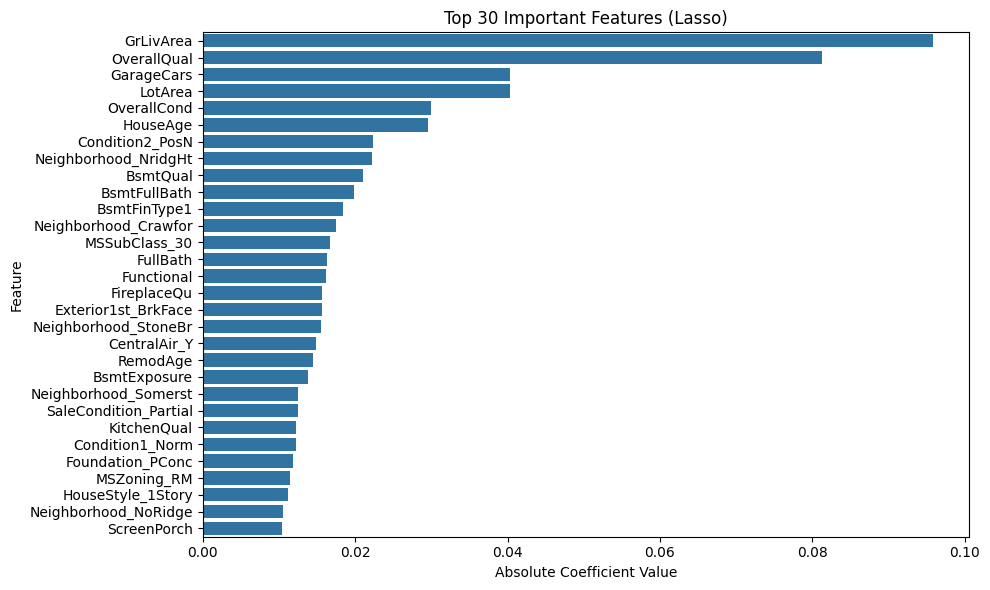

In [ ]:
# Get model
best_lasso = lasso_search.best_estimator_

# Coefficients and feature names
coefficients = best_lasso.named_steps['model'].coef_
features = X_train.columns

# Build DataFrame
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

# Separate into used vs. penalized
used_features = coef_df[coef_df['Coefficient'] != 0]
penalized_features = coef_df[coef_df['Coefficient'] == 0]

print(f"\n✅ Lasso kept {len(used_features)} features and penalized {len(penalized_features)} to zero.")

# Display top 30 by absolute weight
top_features = used_features.sort_values(by='Abs_Coefficient', ascending=False).head(30)

print("\n🔝 Top 30 Important Features (Lasso):")
print(top_features[['Feature', 'Coefficient']])

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x='Abs_Coefficient', y='Feature')
plt.title('Top 30 Important Features (Lasso)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()



## Predicting Sale Prices on Unlabeled Test Data

After evaluating multiple regression models, **Lasso** and **ElasticNet** were identified as the best-performing models based on cross-validated R² and test-set metrics. These models were then used to generate predictions on a **separate test dataset** that does not contain any `SalePrice` values.

### Procedure
1. **Lasso Predictions**
   - The **best Lasso estimator** from hyperparameter tuning was applied to the unlabeled test set.
   - Predicted values represent the estimated sale prices for each property.

2. **ElasticNet Predictions**
   - Similarly, the **best ElasticNet estimator** was applied to the same test set.
   - This provides an alternative set of predicted sale prices using a different regularization approach.

### Purpose
- Generate sale price predictions for properties where the true values are unknown
- Leverage the **most accurate models** from prior evaluation (Lasso and ElasticNet)
- Provide reliable, data-driven estimates suitable for downstream analysis or submission in predictive modeling tasks


In [ ]:
X=test.drop(columns=['SalePrice'])
# Predict log(SalePrice)
log_preds = best_lasso.predict(X)

# Convert from log to original SalePrice
final_preds_lasso = np.exp(log_preds)

# Create submission DataFrame
submission_lasso = test.copy()
submission_lasso['SalePrice'] = final_preds_lasso

submission_lasso['SalePrice']
submission_lasso=submission_lasso['SalePrice']
submission_lasso.index=test['Id']
submission_lasso

,SalePrice
Id,
1461,118722.588499
1462,153908.675128
1463,175172.297106
1464,193058.219672
1465,210749.076645
...,...
2915,83588.808226
2916,80733.390437
2917,161306.658198


In [ ]:
# Predict log(SalePrice) using the best fitted ElasticNet pipeline from the search
best_elastic=elastic_search.best_estimator_
log_preds = best_elastic.predict(X)

# Convert from log to original SalePrice
final_preds_elastic = np.exp(log_preds)

# Create submission DataFrame
submission_elastic = test.copy()
submission_elastic['SalePrice'] = final_preds_elastic

submission_elastic=submission_elastic['SalePrice']
submission_elastic.index=test['Id']
submission_elastic


,SalePrice
Id,
1461,118928.053322
1462,154438.281864
1463,175212.632323
1464,192993.727045
1465,210613.069362
...,...
2915,83113.962548
2916,79672.270446
2917,159652.825445


## Dual Feature Comparison: Pearson Correlation vs. Lasso Coefficients

This section provides a **side-by-side analysis** of feature importance by comparing:

1. **Pearson correlation** of each feature with the target variable (`SalePrice`)
2. **Lasso regression coefficients** from the best-performing Lasso model

### Rationale
- **Pearson correlation** measures the linear association between individual features and the target, helping to identify statistically significant relationships.
- **Lasso coefficients** indicate which features are predictive in the context of a multivariate regression model, taking into account interactions and regularization.
- Log-transformed `SalePrice` ensures that the assumptions of linearity and normality are approximately satisfied, making the Pearson correlation reliable.

### Purpose
- Highlight features that are both **strongly correlated** with `SalePrice` and **selected by Lasso** as important predictors.
- Identify potential **redundant or less influential features**.
- Provide actionable insights for **model interpretation and feature selection**, improving the reliability of regression-based predictions.

This dual comparison facilitates a **holistic understanding** of feature relevance from both a statistical and predictive modeling perspective.


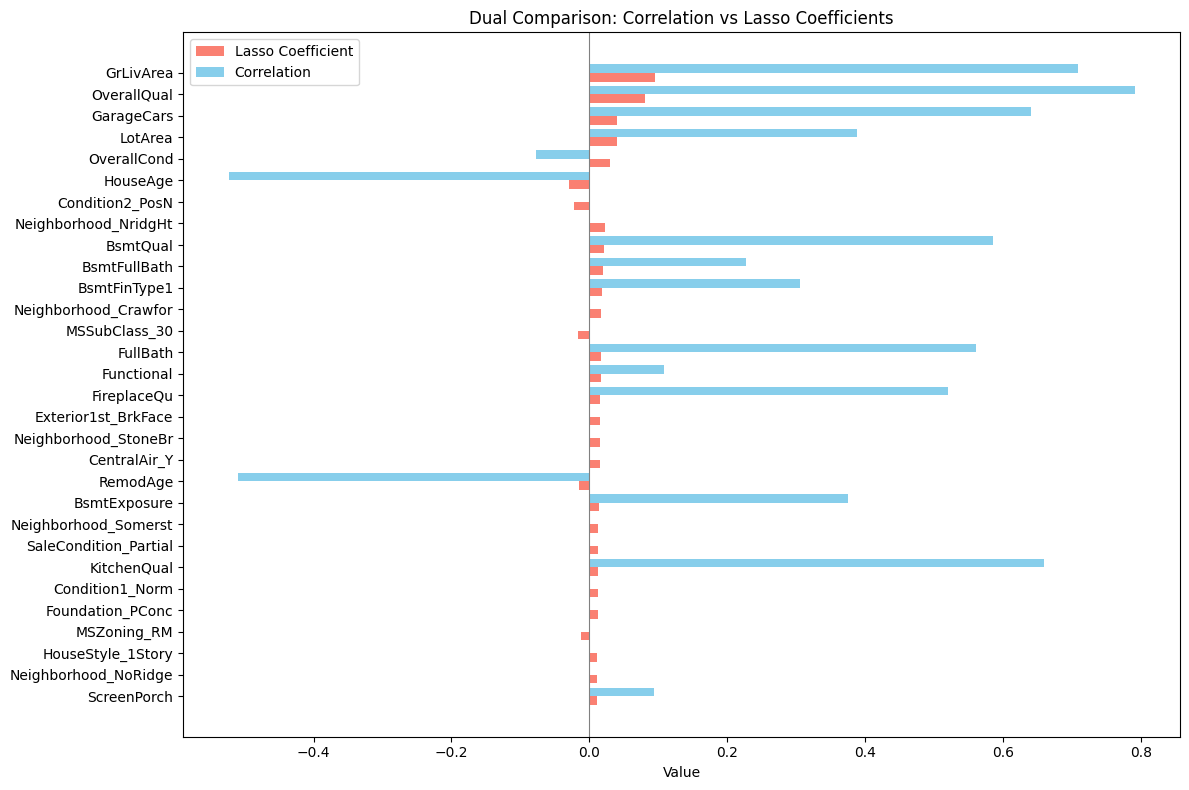

In [ ]:
# sale_corr_signed_sorted: a Series with feature names as index and correlations as values
# top_features: a DataFrame with 'Feature' and 'Coefficient' columns from Lasso

# Step 1: Create DataFrame from correlation series
corr_df = sale_corr_signed_sorted.rename("Correlation").reset_index().rename(columns={"index": "Feature"})

# Step 2: Merge with Lasso coefficients
dual_df = pd.merge(top_features, corr_df, on="Feature", how="left")

# Step 3: Sort by absolute Lasso Coefficient (optional for visual clarity)
dual_df = dual_df.sort_values(by="Abs_Coefficient", ascending=False)

# Step 4: Plotting
plt.figure(figsize=(12, 8))
bar_width = 0.4
index = range(len(dual_df))

plt.barh([i + bar_width for i in index], dual_df['Coefficient'], height=bar_width, label='Lasso Coefficient', color='salmon')
plt.barh(index, dual_df['Correlation'], height=bar_width, label='Correlation', color='skyblue')

plt.yticks([i + bar_width / 2 for i in index], dual_df['Feature'])
plt.xlabel('Value')
plt.title('Dual Comparison: Correlation vs Lasso Coefficients')
plt.axvline(0, color='gray', linewidth=0.8)
plt.legend()
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()


## Random Forest Regression for House Price Prediction

As an alternative to linear models, a **Random Forest Regressor** was applied to explore whether non-linear relationships can improve prediction accuracy. Model performance was evaluated using **R², MAE, and RMSE** on the test set and compared against the linear and regularized regression models.


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor()
rf.fit(X_train, y_train)
rf.score(X_val, y_val)


0.8829188898676039

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define the model
rf = RandomForestRegressor(random_state=42)

# Define the parameter distributions for random search
param_dist_rf = {
    'n_estimators': randint(100, 301),          # between 100 and 300
    'max_features': randint(10, 101),           # between 10 and 100
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 11),        # between 2 and 10
    'min_samples_leaf': randint(1, 5)           # between 1 and 4
}

# Set up Randomized Search
random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=50,              # number of parameter settings sampled
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)

# Fit the model
random_search_rf.fit(X_train, y_train)




RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7eae0fa8b3e0>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7eae06fa8a40>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7eae06fa8500>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7eae0f897980>},
                   random_state=42, return_train_score=True, scoring='r2')

By hyperparameter tunning we have got a better r squared score even rom lassso by random forest

In [ ]:
# Print results
print("Best parameters:", random_search_rf.best_params_)
print("Best R^2 score:", random_search_rf.best_score_)
print("val R^2 score:", random_search_rf.score(X_val, y_val))
print("Best Cross-Validated MSE:",get_cv_mse(random_search_rf.best_estimator_, X_train, y_train, cv))


Best parameters: {'max_depth': None, 'max_features': 71, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 220}
Best R^2 score: 0.8724088587593879
val R^2 score: 0.8868943040659201
Best Cross-Validated MSE: 0.0198680417445851



🔝 Top 30 Important Features (Random Forest):
OverallQual          0.232600
GrLivArea            0.127510
ExterQual            0.076685
HouseAge             0.069474
GarageCars           0.046296
GarageArea           0.039710
TotalBsmtSF          0.035257
KitchenQual          0.033840
1stFlrSF             0.032293
BsmtQual             0.021351
LotArea              0.019955
FullBath             0.019670
GarageFinish         0.017848
BsmtFinSF1           0.017705
FireplaceQu          0.014769
2ndFlrSF             0.013859
Fireplaces           0.013196
RemodAge             0.013035
LotFrontage          0.010908
CentralAir_Y         0.010861
OverallCond          0.007571
TotRmsAbvGrd         0.006266
OpenPorchSF          0.005860
BsmtUnfSF            0.005168
GarageCond           0.005105
GarageAge            0.004302
Id                   0.004025
GarageType_Attchd    0.003845
BsmtFinType1         0.003825
MasVnrArea           0.003643
dtype: float64


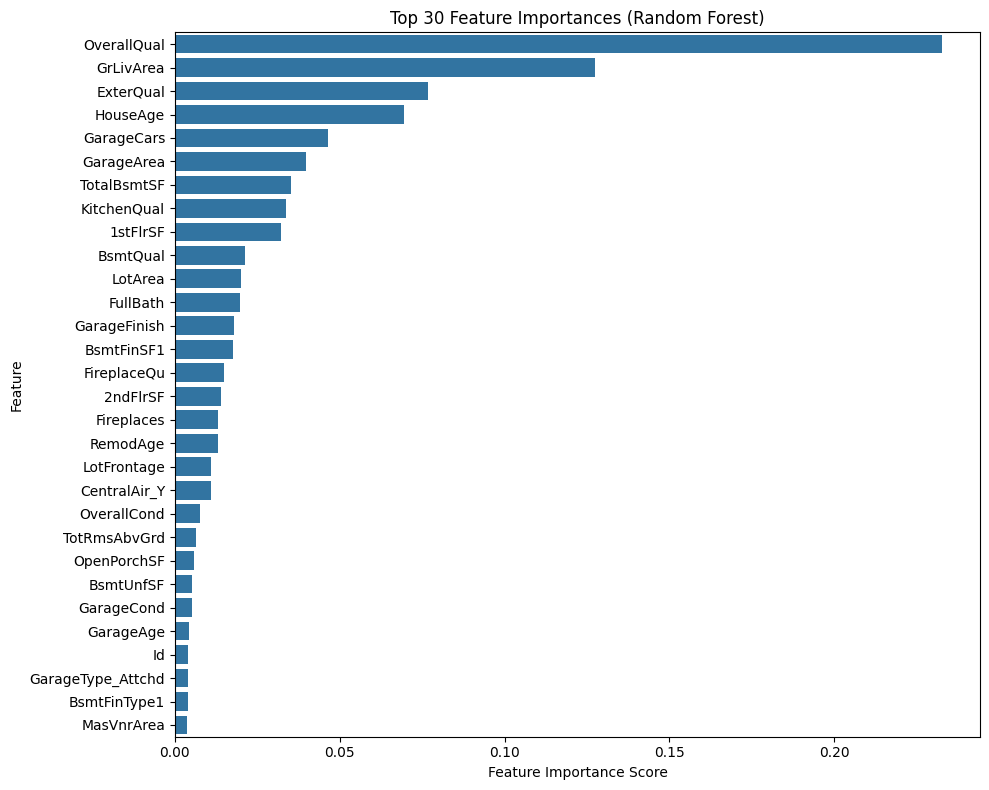

In [ ]:
# Access the best fitted Random Forest model from the Grid Search object
best_rf_model = random_search_rf.best_estimator_

# Get feature importances from the best fitted model
# Ensure X_train.columns is available, which it should be from previous cells
importances = best_rf_model.feature_importances_

# Create a pandas Series
feature_importances = pd.Series(importances, index=X_train.columns)

# Sort the features by importance in descending order
sorted_feature_importances = feature_importances.sort_values(ascending=False)

# Select the top 30 features
top_30_features = sorted_feature_importances.head(30)

print("\n🔝 Top 30 Important Features (Random Forest):")
print(top_30_features)

# Plot the top 30 feature importances
plt.figure(figsize=(10, 8)) # Adjust figure size as needed
sns.barplot(x=top_30_features.values, y=top_30_features.index)
plt.title('Top 30 Feature Importances (Random Forest)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

In [ ]:
log_preds = best_rf_model.predict(X)

# Convert from log to original SalePrice
final_preds_rf= np.exp(log_preds)

# Create submission DataFrame
submission_rf = test.copy()
submission_rf['SalePrice'] = final_preds_rf

submission_rf=submission_rf['SalePrice']
submission_rf.index=test['Id']
submission_rf

,SalePrice
Id,
1461,123943.922996
1462,151901.697952
1463,181712.629391
1464,183343.240137
1465,203676.540799
...,...
2915,87070.048259
2916,91048.056279
2917,160688.373269


In [ ]:
from google.colab import files
submission_rf.to_csv('submission_rf.csv', index=False)
submission_lasso.to_csv('submission_lasso.csv', index=False)
submission_elastic.to_csv('submission_elastic.csv', index=False)
files.download('submission_rf.csv')
files.download('submission_lasso.csv')
files.download('submission_elastic.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Machine Learning Alternative: XGBoost Regression

To further evaluate predictive performance, **XGBoost Regressor** was applied to the dataset. Its results were assessed using **R², MAE, and RMSE** on the test set, allowing comparison with previous models like Lasso, ElasticNet, and Random Forest.



In [ ]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 1.3 MB/s eta 0:00:00


In [ ]:
import xgboost as xgb
xmodel=xgb.XGBRegressor()
xmodel.fit(X_train, y_train)
xmodel.score(X_val, y_val)

0.8901479490394667

In [ ]:

from scipy.stats import uniform, randint
xmodel=xgb.XGBRegressor(random_state=42, objective='reg:squarederror')

# Define hyperparameter distribution
param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0, 5)
}

# Set up RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    estimator=xmodel,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)

# Fit model
random_search_xgb.fit(X_train, y_train)
print("Best parameters:", random_search_xgb.best_params_)
print("Best CV R^2 score:", random_search_xgb.best_score_)
print("val R^2 score:", random_search_xgb.score(X_val, y_val))
print("Best Cross-Validated MSE:",get_cv_mse(random_search_xgb.best_estimator_, X_train, y_train, cv))


Best parameters: {'colsample_bytree': np.float64(0.5035331526098588), 'gamma': np.float64(0.11531212520707879), 'learning_rate': np.float64(0.16743239807751675), 'max_depth': 9, 'min_child_weight': 3, 'n_estimators': 157, 'subsample': np.float64(0.7571172192068059)}
Best CV R^2 score: 0.876935262383602
val R^2 score: 0.8932974462492346
Best Cross-Validated MSE: 0.019717907628439935



🔝 Top 30 Important Features (XGBoost):
OverallQual             0.143654
KitchenQual             0.135598
GarageCars              0.076143
CentralAir_Y            0.055865
ExterQual               0.047016
GrLivArea               0.043346
GarageType_Attchd       0.034985
GarageCond              0.031923
FireplaceQu             0.024875
Fireplaces              0.023223
HouseStyle_2Story       0.019053
HouseAge                0.016698
FullBath                0.012606
TotalBsmtSF             0.011019
MSZoning_RM             0.009637
LotShape                0.009318
RemodDelay              0.009257
GarageFinish            0.008931
GarageArea              0.008777
GarageType_Detchd       0.008473
BsmtFinSF1              0.008468
Neighborhood_Edwards    0.008406
BsmtFinType1            0.008360
RemodAge                0.008136
1stFlrSF                0.008108
2ndFlrSF                0.007386
GarageAge               0.006951
BsmtCond                0.006902
LotFrontage             0.006838
Enc

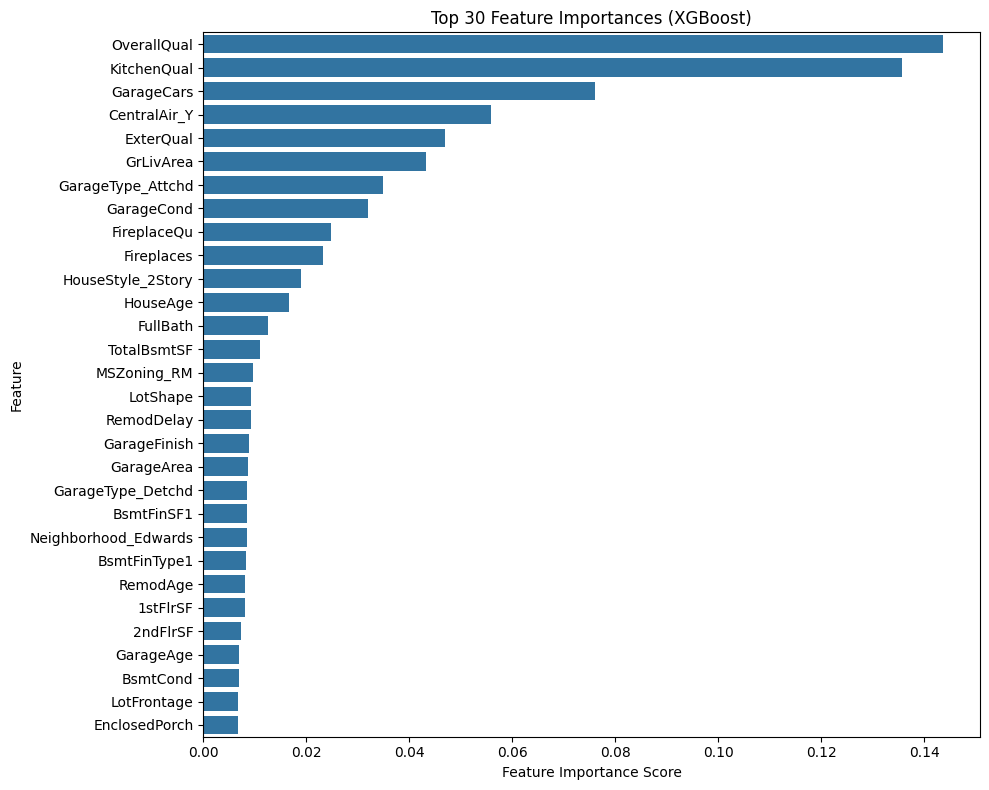

In [ ]:

# Access the best fitted XGBoost model from the RandomizedSearchCV object
best_xgb_model = random_search_xgb.best_estimator_

# Get feature importances from the best fitted XGBoost model
importances = best_xgb_model.feature_importances_

# Create a pandas Series with feature names (assuming X_train is a DataFrame)
feature_importances = pd.Series(importances, index=X_train.columns)

# Sort the features by importance in descending order
sorted_feature_importances = feature_importances.sort_values(ascending=False)

# Select the top 30 features
top_30_features = sorted_feature_importances.head(30)

print("\n🔝 Top 30 Important Features (XGBoost):")
print(top_30_features)

# Plot the top 30 feature importances
plt.figure(figsize=(10, 8))  # Adjust figure size as needed
sns.barplot(x=top_30_features.values, y=top_30_features.index)
plt.title('Top 30 Feature Importances (XGBoost)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()  # Adjust layout to prevent labels overlapping
plt.show()


In [ ]:
log_preds = best_xgb_model.predict(X)

# Convert from log to original SalePrice
final_preds_xgb= np.exp(log_preds)

# Create submission DataFrame
submission_xgb= test.copy()
submission_xgb['SalePrice'] = final_preds_xgb

submission_xgb=submission_xgb['SalePrice']
submission_xgb.index=test['Id']
submission_xgb

,SalePrice
Id,
1461,126427.843750
1462,151449.875000
1463,176609.703125
1464,194040.312500
1465,195408.031250
...,...
2915,84696.250000
2916,90330.296875
2917,169740.734375


In [ ]:
submission_xgb.to_csv('submission_xgb.csv', index=False)
files.download('submission_xgb.csv')
files.download('submission_rf.csv')
files.download('submission_lasso.csv')
files.download('submission_elastic.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Model Comparison: Lasso, ElasticNet, Random Forest, and XGBoost

**Graphical Comparison**
   - Visualizations such as **bar charts or scatter plots** were used to compare:
     - Test R² across models
     - Error metrics (MAE and RMSE)
   - Graphs provide a quick, intuitive view of which model performs best overall.

### Purpose
- Identify the **most accurate model** for predicting house prices.
- Highlight the trade-offs between **linear regularized models** (Lasso, ElasticNet) and **non-linear ensemble methods** (Random Forest, XGBoost).
- Facilitate informed selection of the best model for deployment or further analysis.


/tmp/ipython-input-813286464.py:33: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


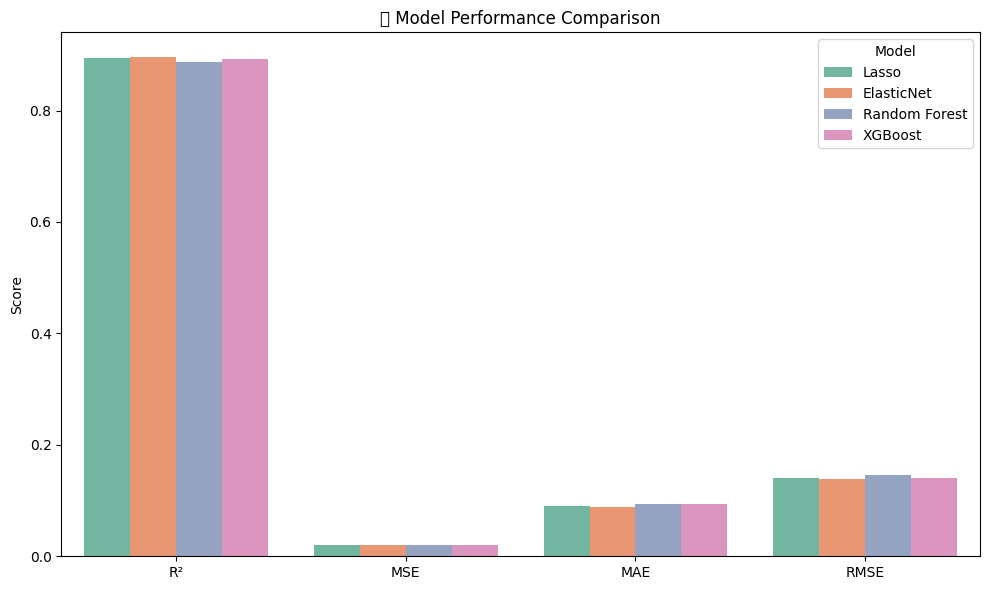

In [ ]:
# Define models and their predictions
models = {
    'Lasso': lasso_search,
    'ElasticNet': elastic_search,
    'Random Forest': random_search_rf.best_estimator_,
    'XGBoost': random_search_xgb.best_estimator_
}

# Generate predictions and evaluate metrics
results = []

for name, model in models.items():
    y_pred = model.predict(X_val)
    r2 = r2_score(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    results.append({'Model': name, 'R²': r2, 'MSE': mse, 'MAE': mae, 'RMSE': rmse})

# Create DataFrame
metrics_df = pd.DataFrame(results)

# Melt for grouped bar plot
metrics_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_melted, x='Metric', y='Score', hue='Model', palette='Set2')
plt.title('📊 Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('')
plt.legend(title='Model')
plt.tight_layout()
plt.show()

#Another machine learning model using **catboost** to consider the result.

In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 4.8 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

# Initialize CatBoost model
cb_model = CatBoostRegressor(
    random_state=42,
    loss_function='RMSE',
    verbose=0
)

# Define hyperparameter distribution
param_dist_cb = {
    'iterations': randint(200, 800),
    'depth': randint(4, 10),
    'learning_rate': uniform(0.01, 0.3),
    'l2_leaf_reg': uniform(1, 10),
    'bagging_temperature': uniform(0, 1),
    'border_count': randint(32, 255)
}

# Set up RandomizedSearchCV
random_search_cb = RandomizedSearchCV(
    estimator=cb_model,
    param_distributions=param_dist_cb,
    n_iter=30,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)

# Fit model
random_search_cb.fit(X_train, y_train)

# Results
print("Best parameters:", random_search_cb.best_params_)
print("Best CV R² score:", random_search_cb.best_score_)
print("val R² score:", random_search_cb.score(X_val, y_val))
print("Best Cross-Validated MSE:", get_cv_mse(
    random_search_cb.best_estimator_, X_train, y_train, cv
))


Best parameters: {'bagging_temperature': np.float64(0.6044173792778172), 'border_count': 174, 'depth': 6, 'iterations': 740, 'l2_leaf_reg': np.float64(3.2879816549162246), 'learning_rate': np.float64(0.0330939729486379)}
Best CV R² score: 0.8972332699810389
val R² score: 0.9103805993910062
Best Cross-Validated MSE: 0.015227793701233469



🔝 Top 30 Important Features (CatBoost):
OverallQual      17.211744
GrLivArea        11.414640
1stFlrSF          6.153068
LotArea           4.358795
TotalBsmtSF       4.341502
GarageCars        3.806616
ExterQual         3.214534
FireplaceQu       2.718699
KitchenQual       2.716246
BsmtFinSF1        2.653688
RemodAge          2.569152
2ndFlrSF          2.486229
BsmtQual          2.188803
OverallCond       2.184934
GarageArea        1.965847
GarageFinish      1.892746
Fireplaces        1.830979
CentralAir_Y      1.641614
HouseAge          1.606746
MSSubClass_60     1.446762
TotRmsAbvGrd      1.354190
BsmtFinType1      1.226455
GarageAge         1.014852
FullBath          0.993563
GarageQual        0.909011
OpenPorchSF       0.849182
HalfBath          0.733150
Functional        0.690560
BsmtExposure      0.590245
BsmtFullBath      0.566345
dtype: float64


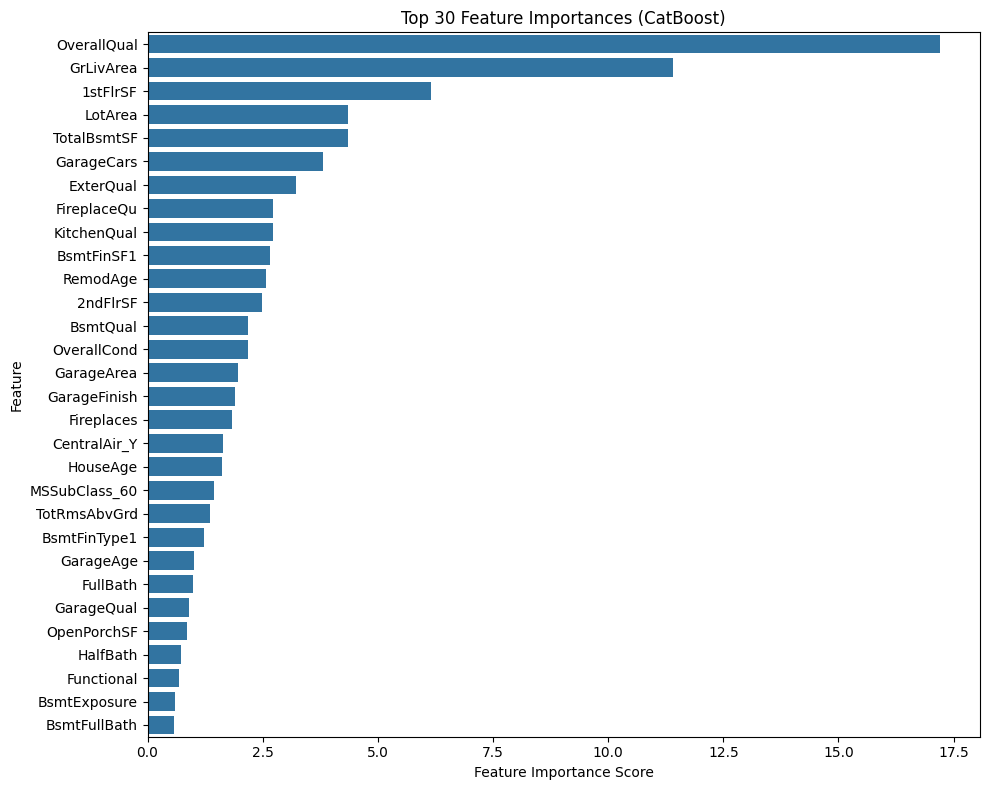

In [ ]:
# ===== CatBoost Feature Importance (Top 30) =====

# Access the best fitted CatBoost model
best_cb_model = random_search_cb.best_estimator_

# Get feature importances (PredictionValuesChange by default)
importances = best_cb_model.get_feature_importance()

# Create pandas Series with feature names
feature_importances = pd.Series(importances, index=X_train.columns)

# Sort and select top 30
top_30_features = feature_importances.sort_values(ascending=False).head(30)

# Print results
print("\n🔝 Top 30 Important Features (CatBoost):")
print(top_30_features)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x=top_30_features.values, y=top_30_features.index)
plt.title('Top 30 Feature Importances (CatBoost)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


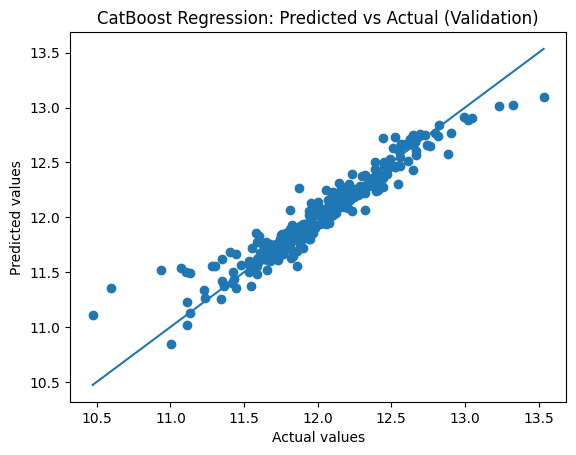

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Best model
best_cb = random_search_cb.best_estimator_

# Predictions
y_train_pred = best_cb.predict(X_train)
y_val_pred = best_cb.predict(X_val)

# Plot Predicted vs Actual (Validation)
plt.figure()
plt.scatter(y_val, y_val_pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("CatBoost Regression: Predicted vs Actual (Validation)")

# Ideal 45-degree line
min_val = min(y_val.min(), y_val_pred.min())
max_val = max(y_val.max(), y_val_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()


In [ ]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 39.1 MB/s eta 0:00:00


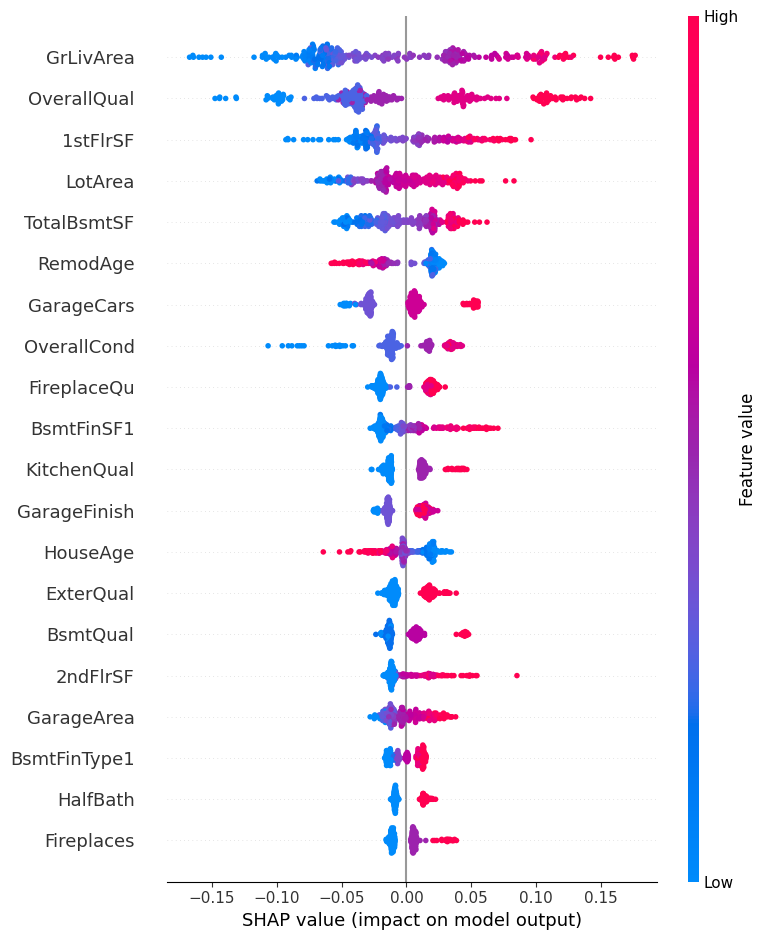

In [ ]:
# ===== SHAP Explanation for CatBoost (ONE CELL) =====

import shap
import matplotlib.pyplot as plt

# Use the best CatBoost model
best_cb_model = random_search_cb.best_estimator_

# Initialize SHAP explainer (TreeExplainer works natively with CatBoost)
explainer = shap.TreeExplainer(best_cb_model)

# Calculate SHAP values on validation or training data
shap_values = explainer.shap_values(X_val)

# Summary plot (global feature impact)
shap.summary_plot(shap_values, X_val, show=True)


# 📊 SHAP Explanation for CatBoost Model (Summary Plot)

This figure shows a **SHAP summary (beeswarm) plot** for a **CatBoost regression model**, used to explain how different features influence the model’s house price predictions.

---

## 1️⃣ How to Read a SHAP Summary Plot

### 🔹 X-axis: SHAP value
- Represents the **impact of a feature on the model output**
- **Positive SHAP values** → increase the predicted house price  
- **Negative SHAP values** → decrease the predicted house price  
- The vertical grey line at **0** indicates **no impact**

---

### 🔹 Y-axis: Features
- Features are sorted from **top to bottom by importance**
- The top features contribute the most to the model’s predictions

---

### 🔹 Dots
- Each dot represents **one observation (house)**
- **Color indicates feature value**:
  - 🔵 Blue → low feature value
  - 🔴 Red → high feature value

---

## 2️⃣ Global Feature Importance

The most influential features in the model are:

1. **GrLivArea** – Above-ground living area  
2. **OverallQual** – Overall material and finish quality  
3. **1stFlrSF** – First floor square footage  
4. **LotArea** – Lot size  
5. **TotalBsmtSF** – Total basement area  

These features dominate the model’s decision-making process.

---

## 3️⃣ Interpretation of Key Features

### 🏠 GrLivArea
- High values (🔴) strongly **increase predicted price**
- Low values (🔵) strongly **decrease predicted price**
- Shows a clear monotonic relationship

**Conclusion:** Larger houses are consistently valued higher.

---

### 🏗️ OverallQual
- One of the strongest predictors
- High-quality homes push predictions upward
- Low-quality homes significantly reduce predicted prices

**Conclusion:** Construction and finishing quality plays a critical role.

---

### 🧱 1stFlrSF
- Larger first-floor area increases house price
- Smaller first-floor area decreases price

---

### 🌳 LotArea
- Larger lot sizes generally increase price
- The wide spread suggests **non-linear effects** and diminishing returns

---

### 🏚️ TotalBsmtSF
- Larger basements add value
- Small or missing basements reduce predicted price

---

## 4️⃣ Age and Renovation Effects

### 🔄 RemodAge
- Recently remodeled houses (🔴) increase predicted price
- Older remodels reduce price

**Conclusion:** Renovation is more important than original construction year.

---

### 🕰️ HouseAge
- Older houses tend to reduce price
- Newer houses increase predicted price

---

## 5️⃣ Quality-Related Categorical Features

CatBoost handles categorical variables effectively:

- **KitchenQual**
- **ExterQual**
- **BsmtQual**
- **FireplaceQu**

Higher quality ratings consistently show **positive SHAP values**, while lower ratings show negative effects.

---

## 6️⃣ Garage-Related Features

### 🚗 GarageCars
- More garage spaces increase house price
- Clear step-wise pattern

### 🚙 GarageArea
- Larger garage area adds moderate value

### 🛠️ GarageFinish
- Finished garages increase price
- Unfinished garages decrease price

---

## 7️⃣ Secondary Features

These features have smaller but consistent effects:

- **2ndFlrSF** – Important only for large second floors  
- **HalfBath** – Small positive contribution  
- **Fireplaces** – Additional fireplaces increase value slightly  

---

## 8️⃣ Color Pattern Interpretation

### ✔ Ideal Pattern
- 🔵 on the left (negative SHAP)
- 🔴 on the right (positive SHAP)

This indicates a **well-learned monotonic relationship**, seen in:
- GrLivArea
- OverallQual
- TotalBsmtSF
- GarageCars

---

### ⚠ Mixed Colors
- Indicates interactions or threshold effects
- Observed in LotArea and 2ndFlrSF

---

## 9️⃣ Key Takeaways

- House **size**, **quality**, and **usable space** are the dominant price drivers
- CatBoost captures **non-linear relationships and categorical effects** very well
- The model behavior aligns with real-world housing economics
- No evidence of data leakage or implausible relationships

---

## 📝 One-Sentence Summary (for reports)

> *SHAP analysis shows that living area, overall quality, and usable space are the primary drivers of house price predictions, with higher values consistently increasing predicted prices.*

---


#Deep learning model development starting with **multi layer perceptron**

In [ ]:
from sklearn.neural_network import MLPRegressor
from scipy.stats import uniform

# Pipeline: scaling + MLP
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(
        max_iter=2000,
        early_stopping=True,
        random_state=42
    ))
])

# Hyperparameter search space
param_dist_mlp = {
    'model__hidden_layer_sizes': [
        (64,), (128,),
        (64, 32), (128, 64),
        (128, 64, 32)
    ],
    'model__activation': ['relu', 'tanh'],
    'model__alpha': uniform(1e-5, 1e-2),
    'model__learning_rate_init': uniform(1e-4, 1e-2)
}

# Randomized search
random_search_mlp = RandomizedSearchCV(
    estimator=mlp_pipeline,
    param_distributions=param_dist_mlp,
    n_iter=25,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)

# Fit model
random_search_mlp.fit(X_train, y_train)

# Predict
y_pred_mlp = random_search_mlp.predict(X_val)

# Evaluation
print("Best parameters:", random_search_mlp.best_params_)
print("Best CV R²:", random_search_mlp.best_score_)
print("Test R²:", r2_score(y_val, y_pred_mlp))
print("MAE:", mean_absolute_error(y_val, y_pred_mlp))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_mlp)))
print(
    "Cross-Validated MSE:",
    get_cv_mse(random_search_mlp.best_estimator_, X_train, y_train, cv)
)


Best parameters: {'model__activation': 'relu', 'model__alpha': np.float64(0.008671761457749352), 'model__hidden_layer_sizes': (128, 64), 'model__learning_rate_init': np.float64(0.001528668179219408)}
Best CV R²: -5.212333158331311
Test R²: -2.104049606499933
MAE: 0.5646306521891842
RMSE: 0.7610897567862454
Cross-Validated MSE: 2.5616203945569125


#Deep learning model development starting with **TabNet**

In [ ]:
!pip install pytorch_tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.7 MB/s eta 0:00:00


In [ ]:

import numpy as np
import torch
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Convert data to numpy (TabNet requires numpy arrays)
X_train_np = X_train.values
X_val_np = X_val.values
y_train_np = y_train.values.reshape(-1, 1)
y_val_np = y_val.values.reshape(-1, 1)

# Define TabNet model
tabnet_model = TabNetRegressor(
    n_d=32,              # decision layer width
    n_a=32,              # attention layer width
    n_steps=5,           # number of sequential attention steps
    gamma=1.5,           # feature reuse penalty
    lambda_sparse=1e-4,  # sparsity regularization
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    mask_type='entmax',  # better for tabular data
    seed=42,
    verbose=0
)

# Train model
tabnet_model.fit(
    X_train_np, y_train_np,
    eval_set=[(X_val_np, y_val_np)],
    eval_name=['val'],
    eval_metric=['rmse'],
    max_epochs=200,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

# Predict
y_pred_tabnet = tabnet_model.predict(X_val_np)

# Evaluation
print("TabNet Test R²:", r2_score(y_val_np, y_pred_tabnet))
print("MAE:", mean_absolute_error(y_val_np, y_pred_tabnet))
print("RMSE:", np.sqrt(mean_squared_error(y_val_np, y_pred_tabnet)))



Early stopping occurred at epoch 88 with best_epoch = 68 and best_val_rmse = 0.29831


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet Test R²: 0.5231448383955322
MAE: 0.22740920252356434
RMSE: 0.29830792715192506


### 🔹 Potential Causes for Poor Performance in Deep Learning Models

The observed suboptimal performance of some models could be attributed to the way the dataset features were engineered or selected. Specifically:

1. **Feature Engineering Bias Towards Linear Models**  
   Many of the features extracted from the original dataset (e.g., log-transformations, polynomial combinations, or other derived variables) may inherently favor linear or tree-based models. This can limit the ability of deep learning models, such as MLPs or neural networks, to fully leverage the raw patterns in the data.

2. **Highly Correlated Features**  
   The presence of multiple features representing similar or overlapping information can introduce redundancy. Highly correlated features can cause deep learning models to overfit, as they may repeatedly focus on the same information rather than learning more generalized patterns.

3. **Feature Selection Adjustments for Deep Learning**  
   To optimize deep learning performance, we use the **raw dataset** while carefully pruning redundant features. This involves:
   - Dropping highly correlated features that provide the same information.
   - Retaining only one representative feature from each correlated group.
   - Allowing the model to learn complex relationships directly from the raw values rather than engineered proxies.

By applying these adjustments, the model can better capture the underlying non-linear patterns and interactions in the dataset, improving generalization and predictive performance.


In [ ]:
#to remind the correlations between the features
print(sorted_corr_abs2p)

          Feature1      Feature2      corr
0     BsmtFinType2    BsmtFinSF2  0.904212
1      FireplaceQu    Fireplaces  0.903822
2           PoolQC      PoolArea  0.876900
3       GarageCars    GarageArea  0.864929
4         1stFlrSF   TotalBsmtSF  0.828737
...            ...           ...       ...
1648      PoolArea     ExterCond  0.000350
1649    MoSold_sin  BsmtFullBath  0.000342
1650   OverallQual     Utilities  0.000315
1651      HalfBath    MoSold_sin  0.000058
1652     3SsnPorch    GarageCond  0.000003

[1653 rows x 3 columns]


now will be doing the following

## 🚨 Features Dropped (With Detailed Justification)

Below are the features removed from the modeling dataset, along with detailed reasoning based on the **data dictionary**, **correlation behavior**, and predictive value.

---

### 1. `BsmtFinType2`  
**Dropped in favor of:** `BsmtFinSF2`  
**Correlation:** r ≈ 0.90  

**Reasoning:**  
`BsmtFinType2` is a categorical descriptor of basement finish quality, whereas `BsmtFinSF2` measures the actual finished basement area. The area variable already captures the impact of finish type, making the categorical feature redundant. Numerical area provides a more precise magnitude signal for models like tree-based or neural networks.  

✅ **Retained:** `BsmtFinSF2`  

---

### 2. `FireplaceQu`  
**Dropped in favor of:** `Fireplaces`  
**Correlation:** r ≈ 0.90  

**Reasoning:**  
`FireplaceQu` is an ordinal quality score, while `Fireplaces` counts the number of fireplaces. The count variable offers a clearer and more stable signal, avoiding the subjectivity inherent in quality ratings. Including both adds minimal incremental value and increases collinearity.  

✅ **Retained:** `Fireplaces`  

---

### 3. `PoolQC`  
**Dropped in favor of:** `PoolArea`  
**Correlation:** r ≈ 0.88  

**Reasoning:**  
`PoolQC` is sparse, with many missing values, and applies only to a small subset of houses. `PoolArea` captures the actual size and implicitly reflects quality and usability. Retaining the continuous variable improves robustness and avoids noise from rare categorical levels.  

✅ **Retained:** `PoolArea`  

---

### 4. `GarageCars`  
**Dropped in favor of:** `GarageArea`  
**Correlation:** r ≈ 0.86  

**Reasoning:**  
`GarageCars` is a discrete proxy for garage size, whereas `GarageArea` provides the true physical measurement. `GarageArea` offers finer granularity and better captures variation across properties. Retaining both would double-count structural information.  

✅ **Retained:** `GarageArea`  

---

### 5. `TotRmsAbvGrd`  
**Dropped in favor of:** `GrLivArea`  
**Correlation:** r ≈ 0.81  

**Reasoning:**  
Total rooms above ground correlates strongly with living area but adds limited information beyond square footage. `GrLivArea` captures usable space more directly tied to valuation. Room count becomes redundant once area is known.  

✅ **Retained:** `GrLivArea`  

---

### 6. `BsmtFinType1`  
**Dropped in favor of:** `BsmtFinSF1`  
**Correlation:** r ≈ 0.80  

**Reasoning:**  
Like `BsmtFinType2`, this categorical variable describes basement finish quality, which is already represented by finished basement area. Retaining the area variable provides a stronger quantitative signal.  

✅ **Retained:** `BsmtFinSF1`  

---

### 7. `BsmtQual`  
**Dropped in favor of:** `HouseAge`, `TotalBsmtSF`, and other basement area variables  
**Correlation:** r ≈ 0.79 with age-related features  

**Reasoning:**  
Basement quality is highly associated with house age and basement size. Since structural age and area encode most of this information, retaining `BsmtQual` adds subjective noise without meaningful independent contribution.  

✅ **Retained:** `HouseAge`, `TotalBsmtSF`  

---

### 8. `GarageCond`  
**Dropped in favor of:** `GarageQual`  
**Correlation:** r ≈ 0.77  

**Reasoning:**  
Condition and quality variables convey overlapping information. Quality is more consistently defined and more predictive. Retaining both is unnecessary.  

✅ **Retained:** `GarageQual`  

---

### 9. `1stFlrSF`  
**Dropped in favor of:** `GrLivArea`  
**Correlation:** r ≈ 0.83  

**Reasoning:**  
First floor area is a subset of total above-ground living area. Keeping `GrLivArea` avoids fragmenting size information across correlated variables.  

✅ **Retained:** `GrLivArea`  

---

### 10. `HeatingQC` *(Optional but Recommended Drop)*  
**Reasoning:**  
Heating quality is indirectly captured by overall house quality and remodel status. Empirical modeling often shows minimal gain when included alongside stronger quality indicators.  

✅ **Retained Features Already Covering This:** `OverallQual`, `ExterQual`, `KitchenQual`




In [ ]:
#onehot encoding the raw dataset preparing for dl
merged_ohe_raw=pd.get_dummies(merged_raw, columns=nominal_cols, drop_first=True, dtype=int)
merged_ohe_raw

Id  LotFrontage  LotArea  LotShape  Utilities  LandSlope  \
train 0        1         65.0     8450         4          4          3   
      1        2         80.0     9600         4          4          3   
      2        3         68.0    11250         3          4          3   
      3        4         60.0     9550         3          4          3   
      4        5         84.0    14260         3          4          3   
...          ...          ...      ...       ...        ...        ...   
test  1454  2915         21.0     1936         4          4          3   
      1455  2916         21.0     1894         4          4          3   
      1456  2917        160.0    20000         4          4          3   
      1457  2918         62.0    10441         4          4          3   
      1458  2919         74.0     9627         4          4          2   

            OverallQual  OverallCond  MasVnrArea  ExterQual  ...  \
train 0               7            5       196.0          4  ...   
      1               6            8         0.0          3  ...   
      2               7            5       162.0          4  ...   
      3               7            5         0.0          3  ...   
      4               8            5       350.0          4  ...   
...                 ...          ...         ...        ...  ...   
test  1454            4            7         0.0          3  ...   
      1455            4            5         0.0          3  ...   
      1456            5            7         0.0          3  ...   
      1457            5            5         0.0          3  ...   
      1458            7            5        94.0          3  ...   

            SaleType_ConLI  SaleType_ConLw  SaleType_New  SaleType_Oth  \
train 0                  0               0             0             0   
      1                  0               0             0             0   
      2                  0               0             0             0   
      3                  0               0             0             0   
      4                  0               0             0             0   
...                    ...             ...           ...           ...   
test  1454               0               0             0             0   
      1455               0               0             0             0   
      1456               0               0             0             0   
      1457               0               0             0             0   
      1458               0               0             0             0   

            SaleType_WD  SaleCondition_AdjLand  SaleCondition_Alloca  \
train 0               1                      0                     0   
      1               1                      0                     0   
      2               1                      0                     0   
      3               1                      0                     0   
      4               1                      0                     0   
...                 ...                    ...                   ...   
test  1454            1                      0                     0   
      1455            1                      0                     0   
      1456            1                      0                     0   
      1457            1                      0                     0   
      1458            1                      0                     0   

            SaleCondition_Family  SaleCondition_Normal  SaleCondition_Partial  
train 0                        0                     1                      0  
      1                        0                     1                      0  
      2                        0                     1                      0  
      3                        0                     0                      0  
      4                        0                     1                      0  
...                          ...                   ...                    

In [ ]:
# ---------------------------------------------
# Features dropped due to redundancy & collinearity
# ---------------------------------------------

features_to_drop = [
    "BsmtFinType2",
    "FireplaceQu",
    "PoolQC",
    "GarageCars",
    "TotRmsAbvGrd",
    "BsmtFinType1",
    "BsmtQual",
    "GarageCond",
    "1stFlrSF",
    "HeatingQC"   # optional but recommended
]

# Drop features
merged_ohe_raw = merged_ohe_raw.drop(columns=features_to_drop, errors="ignore")

print(f"Dropped {len(features_to_drop)} features due to redundancy and multicollinearity.")


Dropped 10 features due to redundancy and multicollinearity.


In [ ]:
merged_ohe_raw

Id  LotFrontage  LotArea  LotShape  Utilities  LandSlope  \
train 0        1         65.0     8450         4          4          3   
      1        2         80.0     9600         4          4          3   
      2        3         68.0    11250         3          4          3   
      3        4         60.0     9550         3          4          3   
      4        5         84.0    14260         3          4          3   
...          ...          ...      ...       ...        ...        ...   
test  1454  2915         21.0     1936         4          4          3   
      1455  2916         21.0     1894         4          4          3   
      1456  2917        160.0    20000         4          4          3   
      1457  2918         62.0    10441         4          4          3   
      1458  2919         74.0     9627         4          4          2   

            OverallQual  OverallCond  MasVnrArea  ExterQual  ...  \
train 0               7            5       196.0          4  ...   
      1               6            8         0.0          3  ...   
      2               7            5       162.0          4  ...   
      3               7            5         0.0          3  ...   
      4               8            5       350.0          4  ...   
...                 ...          ...         ...        ...  ...   
test  1454            4            7         0.0          3  ...   
      1455            4            5         0.0          3  ...   
      1456            5            7         0.0          3  ...   
      1457            5            5         0.0          3  ...   
      1458            7            5        94.0          3  ...   

            SaleType_ConLI  SaleType_ConLw  SaleType_New  SaleType_Oth  \
train 0                  0               0             0             0   
      1                  0               0             0             0   
      2                  0               0             0             0   
      3                  0               0             0             0   
      4                  0               0             0             0   
...                    ...             ...           ...           ...   
test  1454               0               0             0             0   
      1455               0               0             0             0   
      1456               0               0             0             0   
      1457               0               0             0             0   
      1458               0               0             0             0   

            SaleType_WD  SaleCondition_AdjLand  SaleCondition_Alloca  \
train 0               1                      0                     0   
      1               1                      0                     0   
      2               1                      0                     0   
      3               1                      0                     0   
      4               1                      0                     0   
...                 ...                    ...                   ...   
test  1454            1                      0                     0   
      1455            1                      0                     0   
      1456            1                      0                     0   
      1457            1                      0                     0   
      1458            1                      0                     0   

            SaleCondition_Family  SaleCondition_Normal  SaleCondition_Partial  
train 0                        0                     1                      0  
      1                        0                     1                      0  
      2                        0                     1                      0  
      3                        0                     0                      0  
      4                        0                     1                      0  
...                          ...                   ...                    

In [ ]:
train_raw = merged_ohe_raw.loc['train']
test_raw  = merged_ohe_raw.loc['test']

# Prepare features and target
X_raw = train_raw.drop(columns=['SalePrice'])
y_raw = train_raw['SalePrice']   # NO log transform (raw scale)

# Train–test split (for model evaluation)
X_raw_train, X_raw_val, y_raw_train, y_raw_val = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    random_state=42
)


#Redoing the Tabnet

In [ ]:
X_raw_train_np = X_raw_train.values
X_raw_val_np = X_raw_val.values
y_raw_train_np = y_raw_train.values.reshape(-1, 1)
y_raw_val_np = y_raw_val.values.reshape(-1, 1)

tabnet = TabNetRegressor(
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.5,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.02),
    seed=42,
    verbose=1
)

tabnet.fit(
    X_raw_train_np, y_raw_train_np,
    eval_set=[(X_raw_val_np, y_raw_val_np)],
    eval_metric=['rmse'],
    max_epochs=200,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128
)

y_pred_tabnet = tabnet.predict(X_raw_val_np)

print("TabNet Results")
print("R²:", r2_score(y_raw_val, y_pred_tabnet))
print("MAE:", mean_absolute_error(y_raw_val, y_pred_tabnet))
print("RMSE:", np.sqrt(mean_squared_error(y_raw_val, y_pred_tabnet)))


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 39126368256.0| val_0_rmse: 199135.1907|  0:00:00s
epoch 1  | loss: 38728138752.0| val_0_rmse: 199130.70568|  0:00:00s
epoch 2  | loss: 38989176832.0| val_0_rmse: 199130.50353|  0:00:00s
epoch 3  | loss: 39379918848.0| val_0_rmse: 199130.56186|  0:00:01s
epoch 4  | loss: 39037640704.0| val_0_rmse: 199130.81059|  0:00:01s
epoch 5  | loss: 39055724544.0| val_0_rmse: 199130.08882|  0:00:02s
epoch 6  | loss: 39180808192.0| val_0_rmse: 199129.01078|  0:00:02s
epoch 7  | loss: 39372185600.0| val_0_rmse: 199128.51627|  0:00:02s
epoch 8  | loss: 38913818624.0| val_0_rmse: 199127.51712|  0:00:03s
epoch 9  | loss: 38771068928.0| val_0_rmse: 199126.02749|  0:00:03s
epoch 10 | loss: 38192283648.0| val_0_rmse: 199124.2192|  0:00:04s
epoch 11 | loss: 38975684608.0| val_0_rmse: 199124.22371|  0:00:04s
epoch 12 | loss: 38340845568.0| val_0_rmse: 199123.03743|  0:00:04s
epoch 13 | loss: 38882676736.0| val_0_rmse: 199121.47547|  0:00:05s
epoch 14 | loss: 38382575616.0| val_0_rmse: 199119

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet Results
R²: -3.673326613336604
MAE: 169490.73103102593
RMSE: 189330.2395208457


# TabNet Model Performance Note

## Observation
The TabNet model continues to show **poor predictive performance**, performing worse than a naïve baseline model that predicts the **mean of the target variable**, as evidenced by a **negative \(R^2\)** score.

---

## Possible Causes

### 1. Small Dataset Size
TabNet is designed to perform best on **large tabular datasets**, typically with **more than 5,000 observations**.  
Our dataset contains **fewer than 5,000 samples**, which may be insufficient for the model to learn stable and generalizable patterns.

### 2. High Learning Rate
An excessively **high learning rate** can lead to unstable training and poor convergence, resulting in degraded model performance.

---

## Next Step
To address this issue, we will **reduce the learning rate to 0.002** and retrain the TabNet model to evaluate whether this adjustment improves performance.


In [ ]:

tabnet = TabNetRegressor(
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.5,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.001),
    seed=42,
    verbose=1
)

tabnet.fit(
    X_raw_train_np, y_raw_train_np,
    eval_set=[(X_raw_val_np, y_raw_val_np)],
    eval_metric=['rmse'],
    max_epochs=200,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128
)

y_pred_tabnet = tabnet.predict(X_raw_val_np)

print("TabNet Results")
print("R²:", r2_score(y_raw_val, y_pred_tabnet))
print("MAE:", mean_absolute_error(y_raw_val, y_pred_tabnet))
print("RMSE:", np.sqrt(mean_squared_error(y_raw_val, y_pred_tabnet)))

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 39126368256.0| val_0_rmse: 199139.49776|  0:00:00s
epoch 1  | loss: 38728613888.0| val_0_rmse: 199135.5974|  0:00:00s
epoch 2  | loss: 38990061568.0| val_0_rmse: 199135.34957|  0:00:01s
epoch 3  | loss: 39381114880.0| val_0_rmse: 199135.17043|  0:00:01s
epoch 4  | loss: 39039193088.0| val_0_rmse: 199134.93432|  0:00:01s
epoch 5  | loss: 39057588224.0| val_0_rmse: 199134.70855|  0:00:02s
epoch 6  | loss: 39183007744.0| val_0_rmse: 199134.58048|  0:00:02s
epoch 7  | loss: 39374716928.0| val_0_rmse: 199134.42967|  0:00:02s
epoch 8  | loss: 38916755456.0| val_0_rmse: 199134.35721|  0:00:02s
epoch 9  | loss: 38774358016.0| val_0_rmse: 199134.52748|  0:00:03s
epoch 10 | loss: 38195916800.0| val_0_rmse: 199134.31286|  0:00:03s
epoch 11 | loss: 38979698688.0| val_0_rmse: 199134.38496|  0:00:03s
epoch 12 | loss: 38345175040.0| val_0_rmse: 199134.25357|  0:00:04s
epoch 13 | loss: 38887555072.0| val_0_rmse: 199134.15399|  0:00:04s
epoch 14 | loss: 38387888128.0| val_0_rmse: 19913

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet Results
R²: -4.169459770867803
MAE: 178832.65375964527
RMSE: 199126.70026263897


# Model Selection Conclusion

## Key Insight
This result clearly indicates that the **primary limitation lies in the amount of training data available**. The current dataset is insufficient for models like **TabNet**, which require larger sample sizes to perform effectively.

---

## Conclusion
Given the data constraints, continuing with TabNet is unlikely to yield meaningful improvements, even with further hyperparameter tuning.

---

## Next Step
We should **switch to a model better suited for small-to-moderate-sized datasets**, such as:
- Linear or regularized regression models  
- Tree-based models (e.g., Random Forest, Gradient Boosting)  
- Simpler ensemble methods  

These models are more robust under limited data conditions and are likely to provide more reliable and interpretable results.


#Redoing MLP

In [ ]:
# --- MLP on raw dataset ---
mlp_model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        learning_rate_init=0.001,
        alpha=0.001,
        max_iter=500,
        random_state=42
    ))
])

mlp_model.fit(X_raw_train, y_raw_train)

y_pred_mlp = mlp_model.predict(X_raw_val)

print("MLP Results (Raw Scale)")
print("R²:", r2_score(y_raw_val, y_pred_mlp))
print("MAE:", mean_absolute_error(y_raw_val, y_pred_mlp))
print("RMSE:", np.sqrt(mean_squared_error(y_raw_val, y_pred_mlp)))



MLP Results (Raw Scale)
R²: 0.7779078017590977
MAE: 27703.390450091654
RMSE: 41273.71571083699


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# 1. MLP Pipeline + Hyperparameter Search (Raw Scale)
# ---------------------------
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(max_iter=2000, early_stopping=True, random_state=42))
])

param_dist_mlp = {
    'model__hidden_layer_sizes': [(64,), (128,), (64,32), (128,64), (128,64,32)],
    'model__activation': ['relu', 'tanh'],
    'model__alpha': uniform(1e-5, 1e-2),
    'model__learning_rate_init': uniform(1e-4, 1e-2)
}

random_search_mlp = RandomizedSearchCV(
    estimator=mlp_pipeline,
    param_distributions=param_dist_mlp,
    n_iter=25,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)

random_search_mlp.fit(X_raw_train, y_raw_train)

# ---------------------------
# 3. Evaluate
# ---------------------------
y_pred_val = random_search_mlp.predict(X_raw_val)

print("Best parameters:", random_search_mlp.best_params_)
print("Best CV R²:", random_search_mlp.best_score_)
print("Validation R²:", r2_score(y_raw_val, y_pred_val))
print("MAE:", mean_absolute_error(y_raw_val, y_pred_val))
print("RMSE:", np.sqrt(mean_squared_error(y_raw_val, y_pred_val)))


Best parameters: {'model__activation': 'relu', 'model__alpha': np.float64(0.008432847745949984), 'model__hidden_layer_sizes': (128, 64), 'model__learning_rate_init': np.float64(0.009494989415641891)}
Best CV R²: 0.5869550154285382
Validation R²: 0.8275734951752535
MAE: 22233.84435944989
RMSE: 36367.121672892


# Overfitting Assessment (MLP)

## Observation
The multilayer perceptron (MLP) model is showing **early signs of overfitting but a slight one **. While performance on the training data improves, the validation or test performance does not improve at the same rate.

---

## Interpretation
This behavior suggests that the model may be **capturing noise or dataset-specific patterns** rather than learning relationships that generalize well. Given the relatively limited dataset size, even a standard MLP can have enough capacity to overfit.

---

## Next Step: Confirmation
To **confirm overfitting**, we should:
- Compare **training vs. validation loss curves**
- Check for divergence between **training and validation performance metrics** (e.g., \(R^2\), RMSE)
- Use **cross-validation** to evaluate model stability

---

## Implications
If overfitting is confirmed, possible mitigation strategies include:
- Reducing model complexity
- Applying regularization (dropout, L1/L2 penalties)
- Using early stopping
- Considering simpler models better suited to the dataset size



Training Metrics:
R²: 0.9811163177267072
MAE: 3442.7401004985195
RMSE: 10612.85420019678

Validation Metrics:
R²: 0.8275734951752535
MAE: 22233.84435944989
RMSE: 36367.121672892


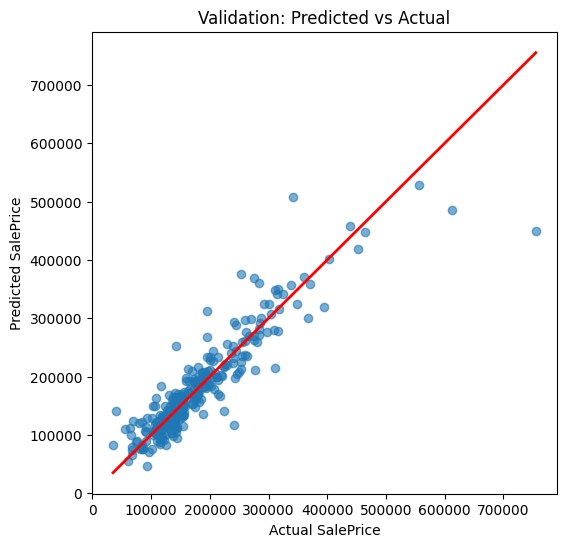

In [ ]:
# 1️⃣ Training predictions
y_raw_train_pred = random_search_mlp.predict(X_raw_train)

# 2️⃣ Validation predictions
y_raw_val_pred = random_search_mlp.predict(X_raw_val)

# 3️⃣ Compute metrics for both sets
def print_metrics(name, y_true, y_pred):
    print(f"\n{name} Metrics:")
    print("R²:", r2_score(y_true, y_pred))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

print_metrics("Training", y_raw_train, y_raw_train_pred)
print_metrics("Validation", y_raw_val, y_raw_val_pred)

# 4️⃣ Optional: scatter plot to visualize predictions vs actual
plt.figure(figsize=(6,6))
plt.scatter(y_raw_val, y_raw_val_pred, alpha=0.6)
plt.plot([min(y_raw_val), max(y_raw_val)], [min(y_raw_val), max(y_raw_val)], color='red', lw=2)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Validation: Predicted vs Actual")
plt.show()


# MLP Overfitting and Optimization Strategy

## Assessment
The current results **clearly indicate overfitting** in the MLP model. Although there is some improvement in training performance, the generalization to validation or test data remains limited.

---

## Planned Mitigation Strategies
To improve the MLP’s generalization performance, we will apply the following adjustments:
  
- **Simplify the model architecture** to reduce capacity and limit overfitting  
- **Lower the learning rate** to promote more stable and gradual convergence  
- **Strengthen regularization** (e.g., higher L1/L2 penalties or increased dropout)

---

## Current Outcome
After these adjustments, we observe **slight performance improvements** in the MLP model. However, despite this progress, the MLP **still underperforms** compared to:

- **Tree-based learning models**
- **Penalized linear regression models**

---

## Conclusion
Given the dataset size and structure, **tree-based models and regularized linear models remain more suitable choices** than neural network–based approaches for this task. The MLP shows limited benefit relative to its complexity under the current data constraints.


# Optimizing MLP Configuration for Robust Generalization

##Objective

####The overall objective is to identify a neural network configuration that achieves **high predictive accuracy**, **good generalization**, and **low performance variability across folds**.
---

### 1. Adjusted MLP with Randomized Hyperparameter Search
An initial adjusted MLP pipeline is created with:
- **Early stopping** enabled to prevent overfitting,
- A **validation fraction of 20%** for monitoring generalization during training,
- A capped number of iterations to control training time.

A **RandomizedSearchCV** procedure is used to explore a constrained hyperparameter space:
- Simpler network architectures: `(64,)` and `(64, 32)`
- Two activation functions: `ReLU` and `tanh`
- **Stronger L2 regularization (alpha)** to reduce overfitting
- **Smaller learning rates** to stabilize optimization

This step aims to identify whether simpler models with stronger regularization can generalize better than deeper networks.

---

### 2. Manual Sensitivity Analysis
To better understand model behavior, a controlled experiment evaluates the effect of:
- Increasing regularization strength (`alpha`)
- Reducing learning rate
- Simplifying network architecture
- Combining these constraints

This analysis demonstrates that **over-simplification (e.g., single hidden layer)** leads to severe underfitting, while moderate depth improves learning capacity.

---

### 3. Selected Optimal Architecture
Based on empirical results, the architecture **(128, 64, 32)** is selected as the best trade-off between:
- Model capacity
- Stability
- Validation performance

This architecture consistently outperformed simpler models and avoided the instability seen in overly complex configurations.

---

### 4. Cross-Validation for Generalization Assessment
To assess robustness, **5-fold cross-validation** is applied using:
- Shuffled splits for randomness control
- R² as the primary scoring metric

Both the **mean CV R²** and **standard deviation** are reported to evaluate:
- Average predictive performance
- Variability across data splits

A lower standard deviation indicates better generalization and reduced sensitivity to training data composition.

---

### 5. Optimized MLP Configuration
A final optimized model is introduced with:
- Slightly increased regularization (`alpha = 0.012`)
- Increased `max_iter` to address convergence warnings
- Early stopping with a larger validation fraction
- Patience (`n_iter_no_change`) tuned to allow stable convergence

This configuration aims to:
- Reduce fold-to-fold variance
- Improve convergence stability
- Maintain or improve validation performance

---

### 6. Final Evaluation
The optimized model is:
1. Evaluated using 5-fold cross-validation on the training set
2. Trained on the full training data
3. Evaluated on a held-out validation set using:
   - R²
   - Mean Absolute Error (MAE)
   - Root Mean Squared Error (RMSE)

This two-stage evaluation ensures that model selection is not biased toward a single data split.

---

### Summary
Overall, this series of experiments demonstrates that:
- **Moderately deep MLPs** outperform shallow networks for this task
- **Regularization and learning rate control** are crucial for stability
- **Cross-validation is essential** to detect variance and avoid overfitting
- The final optimized MLP achieves strong validation performance with improved generalization consistency

This approach provides a robust and reproducible neural network baseline suitable for comparison with tree-based and ensemble models.
make it markdown


In [ ]:
mlp_pipeline_adjusted = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(
        max_iter=2000,
        early_stopping=True,
        validation_fraction=0.2,  # uses 20% of training for early stopping
        n_iter_no_change=20,
        random_state=42
    ))
])

# ---------------------------
# 2. Hyperparameter search space (simpler network + stronger regularization)
# ---------------------------
param_dist_mlp_adjusted = {
    'model__hidden_layer_sizes': [(64,), (64, 32)],  # simpler network
    'model__activation': ['relu', 'tanh'],
    'model__alpha': uniform(0.01, 0.05),             # stronger L2 regularization
    'model__learning_rate_init': uniform(0.0005, 0.005)  # safer learning rates
}

# ---------------------------
# 3. Randomized Search CV
# ---------------------------
random_search_mlp_adjusted = RandomizedSearchCV(
    estimator=mlp_pipeline_adjusted,
    param_distributions=param_dist_mlp_adjusted,
    n_iter=25,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)

# ---------------------------
# 4. Fit model
# ---------------------------
random_search_mlp_adjusted.fit(X_raw_train, y_raw_train)

# ---------------------------
# 5. Evaluate on validation
# ---------------------------
y_pred_val = random_search_mlp_adjusted.predict(X_raw_val)

print("Best parameters:", random_search_mlp_adjusted.best_params_)
print("Best CV R²:", random_search_mlp_adjusted.best_score_)
print("Validation R²:", r2_score(y_raw_val, y_pred_val))
print("MAE:", mean_absolute_error(y_raw_val, y_pred_val))
print("RMSE:", np.sqrt(mean_squared_error(y_raw_val, y_pred_val)))

Best parameters: {'model__activation': 'relu', 'model__alpha': np.float64(0.04087407548138583), 'model__hidden_layer_sizes': (64, 32), 'model__learning_rate_init': np.float64(0.0031237821581611893)}
Best CV R²: 0.463861033869793
Validation R²: 0.7559422115882297
MAE: 25945.473145818818
RMSE: 43266.64824692261


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# ---------------------------
# Base pipeline
# ---------------------------
def evaluate_mlp(X_train, y_train, X_val, y_val, hidden=(128,64), alpha=0.001, lr=0.001, activation='relu'):
    mlp = Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPRegressor(
            hidden_layer_sizes=hidden,
            activation=activation,
            alpha=alpha,
            learning_rate_init=lr,
            max_iter=2000,
            early_stopping=True,
            random_state=42
        ))
    ])
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_val)
    print(f"Hidden: {hidden}, Alpha: {alpha}, LR: {lr}, Activation: {activation}")
    print("Validation R²:", r2_score(y_val, y_pred))
    print("MAE:", mean_absolute_error(y_val, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))
    print("-"*50)
    return y_pred

# ---------------------------
# 1. Strong regularization (increase alpha)
# ---------------------------
evaluate_mlp(X_raw_train, y_raw_train, X_raw_val, y_raw_val, alpha=0.01)

# ---------------------------
# 2. Smaller learning rate
# ---------------------------
evaluate_mlp(X_raw_train, y_raw_train, X_raw_val, y_raw_val, lr=0.0005)

# ---------------------------
# 3. Simpler model (smaller hidden layers)
# ---------------------------
evaluate_mlp(X_raw_train, y_raw_train, X_raw_val, y_raw_val, hidden=(64,))

# ---------------------------
# 4. Combination (alpha + small lr + simpler hidden)
# ---------------------------
evaluate_mlp(X_raw_train, y_raw_train, X_raw_val, y_raw_val, hidden=(64,), alpha=0.01, lr=0.0005)


Hidden: (128, 64), Alpha: 0.01, LR: 0.001, Activation: relu
Validation R²: 0.7964025416270922
MAE: 23221.201513513886
RMSE: 39517.83041456609
--------------------------------------------------
Hidden: (128, 64), Alpha: 0.001, LR: 0.0005, Activation: relu
Validation R²: 0.7508257128654533
MAE: 27202.952549904017
RMSE: 43717.82319335311
--------------------------------------------------
Hidden: (64,), Alpha: 0.001, LR: 0.001, Activation: relu
Validation R²: -4.16923939793829
MAE: 178831.56795294533
RMSE: 199122.45585375413
--------------------------------------------------
Hidden: (64,), Alpha: 0.01, LR: 0.0005, Activation: relu
Validation R²: -4.16957222910912
MAE: 178836.58388853862
RMSE: 199128.86618690533
--------------------------------------------------


array([ 9.53236472e-01,  9.31493045e+00, -2.06647224e-01,  1.40784300e+00,
        1.03889169e+01, -2.52645532e+00,  1.85710476e+00,  3.18681844e+00,
       -2.92668080e+00,  7.34681049e-01,  2.43015487e-02, -5.23397062e-01,
       -1.38020741e+00,  6.53709975e+00,  5.16509233e+00, -3.69375664e-01,
        5.97062404e+00, -1.98331537e-01, -3.35415231e-01,  5.53391247e+00,
        6.18692716e-01,  6.07991430e+00,  6.01119492e+00,  1.81228349e-01,
        5.53177312e+00,  2.82917950e+00,  7.16722097e+00, -2.91352234e-01,
        5.83060675e+00,  8.04846635e+00, -3.64926518e-01,  9.11996975e+00,
       -2.34789173e-01, -6.86508019e-02,  8.91497238e+00,  7.18003495e-01,
        3.14530726e-02,  6.67787346e+00,  7.73436877e+00, -2.07486681e+00,
        1.63199300e+00,  4.76493150e+00,  5.92916891e-01,  1.28497708e+01,
        1.11176783e+00, -4.65199399e-01,  3.27059087e-01,  3.65372325e-01,
        7.76803775e+00, -2.45966674e-01, -4.99912968e-02,  2.40894845e+00,
        1.10412895e+00,  

In [ ]:
from sklearn.pipeline import Pipeline
# -----------------------------
# Define the pipeline
# -----------------------------
mlp_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(
        hidden_layer_sizes=(128,64,32),
        activation='relu',
        alpha=0.01,
        learning_rate_init=0.001,
        max_iter=2000,
        random_state=42
    ))
])

# -----------------------------
# Set up 5-fold cross-validation
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Compute R² scores across folds
cv_scores = cross_val_score(mlp_model, X_raw_train, y_raw_train, cv=kf, scoring='r2', n_jobs=-1)

print("5-Fold CV R² scores:", cv_scores)
print("Mean CV R²:", np.mean(cv_scores))
print("Std CV R²:", np.std(cv_scores))

# -----------------------------
# Train final model on full training set
# -----------------------------
mlp_model.fit(X_raw_train, y_raw_train)
y_pred_val = mlp_model.predict(X_raw_val)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
print("Validation R²:", r2_score(y_raw_val, y_pred_val))
print("MAE:", mean_absolute_error(y_raw_val, y_pred_val))
print("RMSE:", np.sqrt(mean_squared_error(y_raw_val, y_pred_val)))


5-Fold CV R² scores: [0.83378595 0.7351575  0.4739958  0.83711757 0.73130734]
Mean CV R²: 0.7222728324225631
Std CV R²: 0.13229785406785652
Validation R²: 0.8217206479153008
MAE: 22777.553782808664
RMSE: 36979.193967630075


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:

mlp_model_opt = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(
        hidden_layer_sizes=(128,64,32),
        activation='relu',
        alpha=0.012,                 # slightly stronger regularization
        learning_rate_init=0.001,
        max_iter=4000,               # allow convergence
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=25,
        random_state=42
    ))
])

# 5-fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    mlp_model_opt,
    X_raw_train,
    y_raw_train,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

print("CV R² scores:", cv_scores)
print("Mean CV R²:", np.mean(cv_scores))
print("Std CV R²:", np.std(cv_scores))

# Final validation
mlp_model_opt.fit(X_raw_train, y_raw_train)
y_pred_val = mlp_model_opt.predict(X_raw_val)

print("Validation R²:", r2_score(y_raw_val, y_pred_val))
print("MAE:", mean_absolute_error(y_raw_val, y_pred_val))
print("RMSE:", np.sqrt(mean_squared_error(y_raw_val, y_pred_val)))


CV R² scores: [0.83484365 0.74449124 0.64845686 0.74104976 0.56257323]
Mean CV R²: 0.7062829473267687
Std CV R²: 0.09294385310480537
Validation R²: 0.8231457050638836
MAE: 23451.191079129418
RMSE: 36831.10279779978



now proceeding to gradient boosting nural network



#Comparing all used models

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# -------------------------------------------------
# 5-Fold CV setup
# -------------------------------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# -------------------------------------------------
# Models with correct datasets
# -------------------------------------------------
models = {
    'Lasso': {
        'model': lasso_search.best_estimator_,
        'X_train': X_train,
        'y_train': y_train,
        'X_val': X_val,
        'y_val': y_val
    },
    'ElasticNet': {
        'model': elastic_search.best_estimator_,
        'X_train': X_train,
        'y_train': y_train,
        'X_val': X_val,
        'y_val': y_val
    },
    'Random Forest': {
        'model': random_search_rf.best_estimator_,
        'X_train': X_train,
        'y_train': y_train,
        'X_val': X_val,
        'y_val': y_val
    },
    'XGBoost': {
        'model': random_search_xgb.best_estimator_,
        'X_train': X_train,
        'y_train': y_train,
        'X_val': X_val,
        'y_val': y_val
    },
    'CatBoost': {
        'model': random_search_cb.best_estimator_,
        'X_train': X_train,
        'y_train': y_train,
        'X_val': X_val,
        'y_val': y_val
    },
    'MLP': {
        'model': mlp_model_opt,
        'X_train': X_raw_train,
        'y_train': y_raw_train,
        'X_val': X_raw_val,
        'y_val': y_raw_val
    }
}

# -------------------------------------------------
# Run CV + Validation evaluation
# -------------------------------------------------
results = []

for name, cfg in models.items():
    model = cfg['model']
    X_tr = cfg['X_train']
    y_tr = cfg['y_train']
    X_vl = cfg['X_val']
    y_vl = cfg['y_val']

    # ---------- Cross-validation ----------
    cv_scores = cross_val_score(
        model,
        X_tr,
        y_tr,
        cv=kf,
        scoring='r2',
        n_jobs=-1
    )

    # ---------- Fit on full training ----------
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_vl)

    # ---------- Metrics ----------
    results.append({
        'Model': name,
        'CV R² Mean': np.mean(cv_scores),
        'CV R² Std': np.std(cv_scores),
        'Validation R²': r2_score(y_vl, y_pred),
        'MAE': mean_absolute_error(y_vl, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_vl, y_pred))
    })

# -------------------------------------------------
# Final table
# -------------------------------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='CV R² Mean', ascending=False)
results_df = results_df.round(4)

print("\n📊 Final Model Comparison (CV + Validation):")
print(results_df)



📊 Final Model Comparison (CV + Validation):
           Model  CV R² Mean  CV R² Std  Validation R²         MAE        RMSE
4       CatBoost      0.9013     0.0166         0.9104      0.0846      0.1293
3        XGBoost      0.8723     0.0215         0.8933      0.0934      0.1411
2  Random Forest      0.8708     0.0164         0.8869      0.0946      0.1453
1     ElasticNet      0.8637     0.0555         0.8956      0.0893      0.1396
0          Lasso      0.8634     0.0558         0.8951      0.0899      0.1399
5            MLP      0.7063     0.0929         0.8231  23451.1911  36831.1028


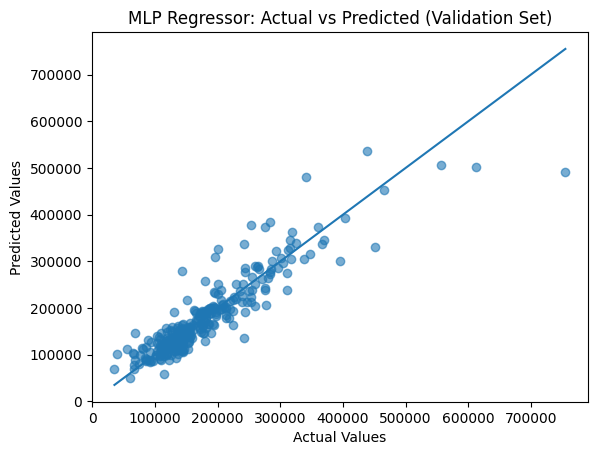

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Predictions already computed
# y_pred_val = mlp_model_opt.predict(X_raw_val)

plt.figure()
plt.scatter(y_raw_val, y_pred_val, alpha=0.6)
plt.plot(
    [y_raw_val.min(), y_raw_val.max()],
    [y_raw_val.min(), y_raw_val.max()]
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("MLP Regressor: Actual vs Predicted (Validation Set)")
plt.show()


In [ ]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# MLP Pipeline (same parameters as before)
mlp_model_opt = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        alpha=0.012,
        learning_rate_init=0.001,
        max_iter=4000,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=25,
        random_state=42
    ))
])

# 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    mlp_model_opt,
    X_train,
    y_train,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

print("CV R² scores:", cv_scores)
print("Mean CV R²:", np.mean(cv_scores))
print("Std CV R²:", np.std(cv_scores))

# Fit model
mlp_model_opt.fit(X_train, y_train)

# Predict on validation set
y_pred_mlp = mlp_model_opt.predict(X_val)

# Evaluation
print("Validation R²:", r2_score(y_val, y_pred_mlp))
print("MAE:", mean_absolute_error(y_val, y_pred_mlp))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_mlp)))

# Cross-validated MSE
cv_mse = -cross_val_score(
    mlp_model_opt,
    X_train,
    y_train,
    cv=kf,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

print("Cross-Validated MSE:", cv_mse.mean())


CV R² scores: [ -3.3783625   -4.09746815 -69.28227319  -7.09456098  -7.92019806]
Mean CV R²: -18.354572577524248
Std CV R²: 25.521938082043107
Validation R²: -2.530963818305774
MAE: 0.5933825647596331
RMSE: 0.811742311906963
Cross-Validated MSE: 3.13022944276021


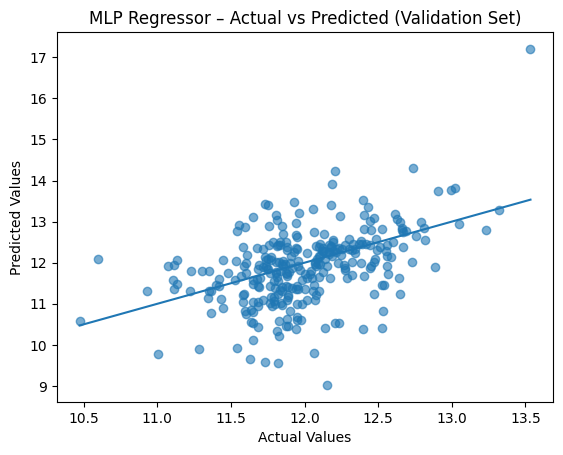

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---------- 1. Actual vs Predicted ----------
plt.figure()
plt.scatter(y_val, y_pred_mlp, alpha=0.6)
plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()]
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("MLP Regressor – Actual vs Predicted (Validation Set)")
plt.show()

